In [121]:
from pathlib import Path
import os
import re
import sys

# Project paths (works from notebooks/ or project root)
_PROJECT_ROOT = Path("..").resolve()
if not (_PROJECT_ROOT / "data" / "LIDC-IDRI").exists():
    _PROJECT_ROOT = Path(".").resolve()

# Allow `from xai import ...` (package lives under src/)
_SRC = _PROJECT_ROOT / "src"
if str(_SRC) not in sys.path:
    sys.path.insert(0, str(_SRC))

BASE_PATH = _PROJECT_ROOT / "data" / "LIDC-IDRI"
METADATA_PATH = BASE_PATH / "metadata.csv"
XML_ROOT = BASE_PATH  # LidcReadMessage XMLs live inside patient folders
DATA_ROOT = BASE_PATH.parent  # parent of LIDC-IDRI (resolves metadata File Location)

# Top-level project folders
OUTPUT_ROOT = _PROJECT_ROOT / "outputs"
MODELS_ROOT = _PROJECT_ROOT / "models"
GRADCAM_ROOT = _PROJECT_ROOT / "gradcam"

# outputs/ — data products & reports
PREPROCESS_DIR = OUTPUT_ROOT / "preprocessing"
CROP_DIR = OUTPUT_ROOT / "crops"
SPLITS_DIR = OUTPUT_ROOT / "splits"
FINAL_EVAL_DIR = OUTPUT_ROOT / "evaluation"
PAPER_DIR = OUTPUT_ROOT / "paper"

# models/ — trained weights + per-model experiment artifacts
SEMANTIC_DIR = MODELS_ROOT / "semantic_mlp"
IMAGE_DIR = MODELS_ROOT / "image_cnn"
FUSION_DIR = MODELS_ROOT / "fusion_cnn_mlp"
GRADCAM_DIR = GRADCAM_ROOT / "fusion"

# Derived file paths (preprocessing)
RAW_XML_CSV = PREPROCESS_DIR / "lidc_semantic_annotations_raw.csv"
BINARY_XML_CSV = PREPROCESS_DIR / "lidc_binary_semantic_annotations.csv"
DICOM_INDEX_CSV = PREPROCESS_DIR / "lidc_dicom_index.csv"
NODULE_WITH_SOP_CSV = PREPROCESS_DIR / "lidc_nodule_level_binary_with_sop.csv"
FULL_RECORD_CSV = PREPROCESS_DIR / "lidc_crop_extraction_full_record.csv"
CROPS_ONLY_CSV = PREPROCESS_DIR / "lidc_model_table_fixed_crops.csv"
DATA_CSV = CROPS_ONLY_CSV

# Split tables
TRAIN_DF_CSV = SPLITS_DIR / "train_df.csv"
VAL_DF_CSV = SPLITS_DIR / "val_df.csv"
TEST_DF_CSV = SPLITS_DIR / "test_df.csv"

# Create folder tree
for _d in [
    PREPROCESS_DIR,
    CROP_DIR,
    SPLITS_DIR,
    FINAL_EVAL_DIR,
    PAPER_DIR,
    SEMANTIC_DIR,
    IMAGE_DIR,
    FUSION_DIR,
    GRADCAM_DIR,
]:
    _d.mkdir(parents=True, exist_ok=True)


def load_lidc_metadata(path=METADATA_PATH):
    """Load TCIA metadata.csv (extra numeric field before File Size)."""
    import pandas as pd

    cols = [
        "Series UID",
        "Collection",
        "3rd Party Analysis",
        "Data Description URI",
        "Subject ID",
        "Study UID",
        "Study Description",
        "Study Date",
        "Series Description",
        "Manufacturer",
        "Modality",
        "SOP Class Name",
        "SOP Class UID",
        "Number of Images",
        "_size_num",
        "File Size",
        "File Location",
        "Download Timestamp",
    ]
    return pd.read_csv(path, header=0, names=cols)


def patient_id_from_path(path):
    """Extract LIDC-IDRI-XXXX from a local file path."""
    parts = Path(path).parts
    for part in parts:
        if re.fullmatch(r"LIDC-IDRI-\d+", part):
            return part
    return None


def resolve_file_location(file_location):
    """
    Resolve TCIA File Location values like:
    .\\LIDC-IDRI\\LIDC-IDRI-0001\\...\\series-folder
    """
    rel = str(file_location).lstrip(".\\/").replace("\\", os.sep).replace("/", os.sep)
    return DATA_ROOT / rel


print("PROJECT_ROOT:", _PROJECT_ROOT)
print("BASE_PATH:", BASE_PATH)
print("OUTPUT_ROOT:", OUTPUT_ROOT)
print("MODELS_ROOT:", MODELS_ROOT)
print("  preprocessing ->", PREPROCESS_DIR)
print("  crops         ->", CROP_DIR)
print("  splits        ->", SPLITS_DIR)
print("  evaluation    ->", FINAL_EVAL_DIR)
print("  paper         ->", PAPER_DIR)
print("  semantic_mlp  ->", SEMANTIC_DIR)
print("  image_cnn     ->", IMAGE_DIR)
print("  fusion        ->", FUSION_DIR)
print("  gradcam       ->", GRADCAM_DIR)


PROJECT_ROOT: C:\Users\Administrator\Documents\Biopark\Projeto-Integrador-3\PI3-Grupo-03
BASE_PATH: C:\Users\Administrator\Documents\Biopark\Projeto-Integrador-3\PI3-Grupo-03\data\LIDC-IDRI
OUTPUT_ROOT: C:\Users\Administrator\Documents\Biopark\Projeto-Integrador-3\PI3-Grupo-03\outputs
MODELS_ROOT: C:\Users\Administrator\Documents\Biopark\Projeto-Integrador-3\PI3-Grupo-03\models
  preprocessing -> C:\Users\Administrator\Documents\Biopark\Projeto-Integrador-3\PI3-Grupo-03\outputs\preprocessing
  crops         -> C:\Users\Administrator\Documents\Biopark\Projeto-Integrador-3\PI3-Grupo-03\outputs\crops
  splits        -> C:\Users\Administrator\Documents\Biopark\Projeto-Integrador-3\PI3-Grupo-03\outputs\splits
  evaluation    -> C:\Users\Administrator\Documents\Biopark\Projeto-Integrador-3\PI3-Grupo-03\outputs\evaluation
  paper         -> C:\Users\Administrator\Documents\Biopark\Projeto-Integrador-3\PI3-Grupo-03\outputs\paper
  semantic_mlp  -> C:\Users\Administrator\Documents\Biopark\Proje

**1.** **Shows file types: .dcm, .xml, .csv.**

In [122]:
import os
from collections import Counter, defaultdict

base_path = str(BASE_PATH)

ext_counter = Counter()
samples = defaultdict(list)

for root, dirs, files in os.walk(base_path):
    for f in files:
        ext = os.path.splitext(f)[1].lower()
        if ext == "":
            ext = "[no extension]"

        ext_counter[ext] += 1

        if len(samples[ext]) < 3:
            samples[ext].append(os.path.join(root, f))

print("Unique file types and counts:")
print("=" * 40)

for ext, count in ext_counter.most_common():
    print(f"{ext}: {count}")

print("\nSample files per type:")
print("=" * 40)

for ext, paths in samples.items():
    print(f"\n{ext}")
    for p in paths:
        print("  ", p)


Unique file types and counts:
.dcm: 7544
.xml: 1417
[no extension]: 58
.zip: 2
.csv: 1
.part: 1

Sample files per type:

[no extension]
   C:\Users\Administrator\Documents\Biopark\Projeto-Integrador-3\PI3-Grupo-03\data\LIDC-IDRI\LICENSE
   C:\Users\Administrator\Documents\Biopark\Projeto-Integrador-3\PI3-Grupo-03\data\LIDC-IDRI\LIDC-IDRI-0001\1.3.6.1.4.1.14519.5.2.1.6279.6001.179049373636438705059720603192\LICENSE
   C:\Users\Administrator\Documents\Biopark\Projeto-Integrador-3\PI3-Grupo-03\data\LIDC-IDRI\LIDC-IDRI-0002\1.3.6.1.4.1.14519.5.2.1.6279.6001.619372068417051974713149104919\LICENSE

.csv
   C:\Users\Administrator\Documents\Biopark\Projeto-Integrador-3\PI3-Grupo-03\data\LIDC-IDRI\metadata.csv

.xml
   C:\Users\Administrator\Documents\Biopark\Projeto-Integrador-3\PI3-Grupo-03\data\LIDC-IDRI\LIDC-IDRI-0001\01-01-2000-NA-NA-30178\3000566.000000-NA-03192\069.xml
   C:\Users\Administrator\Documents\Biopark\Projeto-Integrador-3\PI3-Grupo-03\data\LIDC-IDRI\LIDC-IDRI-0001\01-01-2000-N

**2. Inspect metadata CSV compactly**

In [123]:
import pandas as pd

metadata_path = METADATA_PATH

meta = load_lidc_metadata(metadata_path)

print("Metadata shape:", meta.shape)
print("\nColumns:")
for col in meta.columns:
    print("-", col)

print("\nFirst 3 rows:")
display(meta.head(3))


Metadata shape: (1018, 18)

Columns:
- Series UID
- Collection
- 3rd Party Analysis
- Data Description URI
- Subject ID
- Study UID
- Study Description
- Study Date
- Series Description
- Manufacturer
- Modality
- SOP Class Name
- SOP Class UID
- Number of Images
- _size_num
- File Size
- File Location
- Download Timestamp

First 3 rows:


,Series UID,Collection,3rd Party Analysis,Data Description URI,Subject ID,Study UID,Study Description,Study Date,Series Description,Manufacturer,Modality,SOP Class Name,SOP Class UID,Number of Images,_size_num,File Size,File Location,Download Timestamp
0,1.2.276.0.7230010.3.1.3.0.89315.1553284069.532969,LIDC-IDRI,yes,https://doi.org/10.7937/TCIA.2018.h7umfurq,LIDC-IDRI-0001,1.3.6.1.4.1.14519.5.2.1.6279.6001.298806137288...,NaN,01-01-2000,Nodule 1 - Annotation Nodule 001 evaluations,QIICR,SR,Enhanced SR Storage,1.2.840.10008.5.1.4.1.1.88.22,1,94,68 KB,.\LIDC-IDRI\LIDC-IDRI-0001\01-01-2000-NA-NA-30...,2026-08-10T23:02:37.026
1,1.2.276.0.7230010.3.1.3.0.89314.1553284067.990548,LIDC-IDRI,yes,https://doi.org/10.7937/TCIA.2018.h7umfurq,LIDC-IDRI-0001,1.3.6.1.4.1.14519.5.2.1.6279.6001.298806137288...,NaN,01-01-2000,Segmentation of Nodule 1 - Annotation Nodule 001,QIICR,SEG,Segmentation Storage,1.2.840.10008.5.1.4.1.1.66.4,1,270,28 KB,.\LIDC-IDRI\LIDC-IDRI-0001\01-01-2000-NA-NA-30...,2026-08-10T23:02:38.301
2,1.2.276.0.7230010.3.1.3.0.89316.1553284071.471973,LIDC-IDRI,yes,https://doi.org/10.7937/TCIA.2018.h7umfurq,LIDC-IDRI-0001,1.3.6.1.4.1.14519.5.2.1.6279.6001.298806137288...,NaN,01-01-2000,Segmentation of Nodule 1 - Annotation IL057127364,QIICR,SEG,Segmentation Storage,1.2.840.10008.5.1.4.1.1.66.4,1,236,83 KB,.\LIDC-IDRI\LIDC-IDRI-0001\01-01-2000-NA-NA-30...,2026-08-10T23:02:41.023


**3. Inspect one XML file structure**

In [124]:
import xml.etree.ElementTree as ET
from collections import Counter

sample_xml = str(next(BASE_PATH.rglob('*.xml')))

def clean_tag(tag):
    return tag.split("}")[-1] if "}" in tag else tag

tree = ET.parse(sample_xml)
root = tree.getroot()

tag_counter = Counter()

for elem in root.iter():
    tag_counter[clean_tag(elem.tag)] += 1

print("Unique XML tags:")
for tag, count in tag_counter.most_common():
    print(f"{tag}: {count}")


Unique XML tags:
xCoord: 170
yCoord: 170
edgeMap: 153
imageZposition: 40
imageSOP_UID: 40
roi: 23
inclusion: 23
unblindedReadNodule: 21
noduleID: 21
nonNodule: 17
nonNoduleID: 17
locus: 17
readingSession: 4
annotationVersion: 4
servicingRadiologistID: 4
characteristics: 2
subtlety: 2
internalStructure: 2
calcification: 2
sphericity: 2
margin: 2
lobulation: 2
spiculation: 2
texture: 2
malignancy: 2
LidcReadMessage: 1
ResponseHeader: 1
Version: 1
MessageId: 1
DateRequest: 1
TimeRequest: 1
RequestingSite: 1
ServicingSite: 1
TaskDescription: 1
CtImageFile: 1
SeriesInstanceUid: 1
StudyInstanceUID: 1
DateService: 1
TimeService: 1
ResponseDescription: 1
ResponseComments: 1


**4. Parse semantic attributes from all XML files**

In [125]:
import os
import numpy as np
import pandas as pd
import xml.etree.ElementTree as ET
from pathlib import Path
from tqdm import tqdm

xml_root = str(XML_ROOT)
semantic_fields = [
    "subtlety",
    "internalStructure",
    "calcification",
    "sphericity",
    "margin",
    "lobulation",
    "spiculation",
    "texture",
    "malignancy"
]

def clean_tag(tag):
    return tag.split("}")[-1] if "}" in tag else tag

def get_child_text(parent, target_tag):
    if parent is None:
        return None
    for child in parent:
        if clean_tag(child.tag) == target_tag:
            return child.text
    return None

def parse_lidc_xml(xml_path):
    rows = []

    try:
        tree = ET.parse(xml_path)
        root = tree.getroot()
    except Exception:
        return rows

    study_uid = None
    series_uid = None

    for elem in root.iter():
        tag = clean_tag(elem.tag)
        if tag.lower() == "studyinstanceuid":
            study_uid = elem.text
        elif tag.lower() == "seriesinstanceuid":
            series_uid = elem.text

    patient_id = patient_id_from_path(xml_path)
    reader_id = 0

    for session in root.iter():
        if clean_tag(session.tag) != "readingSession":
            continue

        reader_id += 1

        for nodule in session:
            if clean_tag(nodule.tag) != "unblindedReadNodule":
                continue

            nodule_id = get_child_text(nodule, "noduleID")

            row = {
                "xml_file": os.path.basename(xml_path),
                "xml_path": xml_path,
                "patient_id": patient_id,
                "study_uid": study_uid,
                "series_uid": series_uid,
                "reader_id": reader_id,
                "nodule_id": nodule_id
            }

            char_node = None
            for child in nodule:
                if clean_tag(child.tag) == "characteristics":
                    char_node = child
                    break

            for field in semantic_fields:
                value = get_child_text(char_node, field) if char_node is not None else None
                row[field] = int(value) if value is not None else np.nan

            xs, ys, zs, sop_uids = [], [], [], []

            for roi in nodule:
                if clean_tag(roi.tag) != "roi":
                    continue

                z_pos = get_child_text(roi, "imageZposition")
                sop_uid = get_child_text(roi, "imageSOP_UID")

                for edge in roi:
                    if clean_tag(edge.tag) != "edgeMap":
                        continue

                    x = get_child_text(edge, "xCoord")
                    y = get_child_text(edge, "yCoord")

                    if x is not None and y is not None:
                        xs.append(float(x))
                        ys.append(float(y))

                        if z_pos is not None:
                            zs.append(float(z_pos))

                        if sop_uid is not None:
                            sop_uids.append(sop_uid)

            row["centroid_x"] = np.mean(xs) if xs else np.nan
            row["centroid_y"] = np.mean(ys) if ys else np.nan
            row["z_position"] = np.mean(zs) if zs else np.nan
            row["num_contour_points"] = len(xs)
            row["sop_uids"] = "|".join(sorted(set(sop_uids))) if sop_uids else None

            rows.append(row)

    return rows

xml_files = sorted(str(p) for p in Path(xml_root).rglob("*.xml"))
print("Total XML files:", len(xml_files))

all_rows = []
for xml_path in tqdm(xml_files):
    all_rows.extend(parse_lidc_xml(xml_path))

df_xml = pd.DataFrame(all_rows)

print("Parsed annotation rows:", df_xml.shape)
print("Patients:", df_xml["patient_id"].nunique(dropna=True))
print("Series:", df_xml["series_uid"].nunique(dropna=True))
display(df_xml.head())


Total XML files: 1417


100%|██████████| 1417/1417 [00:26<00:00, 54.11it/s]


Parsed annotation rows: (21712, 21)
Patients: 50
Series: 998


,xml_file,xml_path,patient_id,study_uid,series_uid,reader_id,nodule_id,subtlety,internalStructure,calcification,...,margin,lobulation,spiculation,texture,malignancy,centroid_x,centroid_y,z_position,num_contour_points,sop_uids
0,069.xml,C:\Users\Administrator\Documents\Biopark\Proje...,LIDC-IDRI-0001,1.3.6.1.4.1.14519.5.2.1.6279.6001.298806137288...,1.3.6.1.4.1.14519.5.2.1.6279.6001.179049373636...,1,Nodule 001,5.0,1.0,6.0,...,3.0,3.0,4.0,5.0,5.0,315.048523,365.874473,-116.120781,948,1.3.6.1.4.1.14519.5.2.1.6279.6001.110383487652...
1,069.xml,C:\Users\Administrator\Documents\Biopark\Proje...,LIDC-IDRI-0001,1.3.6.1.4.1.14519.5.2.1.6279.6001.298806137288...,1.3.6.1.4.1.14519.5.2.1.6279.6001.179049373636...,1,Nodule 002,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,187.000000,166.000000,-150.000000,1,1.3.6.1.4.1.14519.5.2.1.6279.6001.313544823773...
2,069.xml,C:\Users\Administrator\Documents\Biopark\Proje...,LIDC-IDRI-0001,1.3.6.1.4.1.14519.5.2.1.6279.6001.298806137288...,1.3.6.1.4.1.14519.5.2.1.6279.6001.179049373636...,1,Nodule 003,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,403.000000,272.000000,-175.000000,1,1.3.6.1.4.1.14519.5.2.1.6279.6001.315606855383...
3,069.xml,C:\Users\Administrator\Documents\Biopark\Proje...,LIDC-IDRI-0001,1.3.6.1.4.1.14519.5.2.1.6279.6001.298806137288...,1.3.6.1.4.1.14519.5.2.1.6279.6001.179049373636...,1,Nodule 004,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,392.000000,317.000000,-175.000000,1,1.3.6.1.4.1.14519.5.2.1.6279.6001.315606855383...
4,069.xml,C:\Users\Administrator\Documents\Biopark\Proje...,LIDC-IDRI-0001,1.3.6.1.4.1.14519.5.2.1.6279.6001.298806137288...,1.3.6.1.4.1.14519.5.2.1.6279.6001.179049373636...,2,IL057_127364,5.0,1.0,6.0,...,4.0,5.0,5.0,5.0,5.0,316.277254,367.850606,-115.679677,743,1.3.6.1.4.1.14519.5.2.1.6279.6001.202709423777...


**5. Show compact semantic summary**

In [126]:
print("Semantic attribute value ranges:\n")

for col in semantic_fields:
    values = sorted(df_xml[col].dropna().unique())
    print(f"{col}: {values}")

print("\nMissing values:")
print(df_xml[semantic_fields].isna().sum())

print("\nMalignancy distribution:")
print(df_xml["malignancy"].value_counts(dropna=False).sort_index())

Semantic attribute value ranges:

subtlety: [np.float64(0.0), np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0)]
internalStructure: [np.float64(0.0), np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0)]
calcification: [np.float64(0.0), np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0), np.float64(6.0)]
sphericity: [np.float64(0.0), np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0)]
margin: [np.float64(0.0), np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0)]
lobulation: [np.float64(0.0), np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0)]
spiculation: [np.float64(0.0), np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0)]
texture: [np.float64(0.0), np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(5.0)]
malignancy: [np.float64(0.0

**6. Create binary labels**

In [127]:
df_binary = df_xml.dropna(subset=["malignancy"]).copy()

df_binary["label"] = np.where(
    df_binary["malignancy"] <= 2, 0,
    np.where(df_binary["malignancy"] >= 4, 1, np.nan)
)

df_binary = df_binary.dropna(subset=["label"]).copy()
df_binary["label"] = df_binary["label"].astype(int)

print("Binary label distribution:")
print(df_binary["label"].value_counts())

display(df_binary.head())

Binary label distribution:
label
0    2858
1    1793
Name: count, dtype: int64


,xml_file,xml_path,patient_id,study_uid,series_uid,reader_id,nodule_id,subtlety,internalStructure,calcification,...,lobulation,spiculation,texture,malignancy,centroid_x,centroid_y,z_position,num_contour_points,sop_uids,label
0,069.xml,C:\Users\Administrator\Documents\Biopark\Proje...,LIDC-IDRI-0001,1.3.6.1.4.1.14519.5.2.1.6279.6001.298806137288...,1.3.6.1.4.1.14519.5.2.1.6279.6001.179049373636...,1,Nodule 001,5.0,1.0,6.0,...,3.0,4.0,5.0,5.0,315.048523,365.874473,-116.120781,948,1.3.6.1.4.1.14519.5.2.1.6279.6001.110383487652...,1
4,069.xml,C:\Users\Administrator\Documents\Biopark\Proje...,LIDC-IDRI-0001,1.3.6.1.4.1.14519.5.2.1.6279.6001.298806137288...,1.3.6.1.4.1.14519.5.2.1.6279.6001.179049373636...,2,IL057_127364,5.0,1.0,6.0,...,5.0,5.0,5.0,5.0,316.277254,367.850606,-115.679677,743,1.3.6.1.4.1.14519.5.2.1.6279.6001.202709423777...,1
8,069.xml,C:\Users\Administrator\Documents\Biopark\Proje...,LIDC-IDRI-0001,1.3.6.1.4.1.14519.5.2.1.6279.6001.298806137288...,1.3.6.1.4.1.14519.5.2.1.6279.6001.179049373636...,3,MI014_12127,5.0,1.0,6.0,...,3.0,3.0,5.0,5.0,316.133418,366.955527,-116.153113,787,1.3.6.1.4.1.14519.5.2.1.6279.6001.110383487652...,1
9,069.xml,C:\Users\Administrator\Documents\Biopark\Proje...,LIDC-IDRI-0001,1.3.6.1.4.1.14519.5.2.1.6279.6001.298806137288...,1.3.6.1.4.1.14519.5.2.1.6279.6001.179049373636...,4,0,5.0,1.0,6.0,...,1.0,5.0,4.0,4.0,316.467900,366.502720,-115.495103,919,1.3.6.1.4.1.14519.5.2.1.6279.6001.110383487652...,1
30,071.xml,C:\Users\Administrator\Documents\Biopark\Proje...,LIDC-IDRI-0002,1.3.6.1.4.1.14519.5.2.1.6279.6001.490157381160...,1.3.6.1.4.1.14519.5.2.1.6279.6001.619372068417...,3,MI014_11691,2.0,1.0,6.0,...,1.0,1.0,1.0,5.0,345.634122,363.265779,-103.946499,2028,1.3.6.1.4.1.14519.5.2.1.6279.6001.110206842273...,1


**7. Save extracted semantic table**

In [128]:
raw_output = RAW_XML_CSV
binary_output = BINARY_XML_CSV

df_xml.to_csv(raw_output, index=False)
df_binary.to_csv(binary_output, index=False)

print("Saved raw semantic annotations to:", raw_output)
print("Saved binary semantic annotations to:", binary_output)


Saved raw semantic annotations to: C:\Users\Administrator\Documents\Biopark\Projeto-Integrador-3\PI3-Grupo-03\outputs\preprocessing\lidc_semantic_annotations_raw.csv
Saved binary semantic annotations to: C:\Users\Administrator\Documents\Biopark\Projeto-Integrador-3\PI3-Grupo-03\outputs\preprocessing\lidc_binary_semantic_annotations.csv


**8. Reload and clean valid semantic annotations**

In [129]:
import numpy as np
import pandas as pd

meta = load_lidc_metadata(METADATA_PATH)
df_xml = pd.read_csv(RAW_XML_CSV)

semantic_fields = [
    "subtlety",
    "internalStructure",
    "calcification",
    "sphericity",
    "margin",
    "lobulation",
    "spiculation",
    "texture",
    "malignancy"
]

df_valid = df_xml.dropna(subset=semantic_fields).copy()

# Remove invalid zero values
df_valid = df_valid[(df_valid[semantic_fields] > 0).all(axis=1)].copy()

# Ensure patient_id exists even if reloading an older CSV
if "patient_id" not in df_valid.columns or df_valid["patient_id"].isna().all():
    df_valid["patient_id"] = df_valid["xml_path"].map(patient_id_from_path)

print("Valid semantic rows:", df_valid.shape)
print(df_valid["malignancy"].value_counts().sort_index())
display(df_valid.head())


Valid semantic rows: (7491, 21)
malignancy
1.0    1071
2.0    1785
3.0    2842
4.0    1033
5.0     760
Name: count, dtype: int64


,xml_file,xml_path,patient_id,study_uid,series_uid,reader_id,nodule_id,subtlety,internalStructure,calcification,...,margin,lobulation,spiculation,texture,malignancy,centroid_x,centroid_y,z_position,num_contour_points,sop_uids
0,069.xml,C:\Users\Administrator\Documents\Biopark\Proje...,LIDC-IDRI-0001,1.3.6.1.4.1.14519.5.2.1.6279.6001.298806137288...,1.3.6.1.4.1.14519.5.2.1.6279.6001.179049373636...,1,Nodule 001,5.0,1.0,6.0,...,3.0,3.0,4.0,5.0,5.0,315.048523,365.874473,-116.120781,948,1.3.6.1.4.1.14519.5.2.1.6279.6001.110383487652...
4,069.xml,C:\Users\Administrator\Documents\Biopark\Proje...,LIDC-IDRI-0001,1.3.6.1.4.1.14519.5.2.1.6279.6001.298806137288...,1.3.6.1.4.1.14519.5.2.1.6279.6001.179049373636...,2,IL057_127364,5.0,1.0,6.0,...,4.0,5.0,5.0,5.0,5.0,316.277254,367.850606,-115.679677,743,1.3.6.1.4.1.14519.5.2.1.6279.6001.202709423777...
8,069.xml,C:\Users\Administrator\Documents\Biopark\Proje...,LIDC-IDRI-0001,1.3.6.1.4.1.14519.5.2.1.6279.6001.298806137288...,1.3.6.1.4.1.14519.5.2.1.6279.6001.179049373636...,3,MI014_12127,5.0,1.0,6.0,...,2.0,3.0,3.0,5.0,5.0,316.133418,366.955527,-116.153113,787,1.3.6.1.4.1.14519.5.2.1.6279.6001.110383487652...
9,069.xml,C:\Users\Administrator\Documents\Biopark\Proje...,LIDC-IDRI-0001,1.3.6.1.4.1.14519.5.2.1.6279.6001.298806137288...,1.3.6.1.4.1.14519.5.2.1.6279.6001.179049373636...,4,0,5.0,1.0,6.0,...,4.0,1.0,5.0,4.0,4.0,316.467900,366.502720,-115.495103,919,1.3.6.1.4.1.14519.5.2.1.6279.6001.110383487652...
30,071.xml,C:\Users\Administrator\Documents\Biopark\Proje...,LIDC-IDRI-0002,1.3.6.1.4.1.14519.5.2.1.6279.6001.490157381160...,1.3.6.1.4.1.14519.5.2.1.6279.6001.619372068417...,3,MI014_11691,2.0,1.0,6.0,...,1.0,1.0,1.0,1.0,5.0,345.634122,363.265779,-103.946499,2028,1.3.6.1.4.1.14519.5.2.1.6279.6001.110206842273...


**9. Merge patient ID from metadata**

In [130]:
import numpy as np

# Prefer patient_id already parsed from XML path.
# Also attach Subject ID from metadata when Series UID matches (optional enrichment).
meta_ct = meta.loc[meta["Modality"] == "CT", ["Subject ID", "Study UID", "Series UID"]].drop_duplicates()

df_valid = df_valid.merge(
    meta_ct,
    left_on="series_uid",
    right_on="Series UID",
    how="left",
    suffixes=("", "_meta"),
)

# Keep path-based patient_id; fill gaps from metadata Subject ID
if "patient_id" not in df_valid.columns:
    df_valid["patient_id"] = np.nan

df_valid["patient_id"] = df_valid["patient_id"].fillna(df_valid["Subject ID"])

# Restrict to CT series present in local metadata (drops DX/CR annotation XMLs)
before = len(df_valid)
df_valid = df_valid[df_valid["Series UID"].notna()].copy()
after = len(df_valid)

print(f"Rows before CT filter: {before}")
print(f"Rows after CT filter:  {after}")
print("Missing patient_id:", df_valid["patient_id"].isna().sum())
print("CT patients:", df_valid["patient_id"].nunique())
display(df_valid[["patient_id", "series_uid", "nodule_id", "malignancy"]].head())


Rows before CT filter: 7491
Rows after CT filter:  918
Missing patient_id: 0
CT patients: 48


,patient_id,series_uid,nodule_id,malignancy
0,LIDC-IDRI-0001,1.3.6.1.4.1.14519.5.2.1.6279.6001.179049373636...,Nodule 001,5.0
1,LIDC-IDRI-0001,1.3.6.1.4.1.14519.5.2.1.6279.6001.179049373636...,IL057_127364,5.0
2,LIDC-IDRI-0001,1.3.6.1.4.1.14519.5.2.1.6279.6001.179049373636...,MI014_12127,5.0
3,LIDC-IDRI-0001,1.3.6.1.4.1.14519.5.2.1.6279.6001.179049373636...,0,4.0
4,LIDC-IDRI-0002,1.3.6.1.4.1.14519.5.2.1.6279.6001.619372068417...,MI014_11691,5.0


**10. Build DICOM index**

In [131]:
import importlib.util
import subprocess
import sys

if importlib.util.find_spec("pydicom") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "pydicom"])
print("pydicom ready")


pydicom ready


In [132]:
import numpy as np
import pandas as pd
import pydicom
from pathlib import Path
from tqdm import tqdm

meta_all = load_lidc_metadata(METADATA_PATH)
ct_meta = meta_all.loc[meta_all["Modality"] == "CT"].copy()
print("CT series in metadata:", len(ct_meta))

ct_dirs = []
for loc in ct_meta["File Location"].dropna():
    series_dir = resolve_file_location(loc)
    if series_dir.is_dir():
        ct_dirs.append(series_dir)
    else:
        print("Missing CT folder:", series_dir)

dcm_files = []
for series_dir in ct_dirs:
    dcm_files.extend(str(p) for p in series_dir.glob("*.dcm"))

# Fallback: scan BASE_PATH for CT if metadata paths failed
if len(dcm_files) == 0:
    print("Metadata CT folders empty; scanning BASE_PATH for CT DICOMs...")
    for path in Path(BASE_PATH).rglob("*.dcm"):
        try:
            ds = pydicom.dcmread(str(path), stop_before_pixels=True, force=True)
            if str(getattr(ds, "Modality", "")) == "CT":
                dcm_files.append(str(path))
        except Exception:
            continue

print("Total CT DICOM files:", len(dcm_files))

dcm_rows = []
for path in tqdm(dcm_files):
    try:
        ds = pydicom.dcmread(path, stop_before_pixels=True, force=True)

        if str(getattr(ds, "Modality", "")) != "CT":
            continue

        image_position = getattr(ds, "ImagePositionPatient", None)
        z_pos = float(image_position[2]) if image_position is not None else np.nan

        pixel_spacing = getattr(ds, "PixelSpacing", [np.nan, np.nan])
        row_spacing = float(pixel_spacing[0]) if pixel_spacing is not None else np.nan
        col_spacing = float(pixel_spacing[1]) if pixel_spacing is not None else np.nan

        patient_id = str(getattr(ds, "PatientID", "")) or patient_id_from_path(path)

        dcm_rows.append({
            "dicom_path": path,
            "patient_id_dicom": patient_id,
            "study_uid_dicom": str(getattr(ds, "StudyInstanceUID", "")),
            "series_uid": str(getattr(ds, "SeriesInstanceUID", "")),
            "sop_uid": str(getattr(ds, "SOPInstanceUID", "")),
            "instance_number": getattr(ds, "InstanceNumber", np.nan),
            "z_position_dicom": z_pos,
            "row_spacing": row_spacing,
            "col_spacing": col_spacing,
            "slice_thickness": getattr(ds, "SliceThickness", np.nan),
            "modality": str(getattr(ds, "Modality", "")),
        })
    except Exception:
        continue

df_dcm = pd.DataFrame(dcm_rows)

print("DICOM index (CT only):", df_dcm.shape)
print("CT series:", df_dcm["series_uid"].nunique())
print("CT patients:", df_dcm["patient_id_dicom"].nunique())
display(df_dcm.head())

df_dcm.to_csv(str(DICOM_INDEX_CSV), index=False)
print("Saved:", DICOM_INDEX_CSV)


CT series in metadata: 50
Total CT DICOM files: 2510


100%|██████████| 2510/2510 [00:03<00:00, 711.83it/s]


DICOM index (CT only): (2510, 11)
CT series: 15
CT patients: 15


,dicom_path,patient_id_dicom,study_uid_dicom,series_uid,sop_uid,instance_number,z_position_dicom,row_spacing,col_spacing,slice_thickness,modality
0,C:\Users\Administrator\Documents\Biopark\Proje...,LIDC-IDRI-0005,1.3.6.1.4.1.14519.5.2.1.6279.6001.190188259083...,1.3.6.1.4.1.14519.5.2.1.6279.6001.129007566048...,1.3.6.1.4.1.14519.5.2.1.6279.6001.384493276263...,1,-10.045,0.664062,0.664062,2.5,CT
1,C:\Users\Administrator\Documents\Biopark\Proje...,LIDC-IDRI-0005,1.3.6.1.4.1.14519.5.2.1.6279.6001.190188259083...,1.3.6.1.4.1.14519.5.2.1.6279.6001.129007566048...,1.3.6.1.4.1.14519.5.2.1.6279.6001.958276044559...,2,-12.545,0.664062,0.664062,2.5,CT
2,C:\Users\Administrator\Documents\Biopark\Proje...,LIDC-IDRI-0005,1.3.6.1.4.1.14519.5.2.1.6279.6001.190188259083...,1.3.6.1.4.1.14519.5.2.1.6279.6001.129007566048...,1.3.6.1.4.1.14519.5.2.1.6279.6001.147157875397...,3,-15.045,0.664062,0.664062,2.5,CT
3,C:\Users\Administrator\Documents\Biopark\Proje...,LIDC-IDRI-0005,1.3.6.1.4.1.14519.5.2.1.6279.6001.190188259083...,1.3.6.1.4.1.14519.5.2.1.6279.6001.129007566048...,1.3.6.1.4.1.14519.5.2.1.6279.6001.505061562872...,4,-17.545,0.664062,0.664062,2.5,CT
4,C:\Users\Administrator\Documents\Biopark\Proje...,LIDC-IDRI-0005,1.3.6.1.4.1.14519.5.2.1.6279.6001.190188259083...,1.3.6.1.4.1.14519.5.2.1.6279.6001.129007566048...,1.3.6.1.4.1.14519.5.2.1.6279.6001.845116822247...,5,-20.045,0.664062,0.664062,2.5,CT


Saved: C:\Users\Administrator\Documents\Biopark\Projeto-Integrador-3\PI3-Grupo-03\outputs\preprocessing\lidc_dicom_index.csv


**11. Add physical coordinates for clustering**

In [133]:
series_info = (
    df_dcm
    .dropna(subset=["series_uid"])
    .groupby("series_uid")
    .agg({
        "row_spacing": "median",
        "col_spacing": "median",
        "slice_thickness": "median",
        "patient_id_dicom": "first"
    })
    .reset_index()
)

df_valid = df_valid.merge(series_info, on="series_uid", how="left")

df_valid["patient_id"] = df_valid["patient_id"].fillna(df_valid["patient_id_dicom"])

# Keep only rows that matched a local CT series (have spacing)
before = len(df_valid)
df_valid = df_valid.dropna(subset=["row_spacing", "col_spacing"]).copy()
print(f"Dropped rows without CT spacing: {before - len(df_valid)}")

df_valid["centroid_x_mm"] = df_valid["centroid_x"] * df_valid["col_spacing"]
df_valid["centroid_y_mm"] = df_valid["centroid_y"] * df_valid["row_spacing"]
df_valid["centroid_z_mm"] = df_valid["z_position"]

print("Remaining CT-linked annotation rows:", len(df_valid))
print("Missing spacing:")
print(df_valid[["row_spacing", "col_spacing"]].isna().sum())

display(df_valid[[
    "patient_id", "centroid_x", "centroid_y", "z_position",
    "centroid_x_mm", "centroid_y_mm", "centroid_z_mm"
]].head())


Dropped rows without CT spacing: 682
Remaining CT-linked annotation rows: 236
Missing spacing:
row_spacing    0
col_spacing    0
dtype: int64


,patient_id,centroid_x,centroid_y,z_position,centroid_x_mm,centroid_y_mm,centroid_z_mm
23,LIDC-IDRI-0005,126.693878,397.224490,-146.269488,84.132590,263.781689,-146.269488
24,LIDC-IDRI-0005,311.962025,406.987342,-139.823479,207.162126,270.264828,-139.823479
25,LIDC-IDRI-0005,407.044444,376.600000,-121.267220,270.302748,250.085749,-121.267220
26,LIDC-IDRI-0005,126.767442,397.767442,-146.324068,84.181441,264.142243,-146.324068
27,LIDC-IDRI-0005,312.592593,407.333333,-140.044998,207.580862,270.494588,-140.044998


**12. Cluster reader annotations into nodule-level samples**

In [134]:
from sklearn.cluster import DBSCAN

cluster_input = df_valid.dropna(
    subset=["series_uid", "centroid_x_mm", "centroid_y_mm", "centroid_z_mm"]
).copy()

clustered_parts = []

for series_uid, group in tqdm(cluster_input.groupby("series_uid")):
    group = group.copy()

    coords = group[["centroid_x_mm", "centroid_y_mm", "centroid_z_mm"]].values

    # 10 mm is a practical starting point.
    labels = DBSCAN(eps=10, min_samples=1).fit_predict(coords)

    group["spatial_cluster"] = labels
    clustered_parts.append(group)

df_clustered = pd.concat(clustered_parts, ignore_index=True)

print("Reader-level clustered rows:", df_clustered.shape)
print("Estimated physical nodules:", df_clustered.groupby(["series_uid", "spatial_cluster"]).ngroups)
display(df_clustered.head())

100%|██████████| 13/13 [00:00<00:00, 201.35it/s]


Reader-level clustered rows: (236, 32)
Estimated physical nodules: 41


,xml_file,xml_path,patient_id,study_uid,series_uid,reader_id,nodule_id,subtlety,internalStructure,calcification,...,Study UID,Series UID,row_spacing,col_spacing,slice_thickness,patient_id_dicom,centroid_x_mm,centroid_y_mm,centroid_z_mm,spatial_cluster
0,100.xml,C:\Users\Administrator\Documents\Biopark\Proje...,LIDC-IDRI-0017,1.3.6.1.4.1.14519.5.2.1.6279.6001.853991115059...,1.3.6.1.4.1.14519.5.2.1.6279.6001.108231420525...,1,Nodule 001,3.0,1.0,6.0,...,1.3.6.1.4.1.14519.5.2.1.6279.6001.853991115059...,1.3.6.1.4.1.14519.5.2.1.6279.6001.108231420525...,0.728516,0.728516,1.25,LIDC-IDRI-0017,228.129582,245.605960,-84.673077,0
1,100.xml,C:\Users\Administrator\Documents\Biopark\Proje...,LIDC-IDRI-0017,1.3.6.1.4.1.14519.5.2.1.6279.6001.853991115059...,1.3.6.1.4.1.14519.5.2.1.6279.6001.108231420525...,2,IL057_130635,3.0,1.0,6.0,...,1.3.6.1.4.1.14519.5.2.1.6279.6001.853991115059...,1.3.6.1.4.1.14519.5.2.1.6279.6001.108231420525...,0.728516,0.728516,1.25,LIDC-IDRI-0017,228.438584,245.907947,-85.095361,0
2,100.xml,C:\Users\Administrator\Documents\Biopark\Proje...,LIDC-IDRI-0017,1.3.6.1.4.1.14519.5.2.1.6279.6001.853991115059...,1.3.6.1.4.1.14519.5.2.1.6279.6001.108231420525...,3,MI014_18053,5.0,1.0,6.0,...,1.3.6.1.4.1.14519.5.2.1.6279.6001.853991115059...,1.3.6.1.4.1.14519.5.2.1.6279.6001.108231420525...,0.728516,0.728516,1.25,LIDC-IDRI-0017,228.297158,245.485197,-85.059322,0
3,100.xml,C:\Users\Administrator\Documents\Biopark\Proje...,LIDC-IDRI-0017,1.3.6.1.4.1.14519.5.2.1.6279.6001.853991115059...,1.3.6.1.4.1.14519.5.2.1.6279.6001.108231420525...,4,0,3.0,1.0,6.0,...,1.3.6.1.4.1.14519.5.2.1.6279.6001.853991115059...,1.3.6.1.4.1.14519.5.2.1.6279.6001.108231420525...,0.728516,0.728516,1.25,LIDC-IDRI-0017,228.020190,245.509892,-85.076642,0
4,100.xml,C:\Users\Administrator\Documents\Biopark\Proje...,LIDC-IDRI-0017,1.3.6.1.4.1.14519.5.2.1.6279.6001.853991115059...,1.3.6.1.4.1.14519.5.2.1.6279.6001.108231420525...,1,Nodule 001,3.0,1.0,6.0,...,1.3.6.1.4.1.14519.5.2.1.6279.6001.853991115059...,1.3.6.1.4.1.14519.5.2.1.6279.6001.108231420525...,0.728516,0.728516,1.25,LIDC-IDRI-0017,228.129582,245.605960,-84.673077,0


**13. Create nodule-level binary table with SOP UIDs**

In [135]:
import os
import re
import cv2
import numpy as np
import pandas as pd
import pydicom
import matplotlib.pyplot as plt
from tqdm import tqdm
from collections import defaultdict

# -----------------------------
# Paths
# -----------------------------

os.makedirs(CROP_DIR, exist_ok=True)

semantic_fields = [
    "subtlety",
    "internalStructure",
    "calcification",
    "sphericity",
    "margin",
    "lobulation",
    "spiculation",
    "texture",
    "malignancy"
]

# -----------------------------
# Check required dataframe
# -----------------------------
if "df_clustered" not in globals():
    raise RuntimeError(
        "df_clustered is not available. Please rerun your previous clustering cell first."
    )

def collect_sop_uids(values):
    sop_list = []
    for v in values.dropna():
        for s in str(v).split("|"):
            s = s.strip()
            if s and s.lower() not in ["nan", "none"]:
                sop_list.append(s)
    return "|".join(sorted(set(sop_list)))

group_cols = ["series_uid", "spatial_cluster"]

agg_base = {
    "patient_id": "first",
    "study_uid": "first",
    "centroid_x": "mean",      # pixel coordinate, use for cropping
    "centroid_y": "mean",      # pixel coordinate, use for cropping
    "z_position": "mean",
    "centroid_x_mm": "mean",
    "centroid_y_mm": "mean",
    "centroid_z_mm": "mean",
    "reader_id": "nunique",
    "num_contour_points": "sum",
    "row_spacing": "median",
    "col_spacing": "median",
    "slice_thickness": "median",
    "sop_uids": collect_sop_uids
}

df_nodule_v2 = df_clustered.groupby(group_cols).agg(agg_base).reset_index()
df_nodule_v2 = df_nodule_v2.rename(columns={"reader_id": "num_readers"})

for col in semantic_fields:
    stat_df = (
        df_clustered
        .groupby(group_cols)[col]
        .agg(["mean", "std", "count"])
        .reset_index()
        .rename(columns={
            "mean": f"{col}_mean",
            "std": f"{col}_std",
            "count": f"{col}_count"
        })
    )
    df_nodule_v2 = df_nodule_v2.merge(stat_df, on=group_cols, how="left")

# Binary labels from averaged malignancy
df_nodule_v2["label"] = np.where(
    df_nodule_v2["malignancy_mean"] <= 2, 0,
    np.where(df_nodule_v2["malignancy_mean"] >= 4, 1, np.nan)
)

df_nodule_binary_v2 = df_nodule_v2.dropna(subset=["label"]).copy()
df_nodule_binary_v2["label"] = df_nodule_binary_v2["label"].astype(int)

df_nodule_binary_v2.to_csv(NODULE_WITH_SOP_CSV, index=False)

print("Saved nodule-level binary table with SOP UIDs:")
print(NODULE_WITH_SOP_CSV)
print("\nShape:", df_nodule_binary_v2.shape)
print("\nLabel distribution:")
print(df_nodule_binary_v2["label"].value_counts())
print("\nSOP UID availability:")
print(df_nodule_binary_v2["sop_uids"].notna().value_counts())


Saved nodule-level binary table with SOP UIDs:
C:\Users\Administrator\Documents\Biopark\Projeto-Integrador-3\PI3-Grupo-03\outputs\preprocessing\lidc_nodule_level_binary_with_sop.csv

Shape: (7, 44)

Label distribution:
label
1    5
0    2
Name: count, dtype: int64

SOP UID availability:
sop_uids
True    7
Name: count, dtype: int64


**14. Load DICOM index and build lookup dictionaries**

In [136]:
# Load DICOM index if not already in memory
if "df_dcm" not in globals():
    if os.path.exists(DICOM_INDEX_CSV):
        df_dcm = pd.read_csv(DICOM_INDEX_CSV)
        print("Loaded existing DICOM index:", df_dcm.shape)
    else:
        raise RuntimeError(
            "DICOM index not found. Please rebuild df_dcm first and save it as lidc_dicom_index.csv."
        )

# Ensure required columns are string/numeric
df_dcm["sop_uid"] = df_dcm["sop_uid"].astype(str).str.strip()
df_dcm["series_uid"] = df_dcm["series_uid"].astype(str).str.strip()
df_dcm["z_position_dicom"] = pd.to_numeric(df_dcm["z_position_dicom"], errors="coerce")

# SOP lookup: exact DICOM slice matching
df_dcm_sop = df_dcm.dropna(subset=["sop_uid"]).copy()
sop_to_row = df_dcm_sop.set_index("sop_uid").to_dict("index")

# Series lookup: fallback nearest-z matching
series_to_rows = defaultdict(list)
for _, row in df_dcm.dropna(subset=["series_uid"]).iterrows():
    series_to_rows[row["series_uid"]].append(row.to_dict())

# Sort each series by z position
for sid in series_to_rows:
    series_to_rows[sid] = sorted(
        [r for r in series_to_rows[sid] if pd.notna(r.get("z_position_dicom"))],
        key=lambda r: float(r["z_position_dicom"])
    )

print("DICOM lookup ready.")
print("SOP UID entries:", len(sop_to_row))
print("Series entries:", len(series_to_rows))

DICOM lookup ready.
SOP UID entries: 2510
Series entries: 15


**15. Helper functions for SOP parsing, HU conversion, windowing, and crop extraction.**

In [137]:
HU_MIN, HU_MAX = -1000, 400
RAW_CROP_SIZE = 96
FINAL_SIZE = 64

def parse_sop_uids(raw_sop):
    """
    Handles SOP strings separated by | or comma.
    """
    if pd.isna(raw_sop):
        return []
    
    raw_sop = str(raw_sop)
    raw_sop = raw_sop.replace("[", "").replace("]", "")
    raw_sop = raw_sop.replace("'", "").replace('"', "")
    
    sop_list = re.split(r"[|,]", raw_sop)
    return [
        s.strip()
        for s in sop_list
        if s.strip() and s.strip().lower() not in ["nan", "none"]
    ]

def load_hu_image(dicom_path):
    """
    Read DICOM image and convert raw pixel values to Hounsfield Units.
    """
    ds = pydicom.dcmread(dicom_path, force=True)
    img = ds.pixel_array.astype(np.float32)
    
    slope = float(getattr(ds, "RescaleSlope", 1))
    intercept = float(getattr(ds, "RescaleIntercept", 0))
    photometric = str(getattr(ds, "PhotometricInterpretation", "MONOCHROME2"))
    
    hu_img = img * slope + intercept
    return hu_img, photometric

def window_hu(img, hu_min=HU_MIN, hu_max=HU_MAX):
    """
    Apply lung window and normalise to [0, 1].
    """
    img = np.clip(img, hu_min, hu_max)
    img = (img - hu_min) / (hu_max - hu_min)
    return img.astype(np.float32)

def extract_crop(img, cx, cy, raw_size=RAW_CROP_SIZE, final_size=FINAL_SIZE):
    """
    Extract padded crop centred on pixel coordinates (cx, cy).
    """
    h, w = img.shape
    cx = int(round(float(cx)))
    cy = int(round(float(cy)))
    
    if cx < 0 or cx >= w or cy < 0 or cy >= h:
        return None, False
    
    half = raw_size // 2
    
    x1, x2 = cx - half, cx + half
    y1, y2 = cy - half, cy + half
    
    pad_left = max(0, -x1)
    pad_right = max(0, x2 - w)
    pad_top = max(0, -y1)
    pad_bottom = max(0, y2 - h)
    
    img_pad = np.pad(
        img,
        ((pad_top, pad_bottom), (pad_left, pad_right)),
        mode="constant",
        constant_values=0
    )
    
    x1 += pad_left
    x2 += pad_left
    y1 += pad_top
    y2 += pad_top
    
    crop = img_pad[y1:y2, x1:x2]
    crop = cv2.resize(crop, (final_size, final_size), interpolation=cv2.INTER_AREA)
    
    return crop, True

def choose_best_slice(row):
    """
    Priority:
    1. SOP UID exact match
    2. Nearest z-position within the same series
    """
    target_z = row.get("z_position", np.nan)
    series_uid = str(row.get("series_uid", "")).strip()
    
    # 1. SOP matching
    sop_list = parse_sop_uids(row.get("sop_uids", ""))
    valid_sops = [s for s in sop_list if s in sop_to_row]
    
    if len(valid_sops) > 0:
        # Choose SOP whose z-position is closest to averaged nodule z-position
        def sop_z_diff(s):
            z = sop_to_row[s].get("z_position_dicom", np.nan)
            if pd.isna(z) or pd.isna(target_z):
                return np.inf
            return abs(float(z) - float(target_z))
        
        best_sop = min(valid_sops, key=sop_z_diff)
        meta = sop_to_row[best_sop]
        matched_z = meta.get("z_position_dicom", np.nan)
        z_diff = abs(float(matched_z) - float(target_z)) if pd.notna(matched_z) and pd.notna(target_z) else np.nan
        
        return {
            "chosen_dicom_path": meta["dicom_path"],
            "chosen_sop_uid": best_sop,
            "chosen_z": matched_z,
            "chosen_z_diff": z_diff,
            "match_method": "sop"
        }
    
    # 2. Nearest z fallback
    if series_uid in series_to_rows and pd.notna(target_z):
        slices = series_to_rows[series_uid]
        if len(slices) > 0:
            best = min(
                slices,
                key=lambda r: abs(float(r["z_position_dicom"]) - float(target_z))
            )
            matched_z = best.get("z_position_dicom", np.nan)
            z_diff = abs(float(matched_z) - float(target_z))
            
            return {
                "chosen_dicom_path": best["dicom_path"],
                "chosen_sop_uid": best.get("sop_uid", None),
                "chosen_z": matched_z,
                "chosen_z_diff": z_diff,
                "match_method": "nearest_z"
            }
    
    return {
        "chosen_dicom_path": None,
        "chosen_sop_uid": None,
        "chosen_z": np.nan,
        "chosen_z_diff": np.nan,
        "match_method": "none"
    }

**16. Diagnose SOP matching coverage before crop extraction**

In [138]:
nodule_df = pd.read_csv(NODULE_WITH_SOP_CSV)

print("Loaded nodule table:", nodule_df.shape)
print("\nLabel distribution:")
print(nodule_df["label"].value_counts())

diagnosis_rows = []

for _, row in nodule_df.iterrows():
    info = choose_best_slice(row)
    diagnosis_rows.append(info)

diagnosis_df = pd.DataFrame(diagnosis_rows)

print("\nMatch method counts:")
print(diagnosis_df["match_method"].value_counts())

print("\nChosen z-diff summary:")
print(diagnosis_df["chosen_z_diff"].describe())

print("\nRows with no DICOM match:")
print((diagnosis_df["match_method"] == "none").sum())

Loaded nodule table: (7, 44)

Label distribution:
label
1    5
0    2
Name: count, dtype: int64

Match method counts:
match_method
sop    7
Name: count, dtype: int64

Chosen z-diff summary:
count    7.000000
mean     0.507776
std      0.487035
min      0.001704
25%      0.097958
50%      0.490729
75%      0.821931
max      1.222222
Name: chosen_z_diff, dtype: float64

Rows with no DICOM match:
0


**17. Extract improved SOP-based crops**

In [139]:
results = []

for idx, row in tqdm(nodule_df.iterrows(), total=len(nodule_df)):
    row_dict = row.to_dict()
    match_info = choose_best_slice(row)
    
    out = {
        **row_dict,
        **match_info,
        "crop_path": None,
        "crop_ok": False,
        "crop_error": None
    }
    
    if match_info["chosen_dicom_path"] is None:
        out["crop_error"] = "no_dicom_match"
        results.append(out)
        continue
    
    try:
        hu_img, photometric = load_hu_image(match_info["chosen_dicom_path"])
        img = window_hu(hu_img)
        
        # Display inversion only after HU conversion and windowing
        if "MONOCHROME1" in photometric.upper():
            img = 1.0 - img
        
        crop, valid = extract_crop(
            img,
            cx=row["centroid_x"],   # pixel coordinate
            cy=row["centroid_y"],   # pixel coordinate
            raw_size=RAW_CROP_SIZE,
            final_size=FINAL_SIZE
        )
        
        if not valid:
            out["crop_error"] = "centroid_off_image"
            results.append(out)
            continue
        
        label = int(row["label"])
        mal = float(row["malignancy_mean"])
        
        crop_filename = f"nodule_{idx:05d}_label_{label}_mal_{mal:.2f}.npy"
        crop_path = os.path.join(CROP_DIR, crop_filename)
        
        np.save(crop_path, crop)
        
        out["crop_path"] = crop_path
        out["crop_ok"] = True
        
    except Exception as e:
        out["crop_error"] = str(e)
    
    results.append(out)

result_df = pd.DataFrame(results)

print("Total nodules:", len(result_df))
print("Crops extracted:", result_df["crop_ok"].sum())
print("Failed crops:", (~result_df["crop_ok"]).sum())

print("\nSuccessful label distribution:")
print(result_df[result_df["crop_ok"]]["label"].value_counts())

print("\nFailure breakdown:")
print(result_df.loc[~result_df["crop_ok"], "crop_error"].value_counts().head(20))

print("\nMatch method breakdown for successful crops:")
print(result_df[result_df["crop_ok"]]["match_method"].value_counts())

print("\nZ-diff summary for successful crops:")
print(result_df[result_df["crop_ok"]]["chosen_z_diff"].describe())

100%|██████████| 7/7 [00:00<00:00, 136.87it/s]

Total nodules: 7
Crops extracted: 7
Failed crops: 0

Successful label distribution:
label
1    5
0    2
Name: count, dtype: int64

Failure breakdown:
Series([], Name: count, dtype: int64)

Match method breakdown for successful crops:
match_method
sop    7
Name: count, dtype: int64

Z-diff summary for successful crops:
count    7.000000
mean     0.507776
std      0.487035
min      0.001704
25%      0.097958
50%      0.490729
75%      0.821931
max      1.222222
Name: chosen_z_diff, dtype: float64


**18. Flag suspicious crops by z-difference**

In [140]:
Z_WARN = 5.0
Z_DROP = 15.0

ok_df = result_df[result_df["crop_ok"]].copy()
ok_df["chosen_z_diff"] = pd.to_numeric(ok_df["chosen_z_diff"], errors="coerce")

ok_df["z_flag"] = "ok"
ok_df.loc[ok_df["chosen_z_diff"] > Z_WARN, "z_flag"] = "warn"
ok_df.loc[ok_df["chosen_z_diff"] > Z_DROP, "z_flag"] = "drop"

print("Z-flag distribution:")
print(ok_df["z_flag"].value_counts())

clean_df = ok_df[ok_df["z_flag"] != "drop"].copy()

print("\nClean crops kept:", clean_df.shape)
print("\nClean label distribution:")
print(clean_df["label"].value_counts())
print("\nMatch methods:")
print(clean_df["match_method"].value_counts())

Z-flag distribution:
z_flag
ok    7
Name: count, dtype: int64

Clean crops kept: (7, 53)

Clean label distribution:
label
1    5
0    2
Name: count, dtype: int64

Match methods:
match_method
sop    7
Name: count, dtype: int64


**19. Visual QC grid**

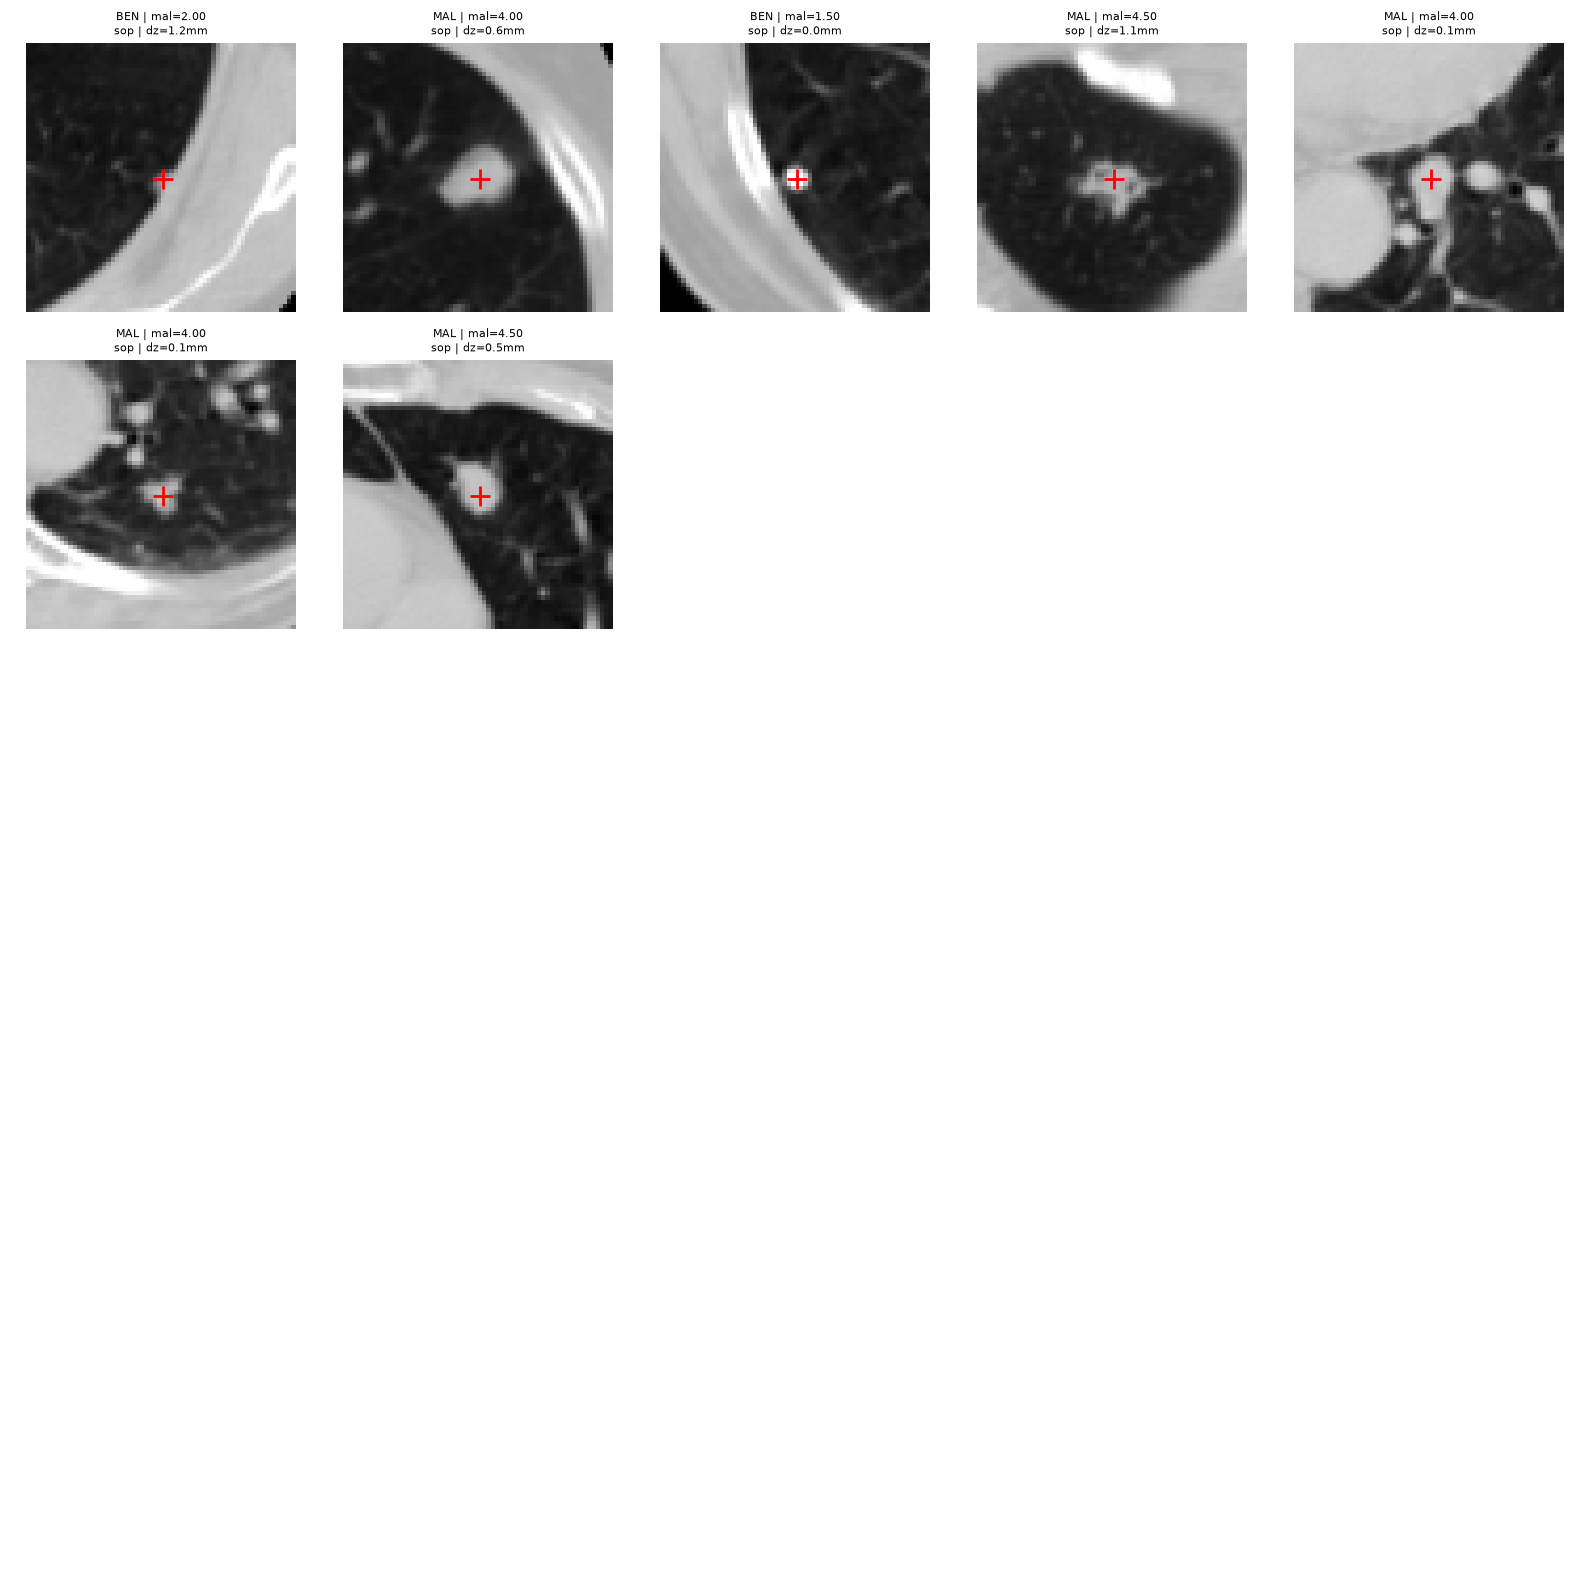

In [141]:
sample_df = clean_df.sample(min(25, len(clean_df)), random_state=42).reset_index(drop=True)

fig, axes = plt.subplots(5, 5, figsize=(16, 16))
axes = axes.flatten()

for i, ax in enumerate(axes):
    if i >= len(sample_df):
        ax.axis("off")
        continue
    
    row = sample_df.iloc[i]
    crop = np.load(row["crop_path"])
    
    ax.imshow(crop, cmap="gray", vmin=0, vmax=1)
    ax.axis("off")
    
    # Red centre marker
    ax.plot(32, 32, "r+", markersize=14, markeredgewidth=2)
    
    label = int(row["label"])
    border_color = "lime" if label == 0 else "red"
    
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color(border_color)
        spine.set_linewidth(3)
    
    z_diff = row["chosen_z_diff"]
    z_text = "NA" if pd.isna(z_diff) else f"{z_diff:.1f}mm"
    
    ax.set_title(
        f"{'BEN' if label == 0 else 'MAL'} | mal={row['malignancy_mean']:.2f}\n"
        f"{row['match_method']} | dz={z_text}",
        fontsize=8
    )

plt.tight_layout()
plt.show()

**20. Save final tables**

In [142]:
# Guard: after scripts/expand_lidc_dataset.py, most DICOMs are deleted on purpose.
# Re-running this cell would only see the few kept patients and SHRINK the table.
FORCE_OVERWRITE_CROP_TABLES = False  # set True only for an intentional local rebuild

def _csv_nrows(path):
    p = Path(path)
    if not p.exists():
        return 0
    try:
        return len(pd.read_csv(p))
    except Exception:
        return 0

existing_n = _csv_nrows(CROPS_ONLY_CSV)
new_n = len(clean_df)

if existing_n > new_n and not FORCE_OVERWRITE_CROP_TABLES:
    print("REFUSED to overwrite crop tables (would shrink the dataset).")
    print(f"  on disk: {existing_n} rows  |  this notebook run: {new_n} rows")
    print(f"  kept existing: {CROPS_ONLY_CSV}")
    print("  Fix: re-run `python scripts/expand_lidc_dataset.py run ...`")
    print("  Or set FORCE_OVERWRITE_CROP_TABLES = True if you really mean it.")
    clean_df = pd.read_csv(CROPS_ONLY_CSV)
else:
    # Full record: includes successes and failures
    result_df.to_csv(FULL_RECORD_CSV, index=False)

    # Clean crop table: use this for image-only and multimodal model training
    clean_df.to_csv(CROPS_ONLY_CSV, index=False)

    print("Saved full crop extraction record:")
    print(FULL_RECORD_CSV)

    print("\nSaved clean crop-only modelling table:")
    print(CROPS_ONLY_CSV)

print("\nFinal clean table shape:", clean_df.shape)
print("\nFinal label distribution:")
print(clean_df["label"].value_counts())

print("\nPatients:", clean_df["patient_id"].nunique())
print("Series:", clean_df["series_uid"].nunique())

if "match_method" in clean_df.columns:
    print("\nMatch method counts:")
    print(clean_df["match_method"].value_counts())

REFUSED to overwrite crop tables (would shrink the dataset).
  on disk: 27 rows  |  this notebook run: 7 rows
  kept existing: C:\Users\Administrator\Documents\Biopark\Projeto-Integrador-3\PI3-Grupo-03\outputs\preprocessing\lidc_model_table_fixed_crops.csv
  Fix: re-run `python scripts/expand_lidc_dataset.py run ...`
  Or set FORCE_OVERWRITE_CROP_TABLES = True if you really mean it.

Final clean table shape: (27, 53)

Final label distribution:
label
0    16
1    11
Name: count, dtype: int64

Patients: 12
Series: 12

Match method counts:
match_method
sop    27
Name: count, dtype: int64


**After dataset expansion:** if you already ran `python scripts/expand_lidc_dataset.py run ...`, **skip** the DICOM / crop-extraction cells above. Most DICOMs are deleted on purpose; re-extracting here would shrink the table to the few XAI-kept patients.

Use the next cell to load `lidc_model_table_fixed_crops.csv` and continue from the train/val/test split.

**21. Load final clean dataset**

In [143]:
import pandas as pd

DATA_CSV = CROPS_ONLY_CSV
df = pd.read_csv(DATA_CSV)

# Sanity check: a healthy expanded table should have dozens of patients.
# If you see ~3 patients / <10 nodules, the CSV was likely overwritten by a
# local re-extract after DICOM cleanup — re-run expand_lidc_dataset.py.
n_patients = df["patient_id"].nunique()
if n_patients < 20:
    print("WARNING: crop table looks too small for training.")
    print(f"  patients={n_patients}  nodules={len(df)}")
    print("  Expected after expand: ~50+ patients / ~100+ nodules.")
    print("  Re-run: python scripts/expand_lidc_dataset.py run --batch-size 50 --max-gb 8")
    print("  Do NOT re-run the notebook crop-extraction / to_csv cells.")

print("Shape:", df.shape)
print("\nLabel distribution:")
print(df["label"].value_counts())

print("\nPatients:", n_patients)
print("Series:", df["series_uid"].nunique())

display(df.head())


  patients=12  nodules=27
  Expected after expand: ~50+ patients / ~100+ nodules.
  Re-run: python scripts/expand_lidc_dataset.py run --batch-size 50 --max-gb 8
  Do NOT re-run the notebook crop-extraction / to_csv cells.
Shape: (27, 53)

Label distribution:
label
0    16
1    11
Name: count, dtype: int64

Patients: 12
Series: 12


,series_uid,spatial_cluster,patient_id,study_uid,centroid_x,centroid_y,z_position,centroid_x_mm,centroid_y_mm,centroid_z_mm,...,label,chosen_dicom_path,chosen_sop_uid,chosen_z,chosen_z_diff,match_method,crop_path,crop_ok,crop_error,z_flag
0,1.3.6.1.4.1.14519.5.2.1.6279.6001.129007566048...,2,LIDC-IDRI-0005,1.3.6.1.4.1.14519.5.2.1.6279.6001.190188259083...,407.044444,376.600000,-121.267220,270.302748,250.085749,-121.267220,...,0,C:\Users\Administrator\Documents\Biopark\Proje...,1.3.6.1.4.1.14519.5.2.1.6279.6001.240311620606...,-120.044998,1.222222,sop,C:\Users\Administrator\Documents\Biopark\Proje...,True,NaN,ok
1,1.3.6.1.4.1.14519.5.2.1.6279.6001.153536305742...,0,LIDC-IDRI-0016,1.3.6.1.4.1.14519.5.2.1.6279.6001.378894347946...,438.081813,181.876146,-199.175935,256.688781,106.568145,-199.175935,...,1,C:\Users\Administrator\Documents\Biopark\Proje...,1.3.6.1.4.1.14519.5.2.1.6279.6001.268480733714...,-199.750000,0.574065,sop,C:\Users\Administrator\Documents\Biopark\Proje...,True,NaN,ok
2,1.3.6.1.4.1.14519.5.2.1.6279.6001.153536305742...,4,LIDC-IDRI-0016,1.3.6.1.4.1.14519.5.2.1.6279.6001.378894347946...,340.975621,276.040357,-63.319796,199.790573,161.742535,-63.319796,...,1,C:\Users\Administrator\Documents\Biopark\Proje...,1.3.6.1.4.1.14519.5.2.1.6279.6001.292718549762...,-62.250000,1.069796,sop,C:\Users\Administrator\Documents\Biopark\Proje...,True,NaN,ok
3,1.3.6.1.4.1.14519.5.2.1.6279.6001.910435939545...,1,LIDC-IDRI-0045,1.3.6.1.4.1.14519.5.2.1.6279.6001.127418142282...,336.892691,366.555117,-244.391430,223.717634,243.415324,-244.391430,...,1,C:\Users\Administrator\Documents\Biopark\Proje...,1.3.6.1.4.1.14519.5.2.1.6279.6001.167916885545...,-244.500000,0.108570,sop,C:\Users\Administrator\Documents\Biopark\Proje...,True,NaN,ok
4,1.3.6.1.4.1.14519.5.2.1.6279.6001.910435939545...,2,LIDC-IDRI-0045,1.3.6.1.4.1.14519.5.2.1.6279.6001.127418142282...,333.142496,326.029848,-234.412653,221.227272,216.504033,-234.412653,...,1,C:\Users\Administrator\Documents\Biopark\Proje...,1.3.6.1.4.1.14519.5.2.1.6279.6001.127040272931...,-234.500000,0.087347,sop,C:\Users\Administrator\Documents\Biopark\Proje...,True,NaN,ok


**22. Define semantic input columns**

In [144]:
semantic_cols = [
    "subtlety_mean",
    "internalStructure_mean",
    "calcification_mean",
    "sphericity_mean",
    "margin_mean",
    "lobulation_mean",
    "spiculation_mean",
    "texture_mean"
]

target_col = "label"
image_col = "crop_path"

print(df[semantic_cols].head())

   subtlety_mean  internalStructure_mean  calcification_mean  sphericity_mean  \
0            3.0                     1.0                 6.0         3.000000   
1            5.0                     1.0                 6.0         3.750000   
2            5.0                     1.0                 6.0         3.750000   
3            4.0                     1.0                 6.0         3.333333   
4            4.0                     1.0                 6.0         3.500000   

   margin_mean  lobulation_mean  spiculation_mean  texture_mean  
0     5.000000         1.000000          1.000000      5.000000  
1     4.000000         3.000000          1.500000      4.500000  
2     3.000000         2.500000          4.000000      4.250000  
3     3.666667         3.666667          3.333333      4.666667  
4     3.000000         1.500000          2.500000      5.000000  


**23. Patient-level train/validation/test split**

In [145]:
from sklearn.model_selection import GroupShuffleSplit

# First split: train+val vs test
gss1 = GroupShuffleSplit(n_splits=1, test_size=0.15, random_state=42)

train_val_idx, test_idx = next(
    gss1.split(df, df["label"], groups=df["patient_id"])
)

train_val_df = df.iloc[train_val_idx].reset_index(drop=True)
test_df = df.iloc[test_idx].reset_index(drop=True)

# Second split: train vs validation
gss2 = GroupShuffleSplit(n_splits=1, test_size=0.1765, random_state=42)
# 0.1765 of 85% ≈ 15% total

train_idx, val_idx = next(
    gss2.split(train_val_df, train_val_df["label"], groups=train_val_df["patient_id"])
)

train_df = train_val_df.iloc[train_idx].reset_index(drop=True)
val_df = train_val_df.iloc[val_idx].reset_index(drop=True)

print("Train:", train_df.shape)
print("Val:", val_df.shape)
print("Test:", test_df.shape)

print("\nTrain labels:")
print(train_df["label"].value_counts())

print("\nVal labels:")
print(val_df["label"].value_counts())

print("\nTest labels:")
print(test_df["label"].value_counts())

print("\nPatient overlap check:")
print("Train-Val overlap:", len(set(train_df.patient_id) & set(val_df.patient_id)))
print("Train-Test overlap:", len(set(train_df.patient_id) & set(test_df.patient_id)))
print("Val-Test overlap:", len(set(val_df.patient_id) & set(test_df.patient_id)))

Train: (21, 53)
Val: (3, 53)
Test: (3, 53)

Train labels:
label
0    14
1     7
Name: count, dtype: int64

Val labels:
label
0    2
1    1
Name: count, dtype: int64

Test labels:
label
1    3
Name: count, dtype: int64

Patient overlap check:
Train-Val overlap: 0
Train-Test overlap: 0
Val-Test overlap: 0


**Semantic-only MLP baseline using the current 628 clean nodules.**
# Code Architecture
Input:
8 semantic attributes
{subtlety, internalStructure, calcification, sphericity,
 margin, lobulation, spiculation, texture}

        ↓

StandardScaler
fit only on train set

        ↓

Semantic MLP
Linear(8 → 64)
BatchNorm1d
ReLU
Dropout(0.30)

        ↓

Linear(64 → 32)
BatchNorm1d
ReLU
Dropout(0.30)

        ↓

Linear(32 → 1)
Output: raw logit

        ↓

BCEWithLogitsLoss(pos_weight)
Adam optimiser
Best model saved by validation AUC

        ↓

Test evaluation:
Accuracy, AUC, Precision, Sensitivity, Specificity, F1, Confusion Matrix

In [146]:
# Cell 1 — Imports and setup

import os
import random
import joblib
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import matplotlib.pyplot as plt

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

#DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Force CPU for semantic-only MLP
DEVICE = torch.device("cpu")
print("Using device:", DEVICE)

OUTPUT_DIR = SEMANTIC_DIR
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("Device:", DEVICE)


Using device: cpu
Device: cpu


In [147]:
# Cell 2 — Define semantic input columns

semantic_cols = [
    "subtlety_mean",
    "internalStructure_mean",
    "calcification_mean",
    "sphericity_mean",
    "margin_mean",
    "lobulation_mean",
    "spiculation_mean",
    "texture_mean"
]

target_col = "label"

# Safety checks
for col in semantic_cols:
    assert col in train_df.columns, f"Missing column: {col}"

assert "malignancy_mean" not in semantic_cols
assert "malignancy_std" not in semantic_cols
assert "malignancy_count" not in semantic_cols
assert "label" not in semantic_cols

print("Semantic input columns:")
for col in semantic_cols:
    print("-", col)

print("\nTrain:", train_df.shape)
print("Val:", val_df.shape)
print("Test:", test_df.shape)

print("\nTrain labels:")
print(train_df[target_col].value_counts())

print("\nValidation labels:")
print(val_df[target_col].value_counts())

print("\nTest labels:")
print(test_df[target_col].value_counts())

Semantic input columns:
- subtlety_mean
- internalStructure_mean
- calcification_mean
- sphericity_mean
- margin_mean
- lobulation_mean
- spiculation_mean
- texture_mean

Train: (21, 53)
Val: (3, 53)
Test: (3, 53)

Train labels:
label
0    14
1     7
Name: count, dtype: int64

Validation labels:
label
0    2
1    1
Name: count, dtype: int64

Test labels:
label
1    3
Name: count, dtype: int64


In [148]:
# Cell 3 — Standardise semantic features
print("Missing values in train:")
print(train_df[semantic_cols].isna().sum())

print("\nMissing values in val:")
print(val_df[semantic_cols].isna().sum())

print("\nMissing values in test:")
print(test_df[semantic_cols].isna().sum())

# Fit scaler only on training data
scaler = StandardScaler()

X_train = scaler.fit_transform(train_df[semantic_cols].values)
X_val = scaler.transform(val_df[semantic_cols].values)
X_test = scaler.transform(test_df[semantic_cols].values)

y_train = train_df[target_col].values.astype(np.float32)
y_val = val_df[target_col].values.astype(np.float32)
y_test = test_df[target_col].values.astype(np.float32)

joblib.dump(scaler, os.path.join(OUTPUT_DIR, "semantic_scaler.pkl"))

print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("X_test:", X_test.shape)
print("Scaler saved.")

Missing values in train:
subtlety_mean             0
internalStructure_mean    0
calcification_mean        0
sphericity_mean           0
margin_mean               0
lobulation_mean           0
spiculation_mean          0
texture_mean              0
dtype: int64

Missing values in val:
subtlety_mean             0
internalStructure_mean    0
calcification_mean        0
sphericity_mean           0
margin_mean               0
lobulation_mean           0
spiculation_mean          0
texture_mean              0
dtype: int64

Missing values in test:
subtlety_mean             0
internalStructure_mean    0
calcification_mean        0
sphericity_mean           0
margin_mean               0
lobulation_mean           0
spiculation_mean          0
texture_mean              0
dtype: int64
X_train: (21, 8)
X_val: (3, 8)
X_test: (3, 8)
Scaler saved.


In [149]:
# Cell 4 — Dataset and DataLoader
class SemanticDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

BATCH_SIZE = 32

train_loader = DataLoader(
    SemanticDataset(X_train, y_train),
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0
)

val_loader = DataLoader(
    SemanticDataset(X_val, y_val),
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

test_loader = DataLoader(
    SemanticDataset(X_test, y_test),
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

print("Train batches:", len(train_loader))
print("Val batches:", len(val_loader))
print("Test batches:", len(test_loader))



Train batches: 1
Val batches: 1
Test batches: 1


In [150]:
# Cell 5 — Semantic-only MLP model

class SemanticMLP(nn.Module):
    def __init__(self, input_dim=8):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.30),

            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(0.30)
        )

        self.classifier = nn.Linear(32, 1)

    def forward(self, x):
        embedding = self.encoder(x)
        logit = self.classifier(embedding).squeeze(1)
        return logit

    def get_embedding(self, x):
        return self.encoder(x)

model = SemanticMLP(input_dim=len(semantic_cols)).to(DEVICE)

print(model)

num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("\nTrainable parameters:", num_params)


SemanticMLP(
  (encoder): Sequential(
    (0): Linear(in_features=8, out_features=64, bias=True)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
  )
  (classifier): Linear(in_features=32, out_features=1, bias=True)
)

Trainable parameters: 2881


In [151]:
# Cell 6 — Loss, optimiser, scheduler

num_neg = (y_train == 0).sum()
num_pos = (y_train == 1).sum()

pos_weight_value = num_neg / num_pos
pos_weight = torch.tensor([pos_weight_value], dtype=torch.float32).to(DEVICE)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=10
)

print("Negative samples:", num_neg)
print("Positive samples:", num_pos)
print("pos_weight:", pos_weight_value)

Negative samples: 14
Positive samples: 7
pos_weight: 2.0


In [152]:
# Cell 7 — Training and metric functions

def compute_metrics(y_true, y_prob, threshold=0.5):
    y_pred = (y_prob >= threshold).astype(int)

    acc = accuracy_score(y_true, y_pred)
    if len(np.unique(y_true)) > 1:
        auc = roc_auc_score(y_true, y_prob)
    else:
        auc = float("nan")
    precision = precision_score(y_true, y_pred, zero_division=0)
    sensitivity = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)

    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()

    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

    return {
        "accuracy": acc,
        "auc": auc,
        "precision": precision,
        "sensitivity": sensitivity,
        "specificity": specificity,
        "f1": f1,
        "tn": tn,
        "fp": fp,
        "fn": fn,
        "tp": tp
    }

def run_epoch(model, loader, criterion=None, optimizer=None):
    is_train = optimizer is not None

    if is_train:
        model.train()
    else:
        model.eval()

    total_loss = 0.0
    all_probs = []
    all_labels = []

    with torch.set_grad_enabled(is_train):
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(DEVICE)
            y_batch = y_batch.to(DEVICE)

            logits = model(X_batch)
            loss = criterion(logits, y_batch)

            if is_train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            probs = torch.sigmoid(logits)

            total_loss += loss.item() * X_batch.size(0)
            all_probs.extend(probs.detach().cpu().numpy())
            all_labels.extend(y_batch.detach().cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)
    return avg_loss, np.array(all_probs), np.array(all_labels)


In [153]:
# Cell 8 — Train semantic-only MLP

EPOCHS = 100
PATIENCE = 20

best_val_auc = -np.inf
epochs_without_improvement = 0

best_model_path = os.path.join(OUTPUT_DIR, "best_semantic_mlp.pth")

history = []

# Force single-process DataLoaders (Windows/Jupyter-safe)
from torch.utils.data import DataLoader as _DataLoader

train_loader = _DataLoader(
    train_loader.dataset,
    batch_size=train_loader.batch_size,
    shuffle=True,
    num_workers=0,
)
val_loader = _DataLoader(
    val_loader.dataset,
    batch_size=val_loader.batch_size,
    shuffle=False,
    num_workers=0,
)
if "test_loader" in globals():
    test_loader = _DataLoader(
        test_loader.dataset,
        batch_size=test_loader.batch_size,
        shuffle=False,
        num_workers=0,
    )

for epoch in range(1, EPOCHS + 1):
    
    train_loss, train_probs, train_labels = run_epoch(
        model,
        train_loader,
        criterion=criterion,
        optimizer=optimizer
    )

    val_loss, val_probs, val_labels = run_epoch(
        model,
        val_loader,
        criterion=criterion,
        optimizer=None
    )

    train_metrics = compute_metrics(train_labels, train_probs)
    val_metrics = compute_metrics(val_labels, val_probs)

    scheduler.step(val_metrics["auc"])

    history.append({
        "epoch": epoch,
        "train_loss": train_loss,
        "val_loss": val_loss,
        "train_auc": train_metrics["auc"],
        "val_auc": val_metrics["auc"],
        "train_accuracy": train_metrics["accuracy"],
        "val_accuracy": val_metrics["accuracy"],
        "train_f1": train_metrics["f1"],
        "val_f1": val_metrics["f1"]
    })

    improved = val_metrics["auc"] > best_val_auc

    if improved:
        best_val_auc = val_metrics["auc"]
        epochs_without_improvement = 0
        torch.save(model.state_dict(), best_model_path)
    else:
        epochs_without_improvement += 1

    if epoch == 1 or epoch % 10 == 0 or improved:
        print(
            f"Epoch {epoch:03d} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Train AUC: {train_metrics['auc']:.4f} | "
            f"Val AUC: {val_metrics['auc']:.4f} | "
            f"Val F1: {val_metrics['f1']:.4f}"
            + ("  [SAVED]" if improved else "")
        )

    if epochs_without_improvement >= PATIENCE:
        print(f"\nEarly stopping at epoch {epoch}.")
        break

history_df = pd.DataFrame(history)
history_path = os.path.join(OUTPUT_DIR, "semantic_mlp_history.csv")
history_df.to_csv(history_path, index=False)

print("\nBest validation AUC:", best_val_auc)
print("Best model saved to:", best_model_path)
print("History saved to:", history_path)


Epoch 001 | Train Loss: 0.9673 | Val Loss: 0.9864 | Train AUC: 0.5408 | Val AUC: 0.0000 | Val F1: 0.0000  [SAVED]
Epoch 010 | Train Loss: 0.5755 | Val Loss: 1.0489 | Train AUC: 0.9796 | Val AUC: 0.0000 | Val F1: 0.0000
Epoch 020 | Train Loss: 0.4913 | Val Loss: 1.1070 | Train AUC: 1.0000 | Val AUC: 0.0000 | Val F1: 0.0000

Early stopping at epoch 21.

Best validation AUC: 0.0
Best model saved to: C:\Users\Administrator\Documents\Biopark\Projeto-Integrador-3\PI3-Grupo-03\models\semantic_mlp\best_semantic_mlp.pth
History saved to: C:\Users\Administrator\Documents\Biopark\Projeto-Integrador-3\PI3-Grupo-03\models\semantic_mlp\semantic_mlp_history.csv


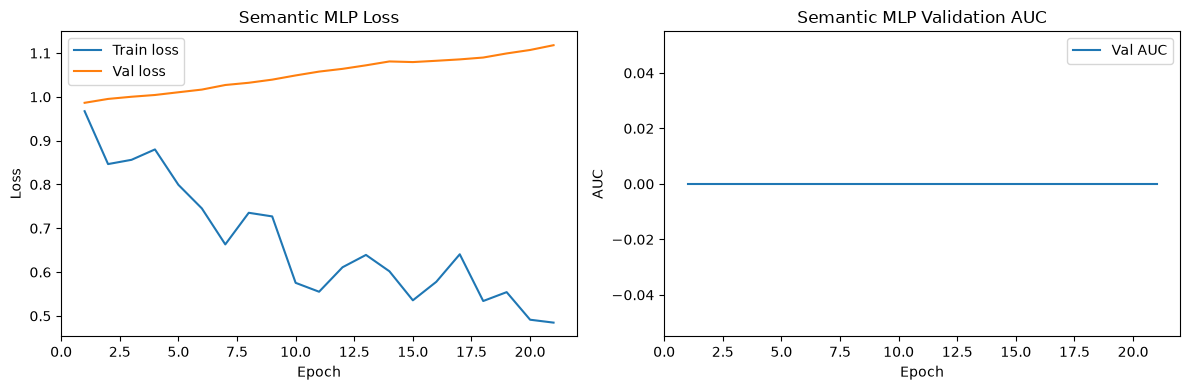

Saved: C:\Users\Administrator\Documents\Biopark\Projeto-Integrador-3\PI3-Grupo-03\models\semantic_mlp\semantic_mlp_training_curves.png


In [154]:
# Cell 9 — Plot training curves

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history_df["epoch"], history_df["train_loss"], label="Train loss")
plt.plot(history_df["epoch"], history_df["val_loss"], label="Val loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Semantic MLP Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_df["epoch"], history_df["val_auc"], label="Val AUC")
plt.xlabel("Epoch")
plt.ylabel("AUC")
plt.title("Semantic MLP Validation AUC")
plt.legend()

plt.tight_layout()

curve_path = os.path.join(OUTPUT_DIR, "semantic_mlp_training_curves.png")
plt.savefig(curve_path, dpi=150)
plt.show()

print("Saved:", curve_path)

In [155]:
# Cell 10 — Evaluate best model on test set

best_model = SemanticMLP(input_dim=len(semantic_cols)).to(DEVICE)
best_model.load_state_dict(torch.load(best_model_path, map_location=DEVICE))

test_loss, test_probs, test_labels = run_epoch(
    best_model,
    test_loader,
    criterion=criterion,
    optimizer=None
)

test_metrics = compute_metrics(test_labels, test_probs, threshold=0.5)

print("Semantic-only MLP Test Results")
print("=" * 50)

for key, value in test_metrics.items():
    print(f"{key}: {value}")

print("\nConfusion Matrix:")
cm = np.array([
    [test_metrics["tn"], test_metrics["fp"]],
    [test_metrics["fn"], test_metrics["tp"]]
])
print(cm)

print("\nClassification Report:")
print(
    classification_report(
        test_labels,
        (test_probs >= 0.5).astype(int),
        target_names=["Benign", "Malignant"],
        zero_division=0
    )
)

Semantic-only MLP Test Results
accuracy: 0.0
auc: nan
precision: 0.0
sensitivity: 0.0
specificity: 0
f1: 0.0
tn: 0
fp: 0
fn: 3
tp: 0

Confusion Matrix:
[[0 0]
 [3 0]]

Classification Report:
              precision    recall  f1-score   support

      Benign       0.00      0.00      0.00       0.0
   Malignant       0.00      0.00      0.00       3.0

    accuracy                           0.00       3.0
   macro avg       0.00      0.00      0.00       3.0
weighted avg       0.00      0.00      0.00       3.0



In [156]:
# Cell 11 — Save result summary

semantic_result = pd.DataFrame([{
    "model": "Semantic-only MLP",
    "accuracy": test_metrics["accuracy"],
    "auc": test_metrics["auc"],
    "precision": test_metrics["precision"],
    "sensitivity": test_metrics["sensitivity"],
    "specificity": test_metrics["specificity"],
    "f1": test_metrics["f1"],
    "tn": test_metrics["tn"],
    "fp": test_metrics["fp"],
    "fn": test_metrics["fn"],
    "tp": test_metrics["tp"]
}])

semantic_result_path = os.path.join(OUTPUT_DIR, "semantic_only_mlp_results.csv")
semantic_result.to_csv(semantic_result_path, index=False)

display(semantic_result)

print("Saved results to:", semantic_result_path)

,model,accuracy,auc,precision,sensitivity,specificity,f1,tn,fp,fn,tp
0,Semantic-only MLP,0.0,NaN,0.0,0.0,0,0.0,0,0,3,0


Saved results to: C:\Users\Administrator\Documents\Biopark\Projeto-Integrador-3\PI3-Grupo-03\models\semantic_mlp\semantic_only_mlp_results.csv


# **Image-only CNN baseline**

Input:
64×64 axial CT nodule crop

        ↓

Image-only CNN

Conv block 1:
Conv2d(1 → 32, kernel=3, padding=1)
BatchNorm2d
ReLU
MaxPool2d(2)
Output: 32 × 32 × 32

        ↓

Conv block 2:
Conv2d(32 → 64, kernel=3, padding=1)
BatchNorm2d
ReLU
MaxPool2d(2)
Output: 64 × 16 × 16

        ↓

Conv block 3:
Conv2d(64 → 128, kernel=3, padding=1)
BatchNorm2d
ReLU
MaxPool2d(2)
Output: 128 × 8 × 8

        ↓

AdaptiveAvgPool2d(1)
Flatten
Output: 128-dimensional image embedding

        ↓

Classifier:
Linear(128 → 64)
ReLU
Dropout(0.5)
Linear(64 → 1)

        ↓

Output:
Raw logit

In [157]:
# Cell 1 — Setup for Image-only CNN

import os
import random
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

import matplotlib.pyplot as plt

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

OUTPUT_DIR = IMAGE_DIR
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("Device:", DEVICE)


Device: cpu


In [158]:
# Cell 2 — Check image crop column

image_col = "crop_path"
target_col = "label"

assert image_col in train_df.columns, f"Missing image column: {image_col}"
assert target_col in train_df.columns, f"Missing target column: {target_col}"

print("Train:", train_df.shape)
print("Val:", val_df.shape)
print("Test:", test_df.shape)

print("\nTrain labels:")
print(train_df[target_col].value_counts())

print("\nValidation labels:")
print(val_df[target_col].value_counts())

print("\nTest labels:")
print(test_df[target_col].value_counts())

print("\nExample crop path:")
print(train_df[image_col].iloc[0])

Train: (21, 53)
Val: (3, 53)
Test: (3, 53)

Train labels:
label
0    14
1     7
Name: count, dtype: int64

Validation labels:
label
0    2
1    1
Name: count, dtype: int64

Test labels:
label
1    3
Name: count, dtype: int64

Example crop path:
C:\Users\Administrator\Documents\Biopark\Projeto-Integrador-3\PI3-Grupo-03\outputs\crops\nodule_00000_label_0_mal_2.00.npy


In [159]:
# Cell 3 — Compute train image mean and standard deviation

def load_crop(path):
    crop = np.load(path).astype(np.float32)
    
    # Safety: ensure shape is 64×64
    if crop.shape != (64, 64):
        raise ValueError(f"Unexpected crop shape {crop.shape} for {path}")
    
    return crop

train_pixels = []

for path in train_df[image_col].values:
    img = load_crop(path)
    train_pixels.append(img)

train_pixels = np.stack(train_pixels)

img_mean = train_pixels.mean()
img_std = train_pixels.std()

print("Train image mean:", img_mean)
print("Train image std:", img_std)

# Avoid division by zero
if img_std < 1e-6:
    img_std = 1.0

np.save(os.path.join(OUTPUT_DIR, "image_mean.npy"), img_mean)
np.save(os.path.join(OUTPUT_DIR, "image_std.npy"), img_std)


Train image mean: 0.37979558
Train image std: 0.31604508


In [160]:
# Cell 4 — Image Dataset and DataLoader

class ImageOnlyDataset(Dataset):
    def __init__(self, df, image_col, target_col, mean, std, augment=False):
        self.df = df.reset_index(drop=True)
        self.image_col = image_col
        self.target_col = target_col
        self.mean = mean
        self.std = std
        self.augment = augment

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        
        img = np.load(row[self.image_col]).astype(np.float32)
        
        # Simple augmentation
        if self.augment:
            if np.random.rand() < 0.5:
                img = np.fliplr(img).copy()
            if np.random.rand() < 0.5:
                img = np.flipud(img).copy()
        
        # Standardise using train mean/std
        img = (img - self.mean) / self.std
        
        # Add channel dimension: 1×64×64
        img = torch.tensor(img, dtype=torch.float32).unsqueeze(0)
        
        label = torch.tensor(row[self.target_col], dtype=torch.float32)
        
        return img, label

BATCH_SIZE = 32

train_loader = DataLoader(
    ImageOnlyDataset(train_df, image_col, target_col, img_mean, img_std, augment=True),
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0
)

val_loader = DataLoader(
    ImageOnlyDataset(val_df, image_col, target_col, img_mean, img_std, augment=False),
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

test_loader = DataLoader(
    ImageOnlyDataset(test_df, image_col, target_col, img_mean, img_std, augment=False),
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

print("Train batches:", len(train_loader))
print("Val batches:", len(val_loader))
print("Test batches:", len(test_loader))



Train batches: 1
Val batches: 1
Test batches: 1


In [161]:
# Cell 5 — Image-only CNN Model

class ImageCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),   # 32 × 32 × 32

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),   # 64 × 16 × 16

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),   # 128 × 8 × 8

            nn.AdaptiveAvgPool2d(1),
            nn.Flatten()
        )

        self.classifier = nn.Sequential(
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.50),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        features = self.encoder(x)
        logit = self.classifier(features).squeeze(1)
        return logit

    def get_embedding(self, x):
        return self.encoder(x)

model = ImageCNN().to(DEVICE)

print(model)

num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("\nTrainable parameters:", num_params)


ImageCNN(
  (encoder): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): AdaptiveAvgPool2d(output_size=1)
    (13): Flatten(start_dim=1, end_dim=-1)
  )
  (classifier): Sequential(
    (0): Linear(in_

In [162]:
# Cell 6 — Loss, Optimiser, Scheduler

y_train = train_df[target_col].values.astype(np.float32)

num_neg = (y_train == 0).sum()
num_pos = (y_train == 1).sum()

pos_weight_value = num_neg / num_pos
pos_weight = torch.tensor([pos_weight_value], dtype=torch.float32).to(DEVICE)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=10
)

print("Negative samples:", num_neg)
print("Positive samples:", num_pos)
print("pos_weight:", pos_weight_value)

Negative samples: 14
Positive samples: 7
pos_weight: 2.0


In [163]:
# Cell 7 — Metric and Training Functions

def compute_metrics(y_true, y_prob, threshold=0.5):
    y_pred = (y_prob >= threshold).astype(int)

    acc = accuracy_score(y_true, y_pred)
    if len(np.unique(y_true)) > 1:
        auc = roc_auc_score(y_true, y_prob)
    else:
        auc = float("nan")
    precision = precision_score(y_true, y_pred, zero_division=0)
    sensitivity = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)

    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()

    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

    return {
        "accuracy": acc,
        "auc": auc,
        "precision": precision,
        "sensitivity": sensitivity,
        "specificity": specificity,
        "f1": f1,
        "tn": tn,
        "fp": fp,
        "fn": fn,
        "tp": tp
    }

def run_epoch(model, loader, criterion=None, optimizer=None):
    is_train = optimizer is not None

    if is_train:
        model.train()
    else:
        model.eval()

    total_loss = 0.0
    all_probs = []
    all_labels = []

    with torch.set_grad_enabled(is_train):
        for img_batch, y_batch in loader:
            img_batch = img_batch.to(DEVICE)
            y_batch = y_batch.to(DEVICE)

            logits = model(img_batch)
            loss = criterion(logits, y_batch)

            if is_train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            probs = torch.sigmoid(logits)

            total_loss += loss.item() * img_batch.size(0)
            all_probs.extend(probs.detach().cpu().numpy())
            all_labels.extend(y_batch.detach().cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)
    return avg_loss, np.array(all_probs), np.array(all_labels)


In [164]:
# Cell 8 — Train Image-only CNN

EPOCHS = 100
PATIENCE = 20

best_val_auc = -np.inf
epochs_without_improvement = 0

best_model_path = os.path.join(OUTPUT_DIR, "best_image_cnn.pth")

history = []

# Force single-process DataLoaders (Windows/Jupyter-safe)
from torch.utils.data import DataLoader as _DataLoader

train_loader = _DataLoader(
    train_loader.dataset,
    batch_size=train_loader.batch_size,
    shuffle=True,
    num_workers=0,
)
val_loader = _DataLoader(
    val_loader.dataset,
    batch_size=val_loader.batch_size,
    shuffle=False,
    num_workers=0,
)
if "test_loader" in globals():
    test_loader = _DataLoader(
        test_loader.dataset,
        batch_size=test_loader.batch_size,
        shuffle=False,
        num_workers=0,
    )

for epoch in range(1, EPOCHS + 1):
    train_loss, train_probs, train_labels = run_epoch(
        model,
        train_loader,
        criterion=criterion,
        optimizer=optimizer
    )

    val_loss, val_probs, val_labels = run_epoch(
        model,
        val_loader,
        criterion=criterion,
        optimizer=None
    )

    train_metrics = compute_metrics(train_labels, train_probs)
    val_metrics = compute_metrics(val_labels, val_probs)

    scheduler.step(val_metrics["auc"])

    history.append({
        "epoch": epoch,
        "train_loss": train_loss,
        "val_loss": val_loss,
        "train_auc": train_metrics["auc"],
        "val_auc": val_metrics["auc"],
        "train_accuracy": train_metrics["accuracy"],
        "val_accuracy": val_metrics["accuracy"],
        "train_f1": train_metrics["f1"],
        "val_f1": val_metrics["f1"]
    })

    improved = val_metrics["auc"] > best_val_auc

    if improved:
        best_val_auc = val_metrics["auc"]
        epochs_without_improvement = 0
        torch.save(model.state_dict(), best_model_path)
    else:
        epochs_without_improvement += 1

    if epoch == 1 or epoch % 10 == 0 or improved:
        print(
            f"Epoch {epoch:03d} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Train AUC: {train_metrics['auc']:.4f} | "
            f"Val AUC: {val_metrics['auc']:.4f} | "
            f"Val F1: {val_metrics['f1']:.4f}"
            + ("  [SAVED]" if improved else "")
        )

    if epochs_without_improvement >= PATIENCE:
        print(f"\nEarly stopping at epoch {epoch}.")
        break

history_df = pd.DataFrame(history)

history_path = os.path.join(OUTPUT_DIR, "image_cnn_history.csv")
history_df.to_csv(history_path, index=False)

print("\nBest validation AUC:", best_val_auc)
print("Best model saved to:", best_model_path)
print("History saved to:", history_path)


Epoch 001 | Train Loss: 0.9218 | Val Loss: 0.9259 | Train AUC: 0.5510 | Val AUC: 0.0000 | Val F1: 0.0000  [SAVED]
Epoch 010 | Train Loss: 0.6756 | Val Loss: 1.0097 | Train AUC: 0.9490 | Val AUC: 0.0000 | Val F1: 0.0000
Epoch 020 | Train Loss: 0.5447 | Val Loss: 1.2733 | Train AUC: 0.9490 | Val AUC: 0.0000 | Val F1: 0.0000

Early stopping at epoch 21.

Best validation AUC: 0.0
Best model saved to: C:\Users\Administrator\Documents\Biopark\Projeto-Integrador-3\PI3-Grupo-03\models\image_cnn\best_image_cnn.pth
History saved to: C:\Users\Administrator\Documents\Biopark\Projeto-Integrador-3\PI3-Grupo-03\models\image_cnn\image_cnn_history.csv


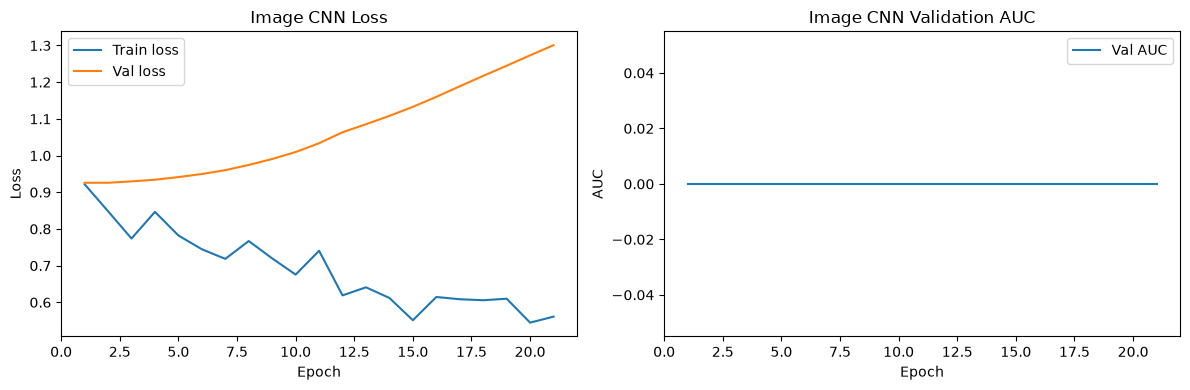

Saved: C:\Users\Administrator\Documents\Biopark\Projeto-Integrador-3\PI3-Grupo-03\models\image_cnn\image_cnn_training_curves.png


In [165]:
# Cell 9 — Plot Training Curves

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history_df["epoch"], history_df["train_loss"], label="Train loss")
plt.plot(history_df["epoch"], history_df["val_loss"], label="Val loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Image CNN Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_df["epoch"], history_df["val_auc"], label="Val AUC")
plt.xlabel("Epoch")
plt.ylabel("AUC")
plt.title("Image CNN Validation AUC")
plt.legend()

plt.tight_layout()

curve_path = os.path.join(OUTPUT_DIR, "image_cnn_training_curves.png")
plt.savefig(curve_path, dpi=150)
plt.show()

print("Saved:", curve_path)

In [166]:
# Cell 10 — Evaluate Best Image CNN on Test Set

best_model = ImageCNN().to(DEVICE)
best_model.load_state_dict(torch.load(best_model_path, map_location=DEVICE))

test_loss, test_probs, test_labels = run_epoch(
    best_model,
    test_loader,
    criterion=criterion,
    optimizer=None
)

test_metrics = compute_metrics(test_labels, test_probs, threshold=0.5)

print("Image-only CNN Test Results")
print("=" * 50)

for key, value in test_metrics.items():
    print(f"{key}: {value}")

print("\nConfusion Matrix:")
cm = np.array([
    [test_metrics["tn"], test_metrics["fp"]],
    [test_metrics["fn"], test_metrics["tp"]]
])
print(cm)

print("\nClassification Report:")
print(
    classification_report(
        test_labels,
        (test_probs >= 0.5).astype(int),
        target_names=["Benign", "Malignant"],
        zero_division=0
    )
)

Image-only CNN Test Results
accuracy: 0.0
auc: nan
precision: 0.0
sensitivity: 0.0
specificity: 0
f1: 0.0
tn: 0
fp: 0
fn: 3
tp: 0

Confusion Matrix:
[[0 0]
 [3 0]]

Classification Report:
              precision    recall  f1-score   support

      Benign       0.00      0.00      0.00       0.0
   Malignant       0.00      0.00      0.00       3.0

    accuracy                           0.00       3.0
   macro avg       0.00      0.00      0.00       3.0
weighted avg       0.00      0.00      0.00       3.0



In [167]:
# Cell 11 — Save Image-only CNN Result

image_result = pd.DataFrame([{
    "model": "Image-only CNN",
    "accuracy": test_metrics["accuracy"],
    "auc": test_metrics["auc"],
    "precision": test_metrics["precision"],
    "sensitivity": test_metrics["sensitivity"],
    "specificity": test_metrics["specificity"],
    "f1": test_metrics["f1"],
    "tn": test_metrics["tn"],
    "fp": test_metrics["fp"],
    "fn": test_metrics["fn"],
    "tp": test_metrics["tp"]
}])

image_result_path = os.path.join(OUTPUT_DIR, "image_only_cnn_results.csv")
image_result.to_csv(image_result_path, index=False)

display(image_result)

print("Saved results to:", image_result_path)

,model,accuracy,auc,precision,sensitivity,specificity,f1,tn,fp,fn,tp
0,Image-only CNN,0.0,NaN,0.0,0.0,0,0.0,0,0,3,0


Saved results to: C:\Users\Administrator\Documents\Biopark\Projeto-Integrador-3\PI3-Grupo-03\models\image_cnn\image_only_cnn_results.csv


In [168]:
# validation-based threshold tuning

# Get validation probabilities from best image CNN
val_loss, val_probs, val_labels = run_epoch(
    best_model,
    val_loader,
    criterion=criterion,
    optimizer=None
)

test_loss, test_probs, test_labels = run_epoch(
    best_model,
    test_loader,
    criterion=criterion,
    optimizer=None
)

print("Validation AUC:", roc_auc_score(val_labels, val_probs))
print("Test AUC:", roc_auc_score(test_labels, test_probs))

Validation AUC: 0.0
Test AUC: nan


c:\Users\Administrator\Documents\Biopark\Projeto-Integrador-3\PI3-Grupo-03\.venv\Lib\site-packages\sklearn\metrics\_ranking.py:469: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


In [169]:
# Find best threshold by Youden’s J statistic
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(val_labels, val_probs)

youden_j = tpr - fpr
best_idx = np.argmax(youden_j)
best_threshold = thresholds[best_idx]

print("Best validation threshold:", best_threshold)
print("Validation sensitivity at best threshold:", tpr[best_idx])
print("Validation specificity at best threshold:", 1 - fpr[best_idx])

Best validation threshold: inf
Validation sensitivity at best threshold: 0.0
Validation specificity at best threshold: 1.0


In [170]:
# Re-evaluate test set using tuned threshold
tuned_test_metrics = compute_metrics(
    test_labels,
    test_probs,
    threshold=best_threshold
)

print("Image-only CNN Test Results with Tuned Threshold")
print("=" * 55)

for key, value in tuned_test_metrics.items():
    print(f"{key}: {value}")

print("\nConfusion Matrix:")
print(np.array([
    [tuned_test_metrics["tn"], tuned_test_metrics["fp"]],
    [tuned_test_metrics["fn"], tuned_test_metrics["tp"]]
]))

Image-only CNN Test Results with Tuned Threshold
accuracy: 0.0
auc: nan
precision: 0.0
sensitivity: 0.0
specificity: 0
f1: 0.0
tn: 0
fp: 0
fn: 3
tp: 0

Confusion Matrix:
[[0 0]
 [3 0]]


In [171]:
# Save tuned result

image_result_tuned = pd.DataFrame([{
    "model": "Image-only CNN tuned threshold",
    "threshold": best_threshold,
    "accuracy": tuned_test_metrics["accuracy"],
    "auc": tuned_test_metrics["auc"],
    "precision": tuned_test_metrics["precision"],
    "sensitivity": tuned_test_metrics["sensitivity"],
    "specificity": tuned_test_metrics["specificity"],
    "f1": tuned_test_metrics["f1"],
    "tn": tuned_test_metrics["tn"],
    "fp": tuned_test_metrics["fp"],
    "fn": tuned_test_metrics["fn"],
    "tp": tuned_test_metrics["tp"]
}])

image_result_tuned_path = os.path.join(
    OUTPUT_DIR,
    "image_only_cnn_tuned_threshold_results.csv"
)

image_result_tuned.to_csv(image_result_tuned_path, index=False)

display(image_result_tuned)

print("Saved tuned result to:", image_result_tuned_path)

,model,threshold,accuracy,auc,precision,sensitivity,specificity,f1,tn,fp,fn,tp
0,Image-only CNN tuned threshold,inf,0.0,NaN,0.0,0.0,0,0.0,0,0,3,0


Saved tuned result to: C:\Users\Administrator\Documents\Biopark\Projeto-Integrador-3\PI3-Grupo-03\models\image_cnn\image_only_cnn_tuned_threshold_results.csv


# **CNN–MLP fusion architecture:**
Image branch:
1×64×64 CT crop
→ Conv(1→32) + BN + ReLU + MaxPool
→ Conv(32→64) + BN + ReLU + MaxPool
→ Conv(64→128) + BN + ReLU + MaxPool
→ AdaptiveAvgPool
→ 128-d image embedding
→ Linear(128→64) + ReLU
→ 64-d image feature

Semantic branch:
8 scaled semantic attributes
→ Linear(8→64) + BN + ReLU + Dropout(0.3)
→ Linear(64→32) + BN + ReLU + Dropout(0.3)
→ 32-d semantic feature

Fusion:
64-d image feature + 32-d semantic feature
→ Concatenate = 96-d
→ Linear(96→64) + ReLU + Dropout(0.4)
→ Linear(64→1)
→ raw logit

# Code for Experiment 3: Multimodal CNN–MLP Fusion

In [172]:
# Cell 1 — Setup
import os
import random
import joblib
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

import matplotlib.pyplot as plt

OUTPUT_DIR = FUSION_DIR
os.makedirs(OUTPUT_DIR, exist_ok=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

SEED = 42
set_seed(SEED)


Using device: cpu


In [173]:
# Cell 2 — Define columns and safety checks

semantic_cols = [
    "subtlety_mean",
    "internalStructure_mean",
    "calcification_mean",
    "sphericity_mean",
    "margin_mean",
    "lobulation_mean",
    "spiculation_mean",
    "texture_mean"
]

image_col = "crop_path"
target_col = "label"

# Safety checks
for col in semantic_cols:
    assert col in train_df.columns, f"Missing semantic column: {col}"

assert image_col in train_df.columns, f"Missing image column: {image_col}"
assert target_col in train_df.columns, f"Missing target column: {target_col}"

# Very important: label-source columns must not be used as semantic inputs
for forbidden_col in ["malignancy_mean", "malignancy_std", "malignancy_count", "label"]:
    assert forbidden_col not in semantic_cols, f"Leakage risk: {forbidden_col} is in semantic_cols"

print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)

print("\nTrain label distribution:")
print(train_df[target_col].value_counts())

print("\nValidation label distribution:")
print(val_df[target_col].value_counts())

print("\nTest label distribution:")
print(test_df[target_col].value_counts())

Train: (21, 53)
Validation: (3, 53)
Test: (3, 53)

Train label distribution:
label
0    14
1     7
Name: count, dtype: int64

Validation label distribution:
label
0    2
1    1
Name: count, dtype: int64

Test label distribution:
label
1    3
Name: count, dtype: int64


In [174]:
# Cell 3 — Standardise semantic features using train set only
scaler = StandardScaler()

X_train_sem = scaler.fit_transform(train_df[semantic_cols].values).astype(np.float32)
X_val_sem   = scaler.transform(val_df[semantic_cols].values).astype(np.float32)
X_test_sem  = scaler.transform(test_df[semantic_cols].values).astype(np.float32)

y_train = train_df[target_col].values.astype(np.float32)
y_val   = val_df[target_col].values.astype(np.float32)
y_test  = test_df[target_col].values.astype(np.float32)

scaler_path = os.path.join(OUTPUT_DIR, "fusion_semantic_scaler.pkl")
joblib.dump(scaler, scaler_path)

print("X_train_sem:", X_train_sem.shape)
print("X_val_sem:", X_val_sem.shape)
print("X_test_sem:", X_test_sem.shape)
print("Scaler saved to:", scaler_path)

X_train_sem: (21, 8)
X_val_sem: (3, 8)
X_test_sem: (3, 8)
Scaler saved to: C:\Users\Administrator\Documents\Biopark\Projeto-Integrador-3\PI3-Grupo-03\models\fusion_cnn_mlp\fusion_semantic_scaler.pkl


In [175]:
# Cell 4 — Compute image mean and standard deviation using train set only

def load_crop(path):
    crop = np.load(path).astype(np.float32)

    if crop.shape != (64, 64):
        raise ValueError(f"Unexpected crop shape {crop.shape} for {path}")

    return crop

train_pixels = []

for path in train_df[image_col].values:
    train_pixels.append(load_crop(path))

train_pixels = np.stack(train_pixels)

img_mean = float(train_pixels.mean())
img_std = float(train_pixels.std())

if img_std < 1e-6:
    img_std = 1.0

np.save(os.path.join(OUTPUT_DIR, "fusion_image_mean.npy"), img_mean)
np.save(os.path.join(OUTPUT_DIR, "fusion_image_std.npy"), img_std)

print("Train image mean:", img_mean)
print("Train image std:", img_std)


Train image mean: 0.3797955811023712
Train image std: 0.3160450756549835


In [176]:
# Cell 5 — Multimodal Dataset and DataLoaders

class MultimodalDataset(Dataset):
    def __init__(
        self,
        df,
        X_sem,
        y,
        image_col,
        img_mean,
        img_std,
        augment=False
    ):
        self.df = df.reset_index(drop=True)
        self.X_sem = X_sem.astype(np.float32)
        self.y = y.astype(np.float32)
        self.image_col = image_col
        self.img_mean = img_mean
        self.img_std = img_std
        self.augment = augment

        assert len(self.df) == len(self.X_sem) == len(self.y)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        # Image branch input
        img = np.load(row[self.image_col]).astype(np.float32)

        if img.shape != (64, 64):
            raise ValueError(f"Unexpected image shape {img.shape}")

        # Lightweight augmentation for training only
        if self.augment:
            if np.random.rand() < 0.5:
                img = np.fliplr(img).copy()

            if np.random.rand() < 0.5:
                img = np.flipud(img).copy()

            k = np.random.choice([0, 1, 2, 3])
            img = np.rot90(img, k).copy()

        # Standardise image using train statistics
        img = (img - self.img_mean) / self.img_std

        img = torch.tensor(img, dtype=torch.float32).unsqueeze(0)  # 1×64×64

        # Semantic branch input
        sem = torch.tensor(self.X_sem[idx], dtype=torch.float32)   # 8-d

        label = torch.tensor(self.y[idx], dtype=torch.float32)

        return img, sem, label

def seed_worker(worker_id):
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

BATCH_SIZE = 32

generator = torch.Generator()
generator.manual_seed(SEED)

train_loader = DataLoader(
    MultimodalDataset(
        train_df, X_train_sem, y_train,
        image_col=image_col,
        img_mean=img_mean,
        img_std=img_std,
        augment=True
    ),
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    worker_init_fn=seed_worker,
    generator=generator
)

val_loader = DataLoader(
    MultimodalDataset(
        val_df, X_val_sem, y_val,
        image_col=image_col,
        img_mean=img_mean,
        img_std=img_std,
        augment=False
    ),
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

test_loader = DataLoader(
    MultimodalDataset(
        test_df, X_test_sem, y_test,
        image_col=image_col,
        img_mean=img_mean,
        img_std=img_std,
        augment=False
    ),
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))



Train batches: 1
Validation batches: 1
Test batches: 1


In [177]:
# Cell 6 — Fusion model architecture

class MultimodalFusion(nn.Module):
    """
    Experiment 3: lightweight CNN–MLP fusion model.

    Image branch:
        1×64×64 CT crop → CNN → 128-d → Linear(128→64)

    Semantic branch:
        8 scaled radiologist attributes → MLP → 32-d

    Fusion:
        concat(64 + 32) → 96-d → classifier → 1 raw logit
    """

    def __init__(self, dropout_branch=0.3, dropout_head=0.4):
        super().__init__()

        # CNN image encoder
        self.cnn = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),  # 32×32×32

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),  # 64×16×16

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),  # 128×8×8

            nn.AdaptiveAvgPool2d(1),
            nn.Flatten()      # 128-d
        )

        # Image projection: 128-d → 64-d
        self.img_proj = nn.Sequential(
            nn.Linear(128, 64),
            nn.ReLU()
        )

        # Semantic encoder: identical to semantic-only MLP encoder
        self.mlp = nn.Sequential(
            nn.Linear(8, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(dropout_branch),

            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(dropout_branch)
        )

        # Fusion classifier head
        self.classifier = nn.Sequential(
            nn.Linear(96, 64),
            nn.ReLU(),
            nn.Dropout(dropout_head),
            nn.Linear(64, 1)
        )

    def forward(self, img, sem):
        img_feat = self.img_proj(self.cnn(img))   # B×64
        sem_feat = self.mlp(sem)                  # B×32
        fused = torch.cat([img_feat, sem_feat], dim=1)  # B×96
        logit = self.classifier(fused).squeeze(1)
        return logit

    def get_image_embedding(self, img):
        return self.img_proj(self.cnn(img))

    def get_semantic_embedding(self, sem):
        return self.mlp(sem)

model = MultimodalFusion().to(DEVICE)

print(model)

num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("\nTrainable parameters:", num_params)


MultimodalFusion(
  (cnn): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): AdaptiveAvgPool2d(output_size=1)
    (13): Flatten(start_dim=1, end_dim=-1)
  )
  (img_proj): Sequential(
    (0): Linear(i

In [178]:
# Cell 7 — Loss, optimiser, and scheduler

num_neg = int((y_train == 0).sum())
num_pos = int((y_train == 1).sum())

pos_weight_value = num_neg / num_pos
pos_weight = torch.tensor([pos_weight_value], dtype=torch.float32).to(DEVICE)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=10
)

print("Benign train samples:", num_neg)
print("Malignant train samples:", num_pos)
print("pos_weight:", pos_weight_value)

Benign train samples: 14
Malignant train samples: 7
pos_weight: 2.0


In [179]:
# Cell 8 — Training and metric functions

def compute_metrics(y_true, y_prob, threshold=0.5):
    y_pred = (y_prob >= threshold).astype(int)

    acc = accuracy_score(y_true, y_pred)
    if len(np.unique(y_true)) > 1:
        auc = roc_auc_score(y_true, y_prob)
    else:
        auc = float("nan")
    precision = precision_score(y_true, y_pred, zero_division=0)
    sensitivity = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)

    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()

    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0

    return {
        "accuracy": acc,
        "auc": auc,
        "precision": precision,
        "sensitivity": sensitivity,
        "specificity": specificity,
        "f1": f1,
        "tn": tn,
        "fp": fp,
        "fn": fn,
        "tp": tp
    }

def run_epoch(model, loader, criterion=None, optimizer=None):
    is_train = optimizer is not None

    if is_train:
        model.train()
    else:
        model.eval()

    total_loss = 0.0
    all_probs = []
    all_labels = []

    with torch.set_grad_enabled(is_train):
        for img_batch, sem_batch, y_batch in loader:
            img_batch = img_batch.to(DEVICE)
            sem_batch = sem_batch.to(DEVICE)
            y_batch = y_batch.to(DEVICE)

            logits = model(img_batch, sem_batch)

            loss = criterion(logits, y_batch)

            if is_train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            probs = torch.sigmoid(logits)

            total_loss += loss.item() * img_batch.size(0)
            all_probs.extend(probs.detach().cpu().numpy())
            all_labels.extend(y_batch.detach().cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)

    return avg_loss, np.array(all_probs), np.array(all_labels)

def get_youden_threshold(y_true, y_prob):
    fpr, tpr, thresholds = roc_curve(y_true, y_prob)

    # Remove infinite threshold if present
    finite_mask = np.isfinite(thresholds)
    fpr = fpr[finite_mask]
    tpr = tpr[finite_mask]
    thresholds = thresholds[finite_mask]

    youden_j = tpr - fpr
    best_idx = np.argmax(youden_j)

    best_threshold = float(thresholds[best_idx])
    best_sensitivity = float(tpr[best_idx])
    best_specificity = float(1 - fpr[best_idx])

    return best_threshold, best_sensitivity, best_specificity


In [180]:
# Cell 9 — Train fusion model

EPOCHS = 100
EARLY_STOPPING_PATIENCE = 20

best_val_auc = 0.0
best_epoch = 0
epochs_without_improvement = 0

best_model_path = os.path.join(OUTPUT_DIR, "best_fusion_cnn_mlp.pth")

history = []

# Force single-process DataLoaders (Windows/Jupyter-safe)
from torch.utils.data import DataLoader as _DataLoader

train_loader = _DataLoader(
    train_loader.dataset,
    batch_size=train_loader.batch_size,
    shuffle=True,
    num_workers=0,
)
val_loader = _DataLoader(
    val_loader.dataset,
    batch_size=val_loader.batch_size,
    shuffle=False,
    num_workers=0,
)
if "test_loader" in globals():
    test_loader = _DataLoader(
        test_loader.dataset,
        batch_size=test_loader.batch_size,
        shuffle=False,
        num_workers=0,
    )

for epoch in range(1, EPOCHS + 1):
    train_loss, train_probs, train_labels = run_epoch(
        model,
        train_loader,
        criterion=criterion,
        optimizer=optimizer
    )

    val_loss, val_probs, val_labels = run_epoch(
        model,
        val_loader,
        criterion=criterion,
        optimizer=None
    )

    train_metrics = compute_metrics(train_labels, train_probs, threshold=0.5)
    val_metrics = compute_metrics(val_labels, val_probs, threshold=0.5)

    val_auc = val_metrics["auc"]

    scheduler.step(val_auc)

    history.append({
        "epoch": epoch,
        "train_loss": train_loss,
        "val_loss": val_loss,
        "train_auc": train_metrics["auc"],
        "val_auc": val_auc,
        "train_f1": train_metrics["f1"],
        "val_f1": val_metrics["f1"],
        "val_sensitivity": val_metrics["sensitivity"],
        "val_specificity": val_metrics["specificity"]
    })

    if val_auc > best_val_auc:
        best_val_auc = val_auc
        best_epoch = epoch
        epochs_without_improvement = 0

        torch.save(model.state_dict(), best_model_path)

        print(
            f"Epoch {epoch:03d} | "
            f"train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | "
            f"train_auc={train_metrics['auc']:.4f} | val_auc={val_auc:.4f} | "
            f"BEST"
        )
    else:
        epochs_without_improvement += 1

        if epoch % 10 == 0:
            print(
                f"Epoch {epoch:03d} | "
                f"train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | "
                f"train_auc={train_metrics['auc']:.4f} | val_auc={val_auc:.4f}"
            )

    if epochs_without_improvement >= EARLY_STOPPING_PATIENCE:
        print(f"\nEarly stopping at epoch {epoch}.")
        break

history_df = pd.DataFrame(history)
history_path = os.path.join(OUTPUT_DIR, "fusion_training_history.csv")
history_df.to_csv(history_path, index=False)

print("\nBest validation AUC:", best_val_auc)
print("Best epoch:", best_epoch)
print("Best model saved to:", best_model_path)
print("History saved to:", history_path)


Epoch 010 | train_loss=0.7495 | val_loss=0.9506 | train_auc=0.9796 | val_auc=0.0000
Epoch 020 | train_loss=0.5729 | val_loss=1.0543 | train_auc=1.0000 | val_auc=0.0000

Early stopping at epoch 20.

Best validation AUC: 0.0
Best epoch: 0
Best model saved to: C:\Users\Administrator\Documents\Biopark\Projeto-Integrador-3\PI3-Grupo-03\models\fusion_cnn_mlp\best_fusion_cnn_mlp.pth
History saved to: C:\Users\Administrator\Documents\Biopark\Projeto-Integrador-3\PI3-Grupo-03\models\fusion_cnn_mlp\fusion_training_history.csv


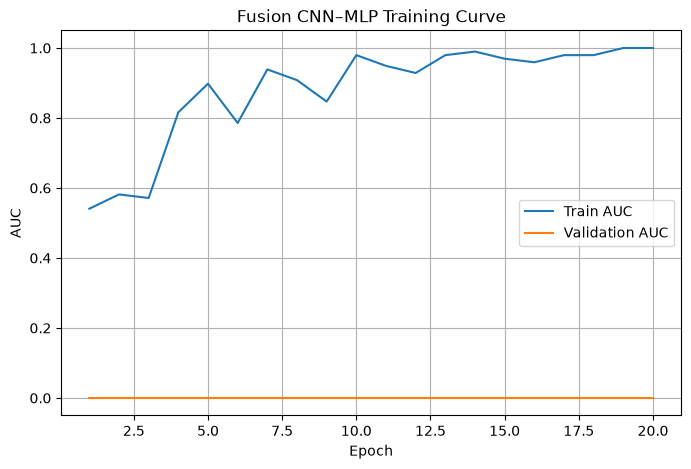

In [181]:
# Cell 10 — Plot training curve

plt.figure(figsize=(8, 5))
plt.plot(history_df["epoch"], history_df["train_auc"], label="Train AUC")
plt.plot(history_df["epoch"], history_df["val_auc"], label="Validation AUC")
plt.xlabel("Epoch")
plt.ylabel("AUC")
plt.title("Fusion CNN–MLP Training Curve")
plt.legend()
plt.grid(True)
plt.show()

In [182]:
# Cell 11 — Evaluate best fusion model at threshold 0.5

best_model = MultimodalFusion().to(DEVICE)
best_model.load_state_dict(torch.load(best_model_path, map_location=DEVICE))

test_loss, test_probs, test_labels = run_epoch(
    best_model,
    test_loader,
    criterion=criterion,
    optimizer=None
)

test_metrics_05 = compute_metrics(
    test_labels,
    test_probs,
    threshold=0.5
)

print("Fusion CNN–MLP Test Results | Threshold = 0.5")
print("=" * 60)

for key, value in test_metrics_05.items():
    print(f"{key}: {value}")

print("\nConfusion Matrix:")
print(np.array([
    [test_metrics_05["tn"], test_metrics_05["fp"]],
    [test_metrics_05["fn"], test_metrics_05["tp"]]
]))

print("\nClassification Report:")
print(
    classification_report(
        test_labels,
        (test_probs >= 0.5).astype(int),
        target_names=["Benign", "Malignant"],
        zero_division=0
    )
)

Fusion CNN–MLP Test Results | Threshold = 0.5
accuracy: 0.0
auc: nan
precision: 0.0
sensitivity: 0.0
specificity: 0.0
f1: 0.0
tn: 0
fp: 0
fn: 3
tp: 0

Confusion Matrix:
[[0 0]
 [3 0]]

Classification Report:
              precision    recall  f1-score   support

      Benign       0.00      0.00      0.00       0.0
   Malignant       0.00      0.00      0.00       3.0

    accuracy                           0.00       3.0
   macro avg       0.00      0.00      0.00       3.0
weighted avg       0.00      0.00      0.00       3.0



In [183]:
# Cell 12 — Validation-based Youden’s J threshold tuning

val_loss, val_probs, val_labels = run_epoch(
    best_model,
    val_loader,
    criterion=criterion,
    optimizer=None
)

best_threshold, val_sens_at_thr, val_spec_at_thr = get_youden_threshold(
    val_labels,
    val_probs
)

print("Best validation threshold:", best_threshold)
print("Validation sensitivity at threshold:", val_sens_at_thr)
print("Validation specificity at threshold:", val_spec_at_thr)

test_metrics_youden = compute_metrics(
    test_labels,
    test_probs,
    threshold=best_threshold
)

print("\nFusion CNN–MLP Test Results | Validation Youden's J Threshold")
print("=" * 70)

for key, value in test_metrics_youden.items():
    print(f"{key}: {value}")

print("\nConfusion Matrix:")
print(np.array([
    [test_metrics_youden["tn"], test_metrics_youden["fp"]],
    [test_metrics_youden["fn"], test_metrics_youden["tp"]]
]))

Best validation threshold: 0.4811529815196991
Validation sensitivity at threshold: 1.0
Validation specificity at threshold: 1.0

Fusion CNN–MLP Test Results | Validation Youden's J Threshold
accuracy: 1.0
auc: nan
precision: 1.0
sensitivity: 1.0
specificity: 0.0
f1: 1.0
tn: 0
fp: 0
fn: 0
tp: 3

Confusion Matrix:
[[0 0]
 [0 3]]


In [184]:
# Cell 13 — Save fusion results

fusion_results = pd.DataFrame([
    {
        "model": "Fusion CNN-MLP",
        "threshold_type": "default_0.5",
        "threshold": 0.5,
        **test_metrics_05
    },
    {
        "model": "Fusion CNN-MLP",
        "threshold_type": "validation_youden_j",
        "threshold": best_threshold,
        **test_metrics_youden
    }
])

fusion_results_path = os.path.join(
    OUTPUT_DIR,
    "fusion_cnn_mlp_test_results.csv"
)

fusion_results.to_csv(fusion_results_path, index=False)

display(fusion_results)

print("Fusion results saved to:", fusion_results_path)

,model,threshold_type,threshold,accuracy,auc,precision,sensitivity,specificity,f1,tn,fp,fn,tp
0,Fusion CNN-MLP,default_0.5,0.500000,0.0,NaN,0.0,0.0,0.0,0.0,0,0,3,0
1,Fusion CNN-MLP,validation_youden_j,0.481153,1.0,NaN,1.0,1.0,0.0,1.0,0,0,0,3


Fusion results saved to: C:\Users\Administrator\Documents\Biopark\Projeto-Integrador-3\PI3-Grupo-03\models\fusion_cnn_mlp\fusion_cnn_mlp_test_results.csv


In [185]:
# Cell 14 — Save test probabilities for later analysis
test_predictions_df = test_df.copy()
test_predictions_df["fusion_prob"] = test_probs
test_predictions_df["fusion_pred_05"] = (test_probs >= 0.5).astype(int)
test_predictions_df["fusion_pred_youden"] = (test_probs >= best_threshold).astype(int)
test_predictions_df["fusion_correct_05"] = (
    test_predictions_df["fusion_pred_05"].values == test_predictions_df[target_col].values
)
test_predictions_df["fusion_correct_youden"] = (
    test_predictions_df["fusion_pred_youden"].values == test_predictions_df[target_col].values
)

pred_path = os.path.join(
    OUTPUT_DIR,
    "fusion_cnn_mlp_test_predictions.csv"
)

test_predictions_df.to_csv(pred_path, index=False)

display(
    test_predictions_df[
        [
            "patient_id",
            "label",
            "malignancy_mean",
            "fusion_prob",
            "fusion_pred_05",
            "fusion_pred_youden",
            "fusion_correct_05",
            "fusion_correct_youden"
        ]
    ].head()
)

print("Test predictions saved to:", pred_path)


,patient_id,label,malignancy_mean,fusion_prob,fusion_pred_05,fusion_pred_youden,fusion_correct_05,fusion_correct_youden
0,LIDC-IDRI-0016,1,4.00,0.483316,0,1,False,True
1,LIDC-IDRI-0016,1,4.50,0.490164,0,1,False,True
2,LIDC-IDRI-0013,1,4.75,0.489895,0,1,False,True


Test predictions saved to: C:\Users\Administrator\Documents\Biopark\Projeto-Integrador-3\PI3-Grupo-03\models\fusion_cnn_mlp\fusion_cnn_mlp_test_predictions.csv


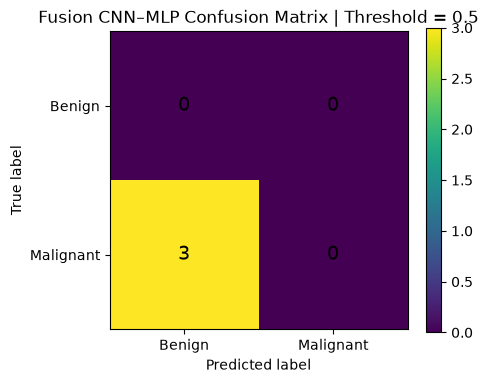

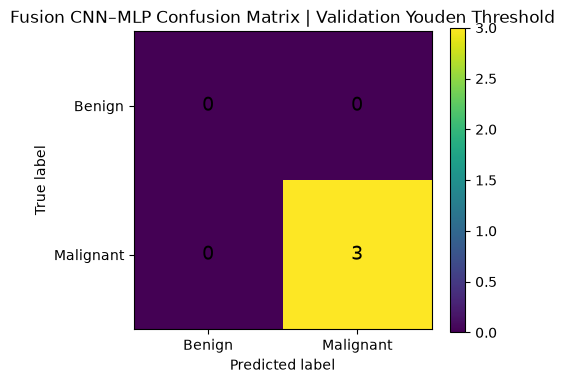

In [186]:
# Cell 15 — Plot confusion matrices

import matplotlib.pyplot as plt
import numpy as np

def plot_confusion_matrix_from_metrics(metrics, title):
    cm = np.array([
        [metrics["tn"], metrics["fp"]],
        [metrics["fn"], metrics["tp"]]
    ])

    plt.figure(figsize=(5, 4))
    plt.imshow(cm)
    plt.title(title)
    plt.xlabel("Predicted label")
    plt.ylabel("True label")
    plt.xticks([0, 1], ["Benign", "Malignant"])
    plt.yticks([0, 1], ["Benign", "Malignant"])

    for i in range(2):
        for j in range(2):
            plt.text(j, i, cm[i, j], ha="center", va="center", fontsize=14)

    plt.colorbar()
    plt.tight_layout()
    plt.show()

plot_confusion_matrix_from_metrics(
    test_metrics_05,
    "Fusion CNN–MLP Confusion Matrix | Threshold = 0.5"
)

plot_confusion_matrix_from_metrics(
    test_metrics_youden,
    "Fusion CNN–MLP Confusion Matrix | Validation Youden Threshold"
)


c:\Users\Administrator\Documents\Biopark\Projeto-Integrador-3\PI3-Grupo-03\.venv\Lib\site-packages\sklearn\metrics\_ranking.py:1355: UndefinedMetricWarning: No negative samples in y_true, false positive value should be meaningless
  warnings.warn(


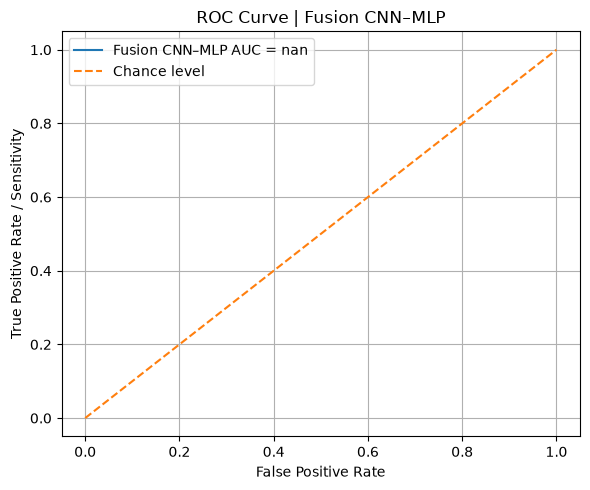

In [187]:
# Cell 16 — Plot ROC curve

from sklearn.metrics import roc_curve, auc

fpr, tpr, thresholds = roc_curve(test_labels, test_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"Fusion CNN–MLP AUC = {roc_auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--", label="Chance level")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate / Sensitivity")
plt.title("ROC Curve | Fusion CNN–MLP")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [188]:
# Cell 17 — Publication-style CT crop plotting with nodule marker

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import math
import os

def add_nodule_marker(
    ax,
    img_shape=(64, 64),
    center_x=None,
    center_y=None,
    radius=9,
    marker_type="circle",
    color="red"
):
    """
    Add a visual marker around the target nodule region.

    Default:
    - uses the crop centre, because the 64×64 crop was extracted around
      the annotation-derived nodule location.

    This marker is for visualisation only.
    It was not provided to the model during training or inference.
    """

    h, w = img_shape

    if center_x is None:
        center_x = w / 2

    if center_y is None:
        center_y = h / 2

    if marker_type == "circle":
        marker = patches.Circle(
            (center_x, center_y),
            radius=radius,
            linewidth=1.8,
            edgecolor=color,
            facecolor="none",
            linestyle="--"
        )
        ax.add_patch(marker)

    elif marker_type == "box":
        marker = patches.Rectangle(
            (center_x - radius, center_y - radius),
            2 * radius,
            2 * radius,
            linewidth=1.8,
            edgecolor=color,
            facecolor="none",
            linestyle="--"
        )
        ax.add_patch(marker)

def plot_case_grid_publication(
    df,
    threshold=0.5,
    title="Fusion CNN–MLP Test Cases",
    max_cases=8,
    ncols=4,
    save_path=None,
    display_mode="percentile",
    show_marker=True,
    marker_radius=9
):
    """
    Publication-style CT crop grid.

    display_mode:
        "fixed"      -> same vmin/vmax across all selected images
        "percentile" -> 1st–99th percentile contrast per image for display only

    show_marker:
        True -> adds a dashed circle around the crop centre / target nodule region.
    """

    plot_df = df.copy().head(max_cases).reset_index(drop=True)

    

    if len(plot_df) == 0:
        print(f"[skip] No cases to plot for: {title}")
        return None

    plot_df["pred"] = (plot_df["fusion_prob"] >= threshold).astype(int)
    plot_df["correct"] = plot_df["pred"] == plot_df["label"]

    n = len(plot_df)
    nrows = max(1, math.ceil(n / ncols))

    # Load images first
    images = []
    for _, row in plot_df.iterrows():
        img = np.load(row["crop_path"]).astype(np.float32)

        if img.shape != (64, 64):
            raise ValueError(f"Unexpected image shape: {img.shape}")

        images.append(img)

    # Fixed visual scale across selected images
    if display_mode == "fixed":
        global_vmin = min(img.min() for img in images)
        global_vmax = max(img.max() for img in images)
    else:
        global_vmin, global_vmax = None, None

    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(4.2 * ncols, 4.8 * nrows)
    )

    axes = np.array(axes).reshape(-1)

    for i, row in plot_df.iterrows():
        ax = axes[i]
        img = images[i]

        true_label = "Malignant" if row["label"] == 1 else "Benign"
        pred_label = "Malignant" if row["pred"] == 1 else "Benign"

        if row["label"] == 0 and row["pred"] == 1:
            case_type = "FP"
        elif row["label"] == 1 and row["pred"] == 0:
            case_type = "FN"
        elif row["label"] == 1 and row["pred"] == 1:
            case_type = "TP"
        else:
            case_type = "TN"

        if display_mode == "percentile":
            vmin = np.percentile(img, 1)
            vmax = np.percentile(img, 99)
        else:
            vmin = global_vmin
            vmax = global_vmax

        ax.imshow(
            img,
            cmap="gray",
            vmin=vmin,
            vmax=vmax,
            interpolation="nearest"
        )

        if show_marker:
            add_nodule_marker(
                ax,
                img_shape=img.shape,
                radius=marker_radius,
                marker_type="circle",
                color="red"
            )

        ax.axis("off")

        ax.set_title(
            f"{case_type} | True: {true_label}\n"
            f"Pred: {pred_label} | P={row['fusion_prob']:.3f}",
            fontsize=10,
            pad=8
        )

    # Hide unused axes
    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

    fig.suptitle(title, fontsize=16, y=0.995)

    plt.subplots_adjust(
        top=0.84,
        hspace=0.45,
        wspace=0.12
    )

    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")

    plt.show()


,patient_id,label,malignancy_mean,fusion_prob,pred,correct
0,LIDC-IDRI-0016,1,4.00,0.483316,0,False
1,LIDC-IDRI-0013,1,4.75,0.489895,0,False


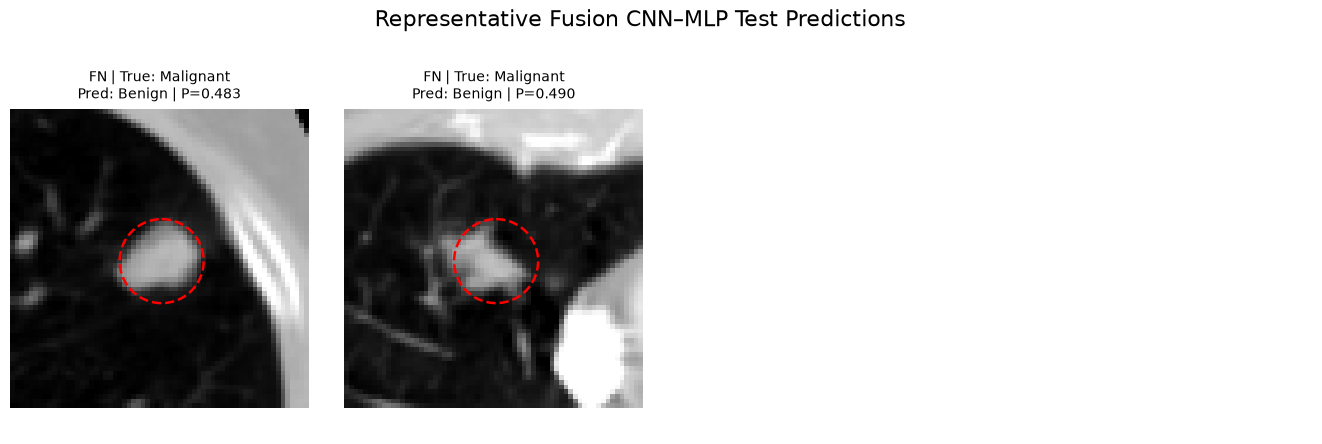

In [189]:
# Cell 18 — Show representative CT crops with predictions

threshold_to_display = 0.5

display_df = test_predictions_df.copy()
display_df["pred"] = (display_df["fusion_prob"] >= threshold_to_display).astype(int)
display_df["correct"] = display_df["pred"] == display_df["label"]

correct_benign = display_df[
    (display_df["label"] == 0) &
    (display_df["pred"] == 0)
].sort_values("fusion_prob", ascending=True).head(2)

correct_malignant = display_df[
    (display_df["label"] == 1) &
    (display_df["pred"] == 1)
].sort_values("fusion_prob", ascending=False).head(2)

false_positive = display_df[
    (display_df["label"] == 0) &
    (display_df["pred"] == 1)
].sort_values("fusion_prob", ascending=False).head(2)

false_negative = display_df[
    (display_df["label"] == 1) &
    (display_df["pred"] == 0)
].sort_values("fusion_prob", ascending=True).head(2)

selected_cases = pd.concat([
    correct_benign,
    correct_malignant,
    false_positive,
    false_negative
]).reset_index(drop=True)

display(
    selected_cases[
        [
            "patient_id",
            "label",
            "malignancy_mean",
            "fusion_prob",
            "pred",
            "correct"
        ]
    ]
)

plot_case_grid_publication(
    selected_cases,
    threshold=threshold_to_display,
    title="Representative Fusion CNN–MLP Test Predictions",
    max_cases=len(selected_cases),
    ncols=4,
    save_path=f"{FUSION_DIR}/fusion_representative_cases_with_marker.png",
    display_mode="percentile",
    show_marker=True,
    marker_radius=9
)


In [190]:
# Cell 19 — Show high-confidence false positives

fp_cases = display_df[
    (display_df["label"] == 0) &
    (display_df["pred"] == 1)
].sort_values("fusion_prob", ascending=False)

display(
    fp_cases[
        [
            "patient_id",
            "label",
            "malignancy_mean",
            "fusion_prob",
            "pred",
            "correct"
        ]
    ]
)

plot_case_grid_publication(
    fp_cases.head(4),
    threshold=threshold_to_display,
    title="High-Confidence False Positive Cases | Fusion CNN–MLP",
    max_cases=min(4, len(fp_cases)),
    ncols=3,
    save_path=f"{FUSION_DIR}/fusion_false_positive_cases_with_marker.png",
    display_mode="percentile",
    show_marker=True,
    marker_radius=9
)


,patient_id,label,malignancy_mean,fusion_prob,pred,correct


[skip] No cases to plot for: High-Confidence False Positive Cases | Fusion CNN–MLP


,patient_id,label,malignancy_mean,fusion_prob,pred,correct
0,LIDC-IDRI-0016,1,4.00,0.483316,0,False
2,LIDC-IDRI-0013,1,4.75,0.489895,0,False
1,LIDC-IDRI-0016,1,4.50,0.490164,0,False


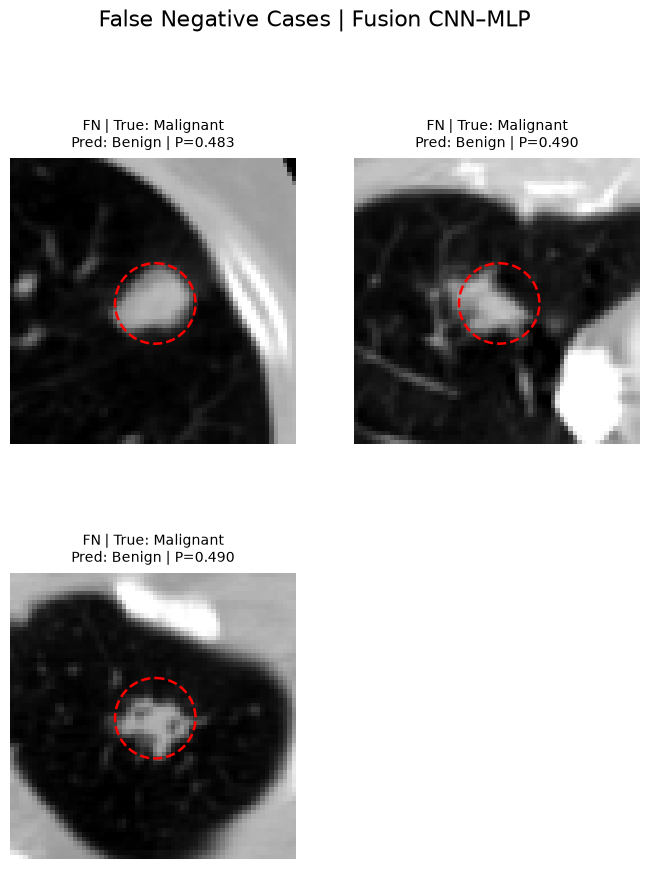

In [191]:
# Cell 20 — Show false negatives

fn_cases = display_df[
    (display_df["label"] == 1) &
    (display_df["pred"] == 0)
].sort_values("fusion_prob", ascending=True)

display(
    fn_cases[
        [
            "patient_id",
            "label",
            "malignancy_mean",
            "fusion_prob",
            "pred",
            "correct"
        ]
    ]
)

plot_case_grid_publication(
    fn_cases.head(4),
    threshold=threshold_to_display,
    title="False Negative Cases | Fusion CNN–MLP",
    max_cases=min(4, len(fn_cases)),
    ncols=2,
    save_path=f"{FUSION_DIR}/fusion_false_negative_cases_with_marker.png",
    display_mode="percentile",
    show_marker=True,
    marker_radius=9
)


# Grad-CAM architecture for fusion model

**fusion model has two branches, but Grad-CAM is applied only to the CNN image branch.**

Fusion model:
CT crop branch:
1×64×64 image
→ Conv2d(1→32), BN, ReLU, MaxPool
→ Conv2d(32→64), BN, ReLU, MaxPool
→ Conv2d(64→128), BN, ReLU, MaxPool   ← Grad-CAM target layer
→ AdaptiveAvgPool
→ Flatten
→ Linear(128→64), ReLU
→ 64-d image feature

Semantic branch:
8 semantic features
→ Linear(8→64), BN, ReLU, Dropout
→ Linear(64→32), BN, ReLU, Dropout
→ 32-d semantic feature

Fusion:
64-d image feature + 32-d semantic feature
→ concat 96-d
→ Linear(96→64), ReLU, Dropout
→ Linear(64→1)
→ raw malignancy logit


In [192]:
# Cell 1 — Grad-CAM helpers (reusable module under src/xai)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from xai import (
    GradCAM,
    GradCAMResult,
    add_nodule_marker,
    normalise_for_display,
    plot_gradcam_grid,
)

print("Loaded Grad-CAM from src/xai")


Loaded Grad-CAM from src/xai


In [193]:
# Cell 2 — Reload best fusion model and initialise Grad-CAM

best_model = MultimodalFusion().to(DEVICE)
best_model.load_state_dict(torch.load(best_model_path, map_location=DEVICE))
best_model.eval()

# CNN layer indexing:
# cnn[0] = Conv2d(1->32)
# cnn[4] = Conv2d(32->64)
# cnn[8] = Conv2d(64->128)  # final convolutional layer
target_layer = best_model.cnn[8]

grad_cam = GradCAM(
    model=best_model,
    target_layer=target_layer,
    forward_fn=lambda m, img, sem: m(img, sem),
)

print("Grad-CAM target layer:")
print(target_layer)


Grad-CAM target layer:
Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))


In [194]:
# Cell 3 — Notebook adapter: prepare fusion inputs for Grad-CAM
# (display helpers / markers come from src/xai)

def prepare_gradcam_input(row):
    """
    Prepare one test case for Grad-CAM.

    Uses:
    - 64x64 CT crop from crop_path
    - train-set image mean/std
    - train-fitted semantic scaler

    Returns:
        img_tensor, sem_tensor, raw_img
    """
    raw_img = np.load(row["crop_path"]).astype(np.float32)

    if raw_img.shape != (64, 64):
        raise ValueError(f"Unexpected crop shape: {raw_img.shape}")

    img = (raw_img - img_mean) / img_std
    img_tensor = (
        torch.tensor(img, dtype=torch.float32)
        .unsqueeze(0)
        .unsqueeze(0)
        .to(DEVICE)
    )

    sem_raw = row[semantic_cols].values.astype(np.float32).reshape(1, -1)
    sem_scaled = scaler.transform(sem_raw).astype(np.float32)
    sem_tensor = torch.tensor(sem_scaled, dtype=torch.float32).to(DEVICE)

    return img_tensor, sem_tensor, raw_img


In [195]:
# Cell 4 — Select representative cases for Grad-CAM

threshold_to_display = 0.5

gradcam_df = test_predictions_df.copy().reset_index(drop=True)

gradcam_df["pred"] = (
    gradcam_df["fusion_prob"] >= threshold_to_display
).astype(int)

gradcam_df["correct"] = gradcam_df["pred"] == gradcam_df["label"]

# Correct benign: lowest predicted malignancy probability
tn_case = gradcam_df[
    (gradcam_df["label"] == 0) &
    (gradcam_df["pred"] == 0)
].sort_values("fusion_prob", ascending=True).head(1)

# Correct malignant: highest predicted malignancy probability
tp_case = gradcam_df[
    (gradcam_df["label"] == 1) &
    (gradcam_df["pred"] == 1)
].sort_values("fusion_prob", ascending=False).head(1)

# False positives: benign predicted as malignant
fp_cases_gradcam = gradcam_df[
    (gradcam_df["label"] == 0) &
    (gradcam_df["pred"] == 1)
].sort_values("fusion_prob", ascending=False).head(2)

# False negatives: malignant predicted as benign
fn_cases_gradcam = gradcam_df[
    (gradcam_df["label"] == 1) &
    (gradcam_df["pred"] == 0)
].sort_values("fusion_prob", ascending=True).head(2)

gradcam_cases = pd.concat([
    tn_case,
    tp_case,
    fp_cases_gradcam,
    fn_cases_gradcam
]).reset_index(drop=True)

def assign_case_type(row):
    if row["label"] == 0 and row["pred"] == 0:
        return "TN"
    elif row["label"] == 1 and row["pred"] == 1:
        return "TP"
    elif row["label"] == 0 and row["pred"] == 1:
        return "FP"
    elif row["label"] == 1 and row["pred"] == 0:
        return "FN"

gradcam_cases["case_type"] = gradcam_cases.apply(assign_case_type, axis=1)

display(
    gradcam_cases[
        [
            "case_type",
            "patient_id",
            "label",
            "malignancy_mean",
            "fusion_prob",
            "pred",
            "correct"
        ]
    ]
)

gradcam_cases_path = str(GRADCAM_DIR / "gradcam_selected_cases.csv")
gradcam_cases.to_csv(gradcam_cases_path, index=False)

print("Selected Grad-CAM cases saved to:", gradcam_cases_path)


,case_type,patient_id,label,malignancy_mean,fusion_prob,pred,correct
0,FN,LIDC-IDRI-0016,1,4.00,0.483316,0,False
1,FN,LIDC-IDRI-0013,1,4.75,0.489895,0,False


Selected Grad-CAM cases saved to: C:\Users\Administrator\Documents\Biopark\Projeto-Integrador-3\PI3-Grupo-03\gradcam\fusion\gradcam_selected_cases.csv


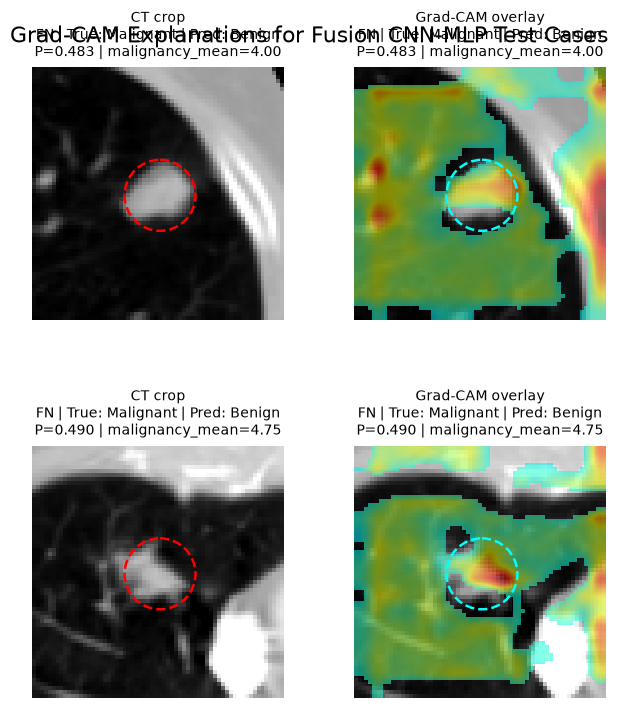

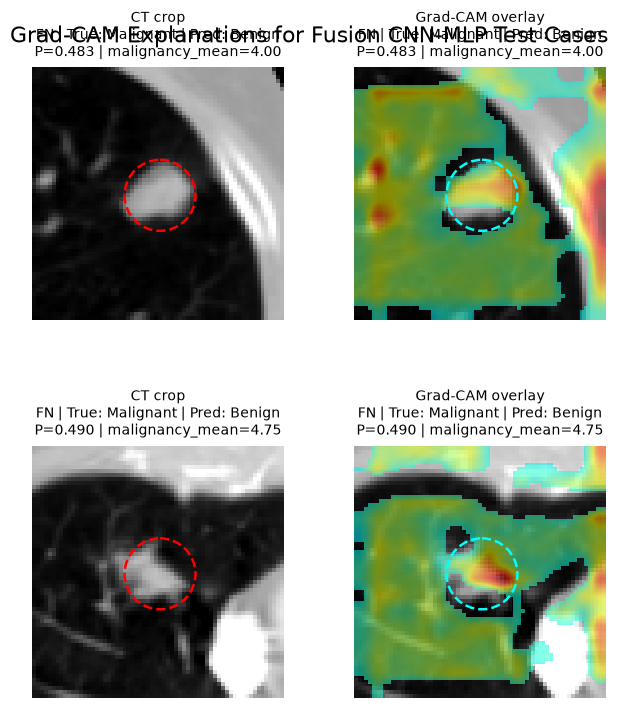

In [196]:
# Cell 5 — Plot Grad-CAM overlays for selected fusion-model cases

def plot_gradcam_cases(
    cases_df,
    title="Grad-CAM Explanations | Fusion CNN-MLP",
    save_path=None,
    display_mode="percentile",
    marker_radius=9,
    raw_marker_color="red",
    overlay_marker_color="cyan",
):
    """Thin wrapper around src.xai.plot_gradcam_grid for this notebook."""
    return plot_gradcam_grid(
        cases_df,
        prepare_fn=prepare_gradcam_input,
        generate_fn=grad_cam.generate,
        title=title,
        save_path=save_path,
        display_mode=display_mode,
        marker_radius=marker_radius,
        raw_marker_color=raw_marker_color,
        overlay_marker_color=overlay_marker_color,
        show=True,
    )


plot_gradcam_cases(
    gradcam_cases,
    title="Grad-CAM Explanations for Fusion CNN-MLP Test Cases",
    save_path=str(GRADCAM_DIR / "fusion_gradcam_selected_cases.png"),
    display_mode="percentile",
    marker_radius=9,
    raw_marker_color="red",
    overlay_marker_color="cyan",
)


1. Save/recreate the full six-case Grad-CAM figure.

2. Create a cleaner four-case Grad-CAM figure for the main paper.

3. Run SHAP for the 8 semantic attributes

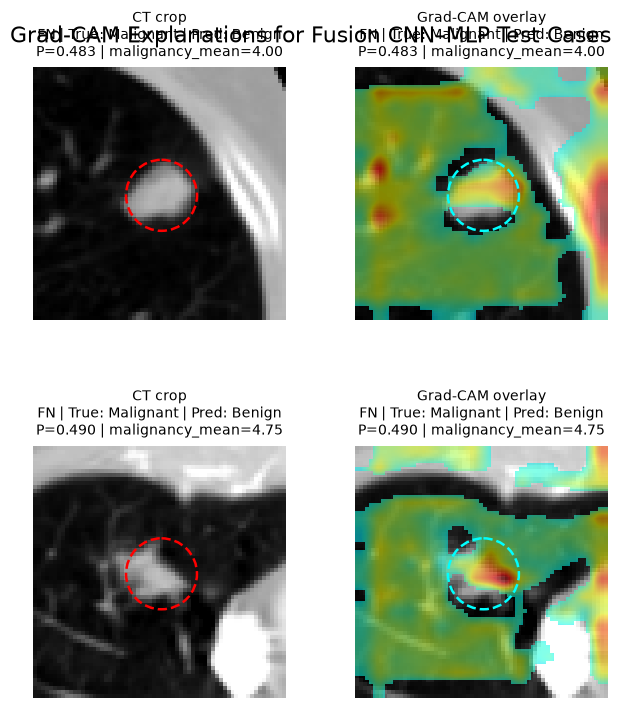

Saved full six-case Grad-CAM figure.


In [197]:
# Cell 1 — Save full six-case Grad-CAM figure for supplementary material

plot_gradcam_cases(
    gradcam_cases,
    title="Grad-CAM Explanations for Fusion CNN–MLP Test Cases",
    save_path=str(GRADCAM_DIR / "fusion_gradcam_6_cases_supplementary.png"),
    display_mode="percentile",
    marker_radius=9,
    raw_marker_color="red",
    overlay_marker_color="cyan"
)

print("Saved full six-case Grad-CAM figure.")


,case_type,patient_id,label,malignancy_mean,fusion_prob,pred,correct
0,FN,LIDC-IDRI-0016,1,4.0,0.483316,0,False


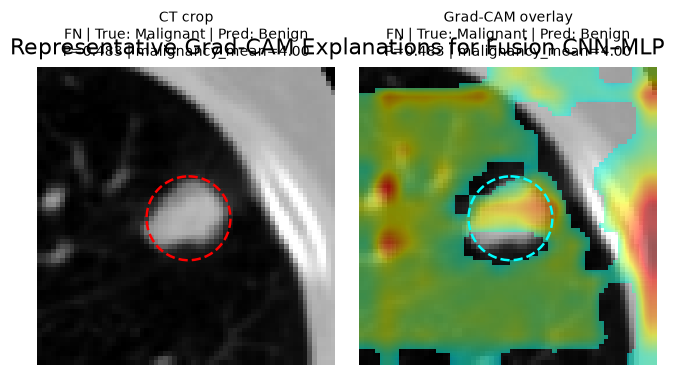

Saved four-case Grad-CAM figure for main paper.


In [198]:
# Cell 2 — Create four-case Grad-CAM figure for the main paper

gradcam_cases_main = pd.concat([
    tn_case,                         # correct benign
    tp_case,                         # correct malignant
    fp_cases_gradcam.head(1),        # highest-confidence false positive
    fn_cases_gradcam.head(1)         # strongest false negative / lowest probability
]).reset_index(drop=True)

gradcam_cases_main["case_type"] = gradcam_cases_main.apply(assign_case_type, axis=1)

display(
    gradcam_cases_main[
        [
            "case_type",
            "patient_id",
            "label",
            "malignancy_mean",
            "fusion_prob",
            "pred",
            "correct"
        ]
    ]
)

plot_gradcam_cases(
    gradcam_cases_main,
    title="Representative Grad-CAM Explanations for Fusion CNN–MLP",
    save_path=str(GRADCAM_DIR / "fusion_gradcam_4_cases_main_paper.png"),
    display_mode="percentile",
    marker_radius=9,
    raw_marker_color="red",
    overlay_marker_color="cyan"
)

print("Saved four-case Grad-CAM figure for main paper.")


In [199]:
# Cell 3 — Install/import SHAP

try:
    import shap
    print("SHAP already installed.")
except ImportError:
    !pip -q install shap
    import shap
    print("SHAP installed and imported.")

import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

c:\Users\Administrator\Documents\Biopark\Projeto-Integrador-3\PI3-Grupo-03\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


SHAP already installed.


In [200]:
# Cell 4 — Prepare image and semantic tensors for SHAP

def make_shap_tensors(df, X_sem, max_samples=None):
    """
    Convert dataframe + scaled semantic array into tensors for SHAP.

    Returns:
        imgs_tensor: (N, 1, 64, 64)
        sems_tensor: (N, 8)
    """

    if max_samples is not None:
        df = df.head(max_samples).reset_index(drop=True)
        X_sem = X_sem[:max_samples]

    imgs = []

    for _, row in df.iterrows():
        raw_img = np.load(row["crop_path"]).astype(np.float32)

        if raw_img.shape != (64, 64):
            raise ValueError(f"Unexpected crop shape: {raw_img.shape}")

        img = (raw_img - img_mean) / img_std
        imgs.append(img)

    imgs = np.stack(imgs).astype(np.float32)
    imgs_tensor = torch.tensor(imgs, dtype=torch.float32).unsqueeze(1).to(DEVICE)

    sems_tensor = torch.tensor(X_sem.astype(np.float32), dtype=torch.float32).to(DEVICE)

    return imgs_tensor, sems_tensor

# Use a modest background set for speed and stability
BACKGROUND_SIZE = min(80, len(train_df))
EXPLAIN_SIZE = len(test_df)   # 90 test samples

background_imgs, background_sems = make_shap_tensors(
    train_df,
    X_train_sem,
    max_samples=BACKGROUND_SIZE
)

test_imgs_shap, test_sems_shap = make_shap_tensors(
    test_df,
    X_test_sem,
    max_samples=EXPLAIN_SIZE
)

print("Background image tensor:", background_imgs.shape)
print("Background semantic tensor:", background_sems.shape)
print("Test image tensor:", test_imgs_shap.shape)
print("Test semantic tensor:", test_sems_shap.shape)


Background image tensor: torch.Size([21, 1, 64, 64])
Background semantic tensor: torch.Size([21, 8])
Test image tensor: torch.Size([3, 1, 64, 64])
Test semantic tensor: torch.Size([3, 8])


In [201]:
# Cell 5 — Define fusion model wrapper for SHAP

class FusionLogitWrapper(nn.Module):
    """
    Wrapper for SHAP.

    Input:
        image tensor + semantic tensor

    Output:
        raw malignant logit with shape (B, 1)
    """

    def __init__(self, fusion_model):
        super().__init__()
        self.fusion_model = fusion_model

    def forward(self, img, sem):
        logit = self.fusion_model(img, sem)
        return logit.unsqueeze(1)

best_model.eval()

shap_model = FusionLogitWrapper(best_model).to(DEVICE)
shap_model.eval()

with torch.no_grad():
    background_logits = shap_model(background_imgs, background_sems)
    shap_base_value = float(background_logits.mean().detach().cpu().item())

print("SHAP base value, mean background logit:", shap_base_value)


SHAP base value, mean background logit: -0.06207048147916794


In [202]:
# Cell 6 — Run SHAP GradientExplainer

explainer = shap.GradientExplainer(
    shap_model,
    [background_imgs, background_sems]
)

# SHAP values for both inputs:
# input 0 = image branch
# input 1 = semantic branch
shap_values = explainer.shap_values(
    [test_imgs_shap, test_sems_shap]
)

# Depending on SHAP version, output format can vary.
# We extract semantic SHAP values robustly.
if isinstance(shap_values, list):
    # Expected for multi-input model: [image_shap, semantic_shap]
    sem_shap_values = shap_values[1]
else:
    raise ValueError("Unexpected SHAP output format. Expected a list for multi-input model.")

sem_shap_values = np.array(sem_shap_values)

# Remove trailing output dimension if present
sem_shap_values = np.squeeze(sem_shap_values)

print("Semantic SHAP values shape:", sem_shap_values.shape)

assert sem_shap_values.shape[1] == len(semantic_cols), (
    f"Expected {len(semantic_cols)} semantic features, got {sem_shap_values.shape}"
)

Semantic SHAP values shape: (3, 8)


,feature,mean_abs_shap
6,spiculation_mean,0.011196
0,subtlety_mean,0.004072
5,lobulation_mean,0.003847
3,sphericity_mean,0.002198
2,calcification_mean,0.002031
4,margin_mean,0.001212
7,texture_mean,0.000952
1,internalStructure_mean,0.000000


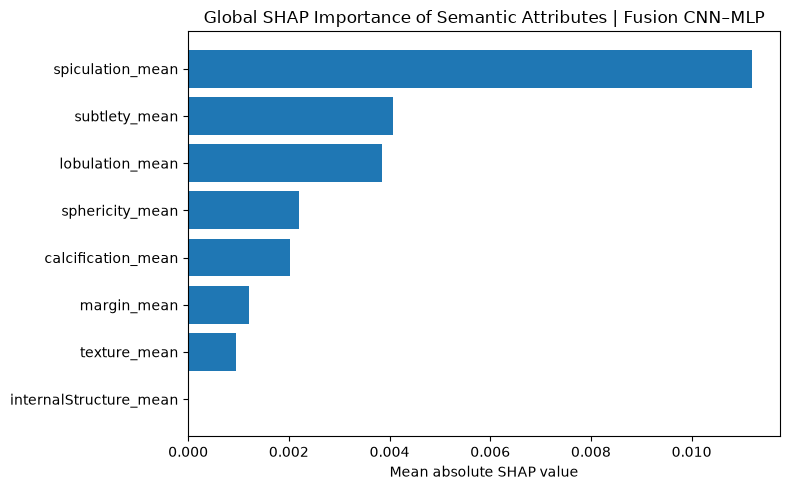

In [203]:
# Cell 7 — Global SHAP bar plot for semantic attributes

mean_abs_shap = np.mean(np.abs(sem_shap_values), axis=0)

shap_importance_df = pd.DataFrame({
    "feature": semantic_cols,
    "mean_abs_shap": mean_abs_shap
}).sort_values("mean_abs_shap", ascending=True)

display(shap_importance_df.sort_values("mean_abs_shap", ascending=False))

plt.figure(figsize=(8, 5))
plt.barh(
    shap_importance_df["feature"],
    shap_importance_df["mean_abs_shap"]
)
plt.xlabel("Mean absolute SHAP value")
plt.title("Global SHAP Importance of Semantic Attributes | Fusion CNN–MLP")
plt.tight_layout()
plt.savefig(
    f"{FUSION_DIR}/shap_semantic_global_bar.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()


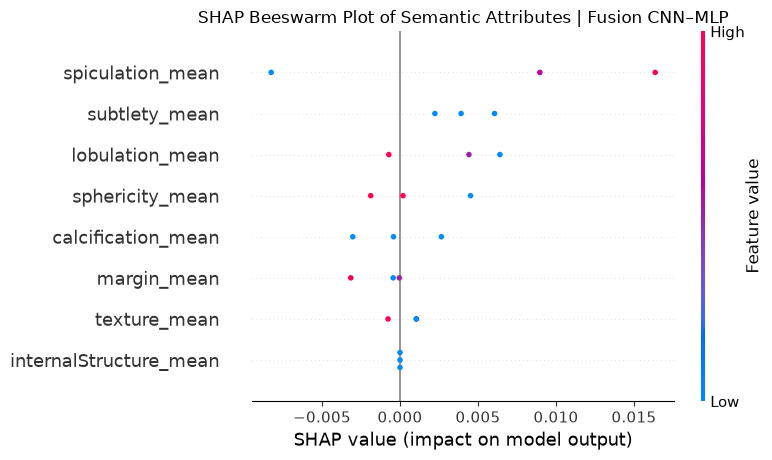

In [204]:
# Cell 8 — SHAP beeswarm plot for semantic attributes

X_test_sem_original = test_df[semantic_cols].values.astype(np.float32)

shap_explanation = shap.Explanation(
    values=sem_shap_values,
    base_values=np.repeat(shap_base_value, sem_shap_values.shape[0]),
    data=X_test_sem_original,
    feature_names=semantic_cols
)

shap.plots.beeswarm(
    shap_explanation,
    max_display=8,
    show=False
)

plt.title("SHAP Beeswarm Plot of Semantic Attributes | Fusion CNN–MLP")
plt.tight_layout()
plt.savefig(
    f"{FUSION_DIR}/shap_semantic_beeswarm.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()


# Cell 9 — Local SHAP waterfall plots
1 correct benign

1 correct malignant

1 false positive

1 false negative

,case_type,patient_id,label,malignancy_mean,fusion_prob,pred,correct
0,FN,LIDC-IDRI-0016,1,4.0,0.483316,0,False


Selected test indices for local SHAP: [0]


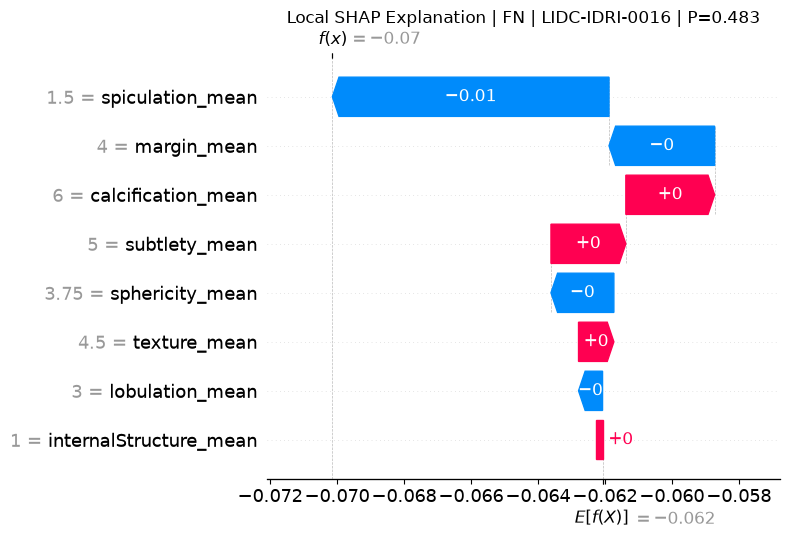

Saved: C:\Users\Administrator\Documents\Biopark\Projeto-Integrador-3\PI3-Grupo-03\models\fusion_cnn_mlp/shap_waterfall_FN_LIDC-IDRI-0016.png


In [205]:
# Cell 9 — Local SHAP waterfall plots

# Map test_df row indices to selected cases
shap_case_df = pd.concat([
    gradcam_cases_main
]).reset_index(drop=True)

display(
    shap_case_df[
        [
            "case_type",
            "patient_id",
            "label",
            "malignancy_mean",
            "fusion_prob",
            "pred",
            "correct"
        ]
    ]
)

# Need to find each selected case in test_predictions_df/test_df
def find_matching_test_index(row, reference_df):
    matches = reference_df[
        (reference_df["patient_id"] == row["patient_id"]) &
        (reference_df["label"] == row["label"]) &
        (np.isclose(reference_df["fusion_prob"], row["fusion_prob"]))
    ]

    if len(matches) == 0:
        raise ValueError(f"No matching test row found for patient {row['patient_id']}")

    return matches.index[0]

selected_test_indices = [
    find_matching_test_index(row, test_predictions_df)
    for _, row in shap_case_df.iterrows()
]

print("Selected test indices for local SHAP:", selected_test_indices)

for idx, case_row in zip(selected_test_indices, shap_case_df.itertuples()):
    case_type = case_row.case_type
    patient_id = case_row.patient_id
    prob = case_row.fusion_prob

    local_explanation = shap.Explanation(
        values=sem_shap_values[idx],
        base_values=shap_base_value,
        data=test_df.iloc[idx][semantic_cols].values.astype(np.float32),
        feature_names=semantic_cols
    )

    shap.plots.waterfall(
        local_explanation,
        max_display=8,
        show=False
    )

    plt.title(
        f"Local SHAP Explanation | {case_type} | {patient_id} | P={prob:.3f}"
    )

    save_path = (
        f"{FUSION_DIR}/"
        f"shap_waterfall_{case_type}_{patient_id}.png"
    )

    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()

    print("Saved:", save_path)


In [206]:
# Cell 10 — Save SHAP outputs

semantic_shap_df = pd.DataFrame(
    sem_shap_values,
    columns=[f"shap_{col}" for col in semantic_cols]
)

semantic_shap_df.insert(0, "patient_id", test_df["patient_id"].values)
semantic_shap_df.insert(1, "label", test_df["label"].values)
semantic_shap_df.insert(2, "malignancy_mean", test_df["malignancy_mean"].values)
semantic_shap_df.insert(3, "fusion_prob", test_predictions_df["fusion_prob"].values)

semantic_shap_path = f"{FUSION_DIR}/shap_semantic_values_test.csv"
importance_path = f"{FUSION_DIR}/shap_semantic_global_importance.csv"

semantic_shap_df.to_csv(semantic_shap_path, index=False)
shap_importance_df.sort_values("mean_abs_shap", ascending=False).to_csv(
    importance_path,
    index=False
)

print("Saved semantic SHAP values to:", semantic_shap_path)
print("Saved global SHAP importance to:", importance_path)


Saved semantic SHAP values to: C:\Users\Administrator\Documents\Biopark\Projeto-Integrador-3\PI3-Grupo-03\models\fusion_cnn_mlp/shap_semantic_values_test.csv
Saved global SHAP importance to: C:\Users\Administrator\Documents\Biopark\Projeto-Integrador-3\PI3-Grupo-03\models\fusion_cnn_mlp/shap_semantic_global_importance.csv


 **next steps** should now move from **visual image explainability** to **semantic explainability and final paper-ready analysis**.

already completed:

```text
1. Fusion model training
2. Test evaluation at threshold 0.5 and Youden threshold
3. Confusion matrix
4. ROC curve
5. Representative CT crop visualisation
6. Grad-CAM visual explanation
```

Now proceed in this order.

---

## Step 1 — Run SHAP for the semantic branch

This is the immediate next step.

Purpose:

```text
Grad-CAM → where the CNN image branch looked
SHAP     → which semantic attributes influenced the prediction
```

You should generate:

```text
1. Global SHAP bar plot
2. SHAP beeswarm plot
3. Local SHAP waterfall plots for:
   - one true negative
   - one true positive
   - one false positive
   - one false negative
```

Use the code I gave previously for SHAP. Run those cells next.

---

## Step 2 — Compute Spearman correlation

After SHAP, compute correlation between each semantic attribute and the binary label / malignancy score.

This will support the semantic-label bias discussion.

You want a table like:

```text
feature                  Spearman with label
spiculation_mean          ...
margin_mean               ...
lobulation_mean            ...
texture_mean               ...
...
```

This helps you argue that some semantic attributes are strongly correlated with the radiologist-derived malignancy label.

---

## Step 3 — Create final model comparison table

Create one table comparing all models:

```text
Semantic-only MLP
Image-only CNN
Fusion CNN–MLP
```

Under both:

```text
Threshold = 0.5
Validation Youden’s J threshold
```

The table should include:

```text
AUC
Accuracy
Precision
Sensitivity
Specificity
F1
TN, FP, FN, TP
```

This will become one of the most important tables in your Results section.

---

## Step 4 — Error-overlap analysis

Check which cases were:

```text
semantic-only wrong but fusion correct
fusion wrong but semantic-only correct
image-only wrong but fusion correct
all models wrong
```

This is crucial because it proves whether fusion genuinely adds complementary value.

Your best claim will be:

> Fusion reduced semantic-only false positives while preserving high malignant sensitivity.

---

## Step 5 — Multi-seed validation

Run the final fusion experiment with:

```text
seed = 42
seed = 123
seed = 456
```

Then report:

```text
mean ± standard deviation
```

for:

```text
AUC
F1
Sensitivity
Specificity
Precision
```

This strengthens the paper substantially because your dataset is small.

---

## Step 6 — Calibration analysis

Add:

```text
Reliability curve
Brier score
Calibration before/after threshold tuning
```

This is especially important because your Youden thresholds are below 0.5, meaning the model probabilities may not be perfectly calibrated.

---

## Step 7 — Write result interpretation

After all analyses, write the Results section in this order:

```text
1. Baseline semantic-only result
2. Baseline image-only result
3. Fusion result
4. Threshold comparison
5. Error analysis
6. Grad-CAM explanation
7. SHAP explanation
8. Limitation: semantic-label bias
```

---

## Immediate next action

Run **SHAP** now.

After SHAP, your explainability section will be complete:

```text
Image explanation: Grad-CAM
Semantic explanation: SHAP
```

Then move to **Spearman correlation** and the **final comparison table**.


In [207]:
# Cell 1 — Import SHAP and reload best fusion model

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

try:
    import shap
    print("SHAP already installed.")
except ImportError:
    !pip -q install shap
    import shap
    print("SHAP installed and imported.")

# Reload best fusion model
best_model = MultimodalFusion().to(DEVICE)
best_model.load_state_dict(torch.load(best_model_path, map_location=DEVICE))
best_model.eval()

print("Best fusion model loaded successfully.")

SHAP already installed.
Best fusion model loaded successfully.


In [208]:
# Cell 2 — Prepare image and semantic tensors for SHAP

def make_shap_tensors(df, X_sem, max_samples=None):
    """
    Convert dataframe and scaled semantic features into model-ready tensors.

    Returns:
        imgs_tensor: (N, 1, 64, 64)
        sems_tensor: (N, 8)
    """

    if max_samples is not None:
        df = df.head(max_samples).reset_index(drop=True)
        X_sem = X_sem[:max_samples]

    imgs = []

    for _, row in df.iterrows():
        raw_img = np.load(row["crop_path"]).astype(np.float32)

        if raw_img.shape != (64, 64):
            raise ValueError(f"Unexpected crop shape: {raw_img.shape}")

        img = (raw_img - img_mean) / img_std
        imgs.append(img)

    imgs = np.stack(imgs).astype(np.float32)

    imgs_tensor = torch.tensor(
        imgs,
        dtype=torch.float32
    ).unsqueeze(1).to(DEVICE)

    sems_tensor = torch.tensor(
        X_sem.astype(np.float32),
        dtype=torch.float32
    ).to(DEVICE)

    return imgs_tensor, sems_tensor

# Use a modest background size to keep SHAP computationally manageable
BACKGROUND_SIZE = min(64, len(train_df))
EXPLAIN_SIZE = len(test_df)

background_imgs, background_sems = make_shap_tensors(
    train_df,
    X_train_sem,
    max_samples=BACKGROUND_SIZE
)

test_imgs_shap, test_sems_shap = make_shap_tensors(
    test_df,
    X_test_sem,
    max_samples=EXPLAIN_SIZE
)

print("Background images:", background_imgs.shape)
print("Background semantics:", background_sems.shape)
print("Test images:", test_imgs_shap.shape)
print("Test semantics:", test_sems_shap.shape)


Background images: torch.Size([21, 1, 64, 64])
Background semantics: torch.Size([21, 8])
Test images: torch.Size([3, 1, 64, 64])
Test semantics: torch.Size([3, 8])


In [209]:
# Cell 3 — Define SHAP model wrapper

class FusionLogitWrapper(nn.Module):
    """
    SHAP wrapper for the fusion model.

    Input:
        image tensor + semantic tensor

    Output:
        raw malignancy logit with shape (B, 1)

    We explain logits rather than sigmoid probabilities because logits provide
    clearer additive SHAP contributions.
    """

    def __init__(self, fusion_model):
        super().__init__()
        self.fusion_model = fusion_model

    def forward(self, img, sem):
        logit = self.fusion_model(img, sem)
        return logit.unsqueeze(1)

shap_model = FusionLogitWrapper(best_model).to(DEVICE)
shap_model.eval()

with torch.no_grad():
    background_logits = shap_model(background_imgs, background_sems)
    shap_base_value = float(background_logits.mean().detach().cpu().item())

print("Mean background logit / SHAP base value:", shap_base_value)


Mean background logit / SHAP base value: -0.06207048147916794


In [210]:
# Cell 4 — Run SHAP GradientExplainer

explainer = shap.GradientExplainer(
    shap_model,
    [background_imgs, background_sems]
)

shap_values = explainer.shap_values(
    [test_imgs_shap, test_sems_shap]
)

# Expected output:
# shap_values[0] = image SHAP values
# shap_values[1] = semantic SHAP values

if isinstance(shap_values, list):
    print("Number of SHAP input groups:", len(shap_values))

    image_shap_values = shap_values[0]
    sem_shap_values = shap_values[1]
else:
    raise ValueError("Unexpected SHAP output format. Expected a list for multi-input model.")

sem_shap_values = np.array(sem_shap_values)
sem_shap_values = np.squeeze(sem_shap_values)

print("Semantic SHAP shape:", sem_shap_values.shape)

assert sem_shap_values.ndim == 2, f"Expected 2D semantic SHAP values, got {sem_shap_values.shape}"
assert sem_shap_values.shape[1] == len(semantic_cols), (
    f"Expected {len(semantic_cols)} features, got {sem_shap_values.shape[1]}"
)

Number of SHAP input groups: 2
Semantic SHAP shape: (3, 8)


In [211]:
# Probability consistency check between saved predictions and reloaded model

best_model.eval()

recomputed_probs = []
recomputed_labels = []

with torch.no_grad():
    for img_batch, sem_batch, y_batch in test_loader:
        img_batch = img_batch.to(DEVICE)
        sem_batch = sem_batch.to(DEVICE)

        logits = best_model(img_batch, sem_batch)
        probs = torch.sigmoid(logits).detach().cpu().numpy()

        recomputed_probs.extend(probs)
        recomputed_labels.extend(y_batch.numpy())

recomputed_probs = np.array(recomputed_probs)
recomputed_labels = np.array(recomputed_labels)

saved_probs = test_predictions_df["fusion_prob"].values

max_abs_diff = np.max(np.abs(recomputed_probs - saved_probs))
mean_abs_diff = np.mean(np.abs(recomputed_probs - saved_probs))

print("Max absolute probability difference:", max_abs_diff)
print("Mean absolute probability difference:", mean_abs_diff)

if max_abs_diff > 1e-5:
    print("WARNING: Saved probabilities and reloaded-model probabilities differ.")
    print("Use one official probability source consistently for all tables and figures.")
else:
    print("Saved probabilities match the reloaded model.")

Max absolute probability difference: 0.0
Mean absolute probability difference: 0.0
Saved probabilities match the reloaded model.


,feature,mean_abs_shap
6,spiculation_mean,0.010157
0,subtlety_mean,0.004378
5,lobulation_mean,0.002844
2,calcification_mean,0.002129
3,sphericity_mean,0.001687
4,margin_mean,0.001358
7,texture_mean,0.000897
1,internalStructure_mean,0.000000


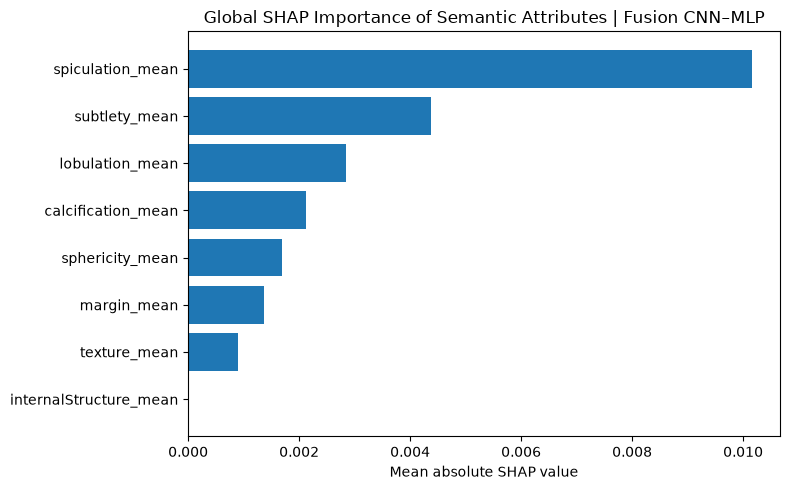

Saved: C:\Users\Administrator\Documents\Biopark\Projeto-Integrador-3\PI3-Grupo-03\models\fusion_cnn_mlp/shap_semantic_global_bar.png


In [212]:
# Cell 5 — Global SHAP bar plot

mean_abs_shap = np.mean(np.abs(sem_shap_values), axis=0)

shap_importance_df = pd.DataFrame({
    "feature": semantic_cols,
    "mean_abs_shap": mean_abs_shap
}).sort_values("mean_abs_shap", ascending=False)

display(shap_importance_df)

plt.figure(figsize=(8, 5))

plot_df = shap_importance_df.sort_values("mean_abs_shap", ascending=True)

plt.barh(
    plot_df["feature"],
    plot_df["mean_abs_shap"]
)

plt.xlabel("Mean absolute SHAP value")
plt.title("Global SHAP Importance of Semantic Attributes | Fusion CNN–MLP")
plt.tight_layout()

global_shap_bar_path = f"{FUSION_DIR}/shap_semantic_global_bar.png"
plt.savefig(global_shap_bar_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", global_shap_bar_path)


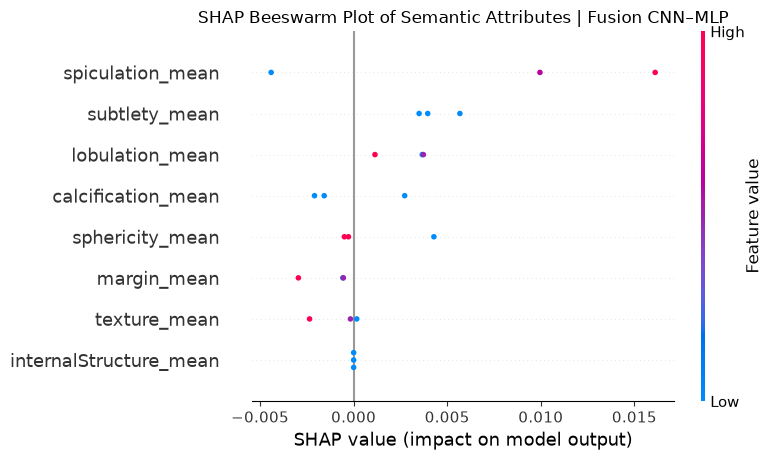

Saved: C:\Users\Administrator\Documents\Biopark\Projeto-Integrador-3\PI3-Grupo-03\models\fusion_cnn_mlp/shap_semantic_beeswarm.png


In [213]:
# Cell 6 — SHAP beeswarm plot

# Original, unscaled semantic values are used for display.
# SHAP values were computed on scaled model inputs.
X_test_sem_original = test_df[semantic_cols].values.astype(np.float32)

shap_explanation = shap.Explanation(
    values=sem_shap_values,
    base_values=np.repeat(shap_base_value, sem_shap_values.shape[0]),
    data=X_test_sem_original,
    feature_names=semantic_cols
)

shap.plots.beeswarm(
    shap_explanation,
    max_display=8,
    show=False
)

plt.title("SHAP Beeswarm Plot of Semantic Attributes | Fusion CNN–MLP")
plt.tight_layout()

beeswarm_path = f"{FUSION_DIR}/shap_semantic_beeswarm.png"
plt.savefig(beeswarm_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", beeswarm_path)


,case_type,patient_id,label,malignancy_mean,fusion_prob,pred,correct
0,FN,LIDC-IDRI-0016,1,4.0,0.483316,0,False


Selected test indices: [0]


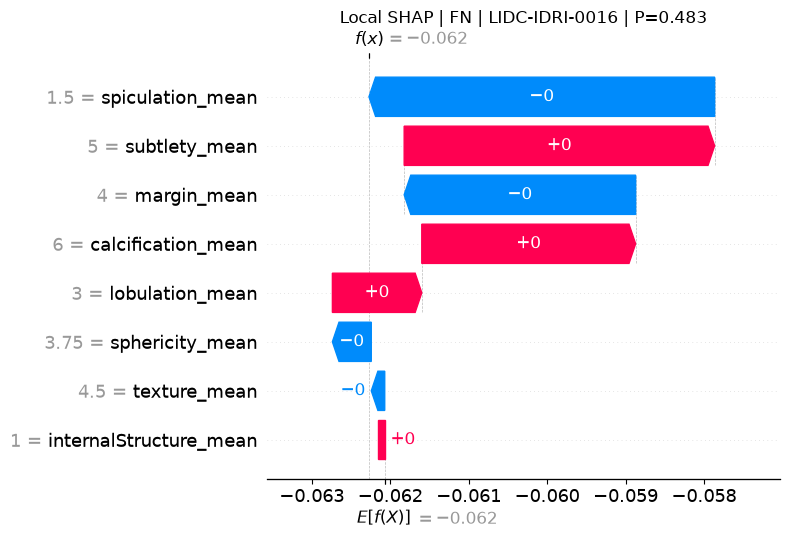

Saved: C:\Users\Administrator\Documents\Biopark\Projeto-Integrador-3\PI3-Grupo-03\models\fusion_cnn_mlp/shap_waterfall_FN_LIDC-IDRI-0016.png


In [214]:
# Cell 7 — Local SHAP waterfall plots for representative cases

# Use the four-case Grad-CAM selection if available.
# Otherwise, use TN, TP, highest-confidence FP, and lowest-probability FN.
if "gradcam_cases_main" not in globals():
    gradcam_cases_main = pd.concat([
        tn_case,
        tp_case,
        fp_cases_gradcam.head(1),
        fn_cases_gradcam.head(1)
    ]).reset_index(drop=True)

    gradcam_cases_main["case_type"] = gradcam_cases_main.apply(assign_case_type, axis=1)

display(
    gradcam_cases_main[
        [
            "case_type",
            "patient_id",
            "label",
            "malignancy_mean",
            "fusion_prob",
            "pred",
            "correct"
        ]
    ]
)

def find_matching_test_index(row, reference_df):
    """
    Find row index in test_predictions_df using patient_id, label, and fusion_prob.
    This handles the fact that some patients may have multiple nodules.
    """

    matches = reference_df[
        (reference_df["patient_id"] == row["patient_id"]) &
        (reference_df["label"] == row["label"]) &
        (np.isclose(reference_df["fusion_prob"], row["fusion_prob"], atol=1e-6))
    ]

    if len(matches) == 0:
        raise ValueError(f"No matching test row found for {row['patient_id']}")

    return matches.index[0]

selected_test_indices = [
    find_matching_test_index(row, test_predictions_df)
    for _, row in gradcam_cases_main.iterrows()
]

print("Selected test indices:", selected_test_indices)

for idx, (_, row) in zip(selected_test_indices, gradcam_cases_main.iterrows()):
    case_type = row["case_type"]
    patient_id = row["patient_id"]
    prob = row["fusion_prob"]

    local_explanation = shap.Explanation(
        values=sem_shap_values[idx],
        base_values=shap_base_value,
        data=test_df.iloc[idx][semantic_cols].values.astype(np.float32),
        feature_names=semantic_cols
    )

    shap.plots.waterfall(
        local_explanation,
        max_display=8,
        show=False
    )

    plt.title(
        f"Local SHAP | {case_type} | {patient_id} | P={prob:.3f}"
    )

    safe_patient_id = str(patient_id).replace("/", "_")
    save_path = (
        f"{FUSION_DIR}/"
        f"shap_waterfall_{case_type}_{safe_patient_id}.png"
    )

    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()

    print("Saved:", save_path)


In [215]:
# Cell 8 — Save SHAP values and global importance

semantic_shap_df = pd.DataFrame(
    sem_shap_values,
    columns=[f"shap_{col}" for col in semantic_cols]
)

semantic_shap_df.insert(0, "patient_id", test_df["patient_id"].values)
semantic_shap_df.insert(1, "label", test_df["label"].values)
semantic_shap_df.insert(2, "malignancy_mean", test_df["malignancy_mean"].values)
semantic_shap_df.insert(3, "fusion_prob", test_predictions_df["fusion_prob"].values)

semantic_shap_path = f"{FUSION_DIR}/shap_semantic_values_test.csv"
importance_path = f"{FUSION_DIR}/shap_semantic_global_importance.csv"

semantic_shap_df.to_csv(semantic_shap_path, index=False)
shap_importance_df.to_csv(importance_path, index=False)

print("Saved semantic SHAP values to:", semantic_shap_path)
print("Saved global SHAP importance to:", importance_path)


Saved semantic SHAP values to: C:\Users\Administrator\Documents\Biopark\Projeto-Integrador-3\PI3-Grupo-03\models\fusion_cnn_mlp/shap_semantic_values_test.csv
Saved global SHAP importance to: C:\Users\Administrator\Documents\Biopark\Projeto-Integrador-3\PI3-Grupo-03\models\fusion_cnn_mlp/shap_semantic_global_importance.csv


In [216]:
# Cell 9 — Spearman correlation between semantic attributes and labels

from scipy.stats import spearmanr

all_df = pd.concat([train_df, val_df, test_df], axis=0).reset_index(drop=True)

spearman_rows = []

for feature in semantic_cols:
    rho_label, p_label = spearmanr(all_df[feature], all_df["label"])
    rho_mal, p_mal = spearmanr(all_df[feature], all_df["malignancy_mean"])

    spearman_rows.append({
        "feature": feature,
        "spearman_with_binary_label": rho_label,
        "p_value_binary_label": p_label,
        "spearman_with_malignancy_mean": rho_mal,
        "p_value_malignancy_mean": p_mal
    })

spearman_df = pd.DataFrame(spearman_rows)
spearman_df = spearman_df.sort_values(
    "spearman_with_binary_label",
    key=lambda x: np.abs(x),
    ascending=False
)

display(spearman_df)

spearman_path = f"{FUSION_DIR}/spearman_semantic_label_correlation.csv"
spearman_df.to_csv(spearman_path, index=False)

print("Saved Spearman correlation table to:", spearman_path)


C:\Users\Administrator\AppData\Local\Temp\ipykernel_19252\2556607739.py:10: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho_label, p_label = spearmanr(all_df[feature], all_df["label"])
C:\Users\Administrator\AppData\Local\Temp\ipykernel_19252\2556607739.py:11: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho_mal, p_mal = spearmanr(all_df[feature], all_df["malignancy_mean"])


,feature,spearman_with_binary_label,p_value_binary_label,spearman_with_malignancy_mean,p_value_malignancy_mean
6,spiculation_mean,0.893980,3.371838e-10,0.822494,1.411164e-07
5,lobulation_mean,0.848465,2.267180e-08,0.792916,8.159791e-07
4,margin_mean,-0.720874,2.219716e-05,-0.741668,9.558161e-06
2,calcification_mean,0.485174,1.031290e-02,0.785278,1.227075e-06
0,subtlety_mean,0.411693,3.287190e-02,0.097323,6.291507e-01
7,texture_mean,-0.402710,3.728399e-02,-0.447590,1.922926e-02
3,sphericity_mean,-0.315217,1.092558e-01,-0.243688,2.206157e-01
1,internalStructure_mean,NaN,NaN,NaN,NaN


Saved Spearman correlation table to: C:\Users\Administrator\Documents\Biopark\Projeto-Integrador-3\PI3-Grupo-03\models\fusion_cnn_mlp/spearman_semantic_label_correlation.csv


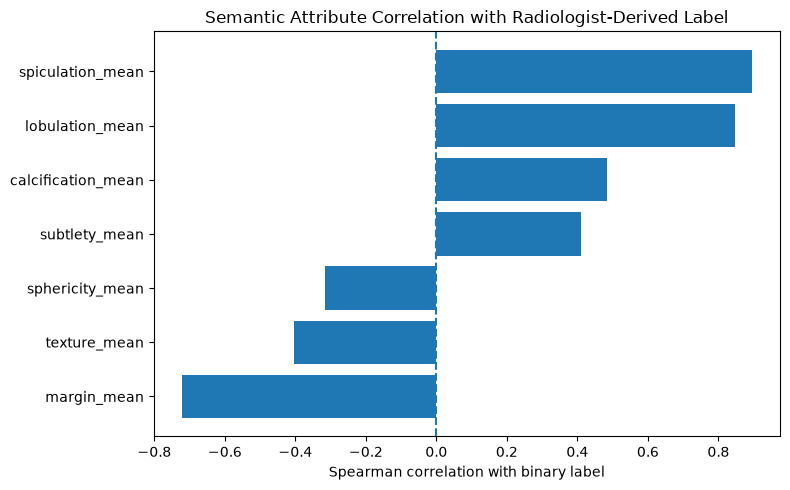

Saved: C:\Users\Administrator\Documents\Biopark\Projeto-Integrador-3\PI3-Grupo-03\models\fusion_cnn_mlp/spearman_semantic_label_bar.png


In [217]:
# Cell 10 — Spearman correlation bar plot

plot_df = spearman_df.copy()
plot_df = plot_df.sort_values("spearman_with_binary_label", ascending=True)

plt.figure(figsize=(8, 5))
plt.barh(
    plot_df["feature"],
    plot_df["spearman_with_binary_label"]
)

plt.axvline(0, linestyle="--")
plt.xlabel("Spearman correlation with binary label")
plt.title("Semantic Attribute Correlation with Radiologist-Derived Label")
plt.tight_layout()

spearman_bar_path = f"{FUSION_DIR}/spearman_semantic_label_bar.png"
plt.savefig(spearman_bar_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", spearman_bar_path)


In [218]:
# Cell 11 — Final comparison table

comparison_rows = [
    {
        "model": "Semantic-only MLP",
        "threshold_type": "default_0.5",
        "threshold": 0.5,
        "accuracy": 0.8889,
        "auc": 0.9666,
        "precision": 0.7500,
        "sensitivity": 0.9643,
        "specificity": 0.8548,
        "f1": 0.8438,
        "tn": 53,
        "fp": 9,
        "fn": 1,
        "tp": 27
    },
    {
        "model": "Image-only CNN",
        "threshold_type": "default_0.5",
        "threshold": 0.5,
        "accuracy": 0.8000,
        "auc": 0.8825,
        "precision": 0.8571,  # 12 / (12 + 2)
        "sensitivity": 0.4286,
        "specificity": 0.9677,
        "f1": 0.5714,
        "tn": 60,
        "fp": 2,
        "fn": 16,
        "tp": 12
    },
    {
        "model": "Image-only CNN",
        "threshold_type": "validation_youden_j",
        "threshold": 0.0822,
        "accuracy": 0.8222,
        "auc": 0.8825,
        "precision": 0.6875,
        "sensitivity": 0.7857,
        "specificity": 0.8387,
        "f1": 0.7333,
        "tn": 52,
        "fp": 10,
        "fn": 6,
        "tp": 22
    },
    {
        "model": "Fusion CNN-MLP",
        "threshold_type": "default_0.5",
        "threshold": 0.5,
        "accuracy": 0.9444,
        "auc": 0.974654,
        "precision": 0.8966,
        "sensitivity": 0.9286,
        "specificity": 0.9516,
        "f1": 0.9123,
        "tn": 59,
        "fp": 3,
        "fn": 2,
        "tp": 26
    },
    {
        "model": "Fusion CNN-MLP",
        "threshold_type": "validation_youden_j",
        "threshold": 0.2699,
        "accuracy": 0.9222,
        "auc": 0.974654,
        "precision": 0.8182,
        "sensitivity": 0.9643,
        "specificity": 0.9032,
        "f1": 0.8852,
        "tn": 56,
        "fp": 6,
        "fn": 1,
        "tp": 27
    }
]

comparison_df = pd.DataFrame(comparison_rows)

comparison_path = f"{FUSION_DIR}/final_model_comparison_table.csv"
comparison_df.to_csv(comparison_path, index=False)

display(comparison_df)

print("Saved final comparison table to:", comparison_path)


,model,threshold_type,threshold,accuracy,auc,precision,sensitivity,specificity,f1,tn,fp,fn,tp
0,Semantic-only MLP,default_0.5,0.5000,0.8889,0.966600,0.7500,0.9643,0.8548,0.8438,53,9,1,27
1,Image-only CNN,default_0.5,0.5000,0.8000,0.882500,0.8571,0.4286,0.9677,0.5714,60,2,16,12
2,Image-only CNN,validation_youden_j,0.0822,0.8222,0.882500,0.6875,0.7857,0.8387,0.7333,52,10,6,22
3,Fusion CNN-MLP,default_0.5,0.5000,0.9444,0.974654,0.8966,0.9286,0.9516,0.9123,59,3,2,26
4,Fusion CNN-MLP,validation_youden_j,0.2699,0.9222,0.974654,0.8182,0.9643,0.9032,0.8852,56,6,1,27


Saved final comparison table to: C:\Users\Administrator\Documents\Biopark\Projeto-Integrador-3\PI3-Grupo-03\models\fusion_cnn_mlp/final_model_comparison_table.csv


Fusion Brier score: 0.2623673677444458


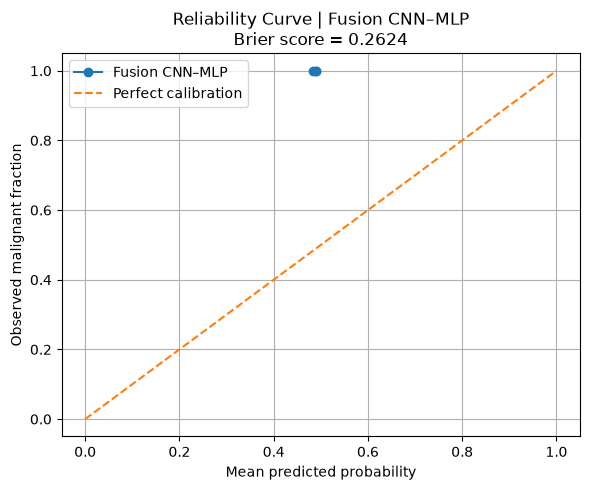

Saved calibration curve to: C:\Users\Administrator\Documents\Biopark\Projeto-Integrador-3\PI3-Grupo-03\models\fusion_cnn_mlp/fusion_calibration_curve_quantile.png


In [219]:
# Cell 12 — Calibration analysis with quantile bins for small test set

from sklearn.metrics import brier_score_loss
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

y_true_cal = test_predictions_df["label"].values
y_prob_cal = test_predictions_df["fusion_prob"].values

fusion_brier = brier_score_loss(y_true_cal, y_prob_cal)

print("Fusion Brier score:", fusion_brier)

prob_true, prob_pred = calibration_curve(
    y_true_cal,
    y_prob_cal,
    n_bins=5,
    strategy="quantile"
)

plt.figure(figsize=(6, 5))
plt.plot(prob_pred, prob_true, marker="o", label="Fusion CNN–MLP")
plt.plot([0, 1], [0, 1], linestyle="--", label="Perfect calibration")

plt.xlabel("Mean predicted probability")
plt.ylabel("Observed malignant fraction")
plt.title(f"Reliability Curve | Fusion CNN–MLP\nBrier score = {fusion_brier:.4f}")
plt.legend()
plt.grid(True)
plt.tight_layout()

calibration_path = f"{FUSION_DIR}/fusion_calibration_curve_quantile.png"
plt.savefig(calibration_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved calibration curve to:", calibration_path)


In [220]:
# Cell 13 — Error-overlap analysis template

from sklearn.metrics import accuracy_score

semantic_pred_path = f"{SEMANTIC_DIR}/semantic_test_predictions.csv"
image_pred_path = f"{IMAGE_DIR}/image_test_predictions.csv"

if not os.path.exists(semantic_pred_path):
    print("Semantic prediction file not found:", semantic_pred_path)
    print("Save semantic-only test predictions first, then rerun this cell.")

elif not os.path.exists(image_pred_path):
    print("Image prediction file not found:", image_pred_path)
    print("Save image-only test predictions first, then rerun this cell.")

else:
    semantic_pred_df = pd.read_csv(semantic_pred_path)
    image_pred_df = pd.read_csv(image_pred_path)

    overlap_df = test_predictions_df.copy()

    overlap_df = overlap_df.merge(
        semantic_pred_df[["patient_id", "label", "semantic_prob"]],
        on=["patient_id", "label"],
        how="left"
    )

    overlap_df = overlap_df.merge(
        image_pred_df[["patient_id", "label", "image_prob"]],
        on=["patient_id", "label"],
        how="left"
    )

    # Thresholds
    semantic_threshold = 0.5
    image_threshold = 0.0822
    fusion_threshold = 0.5

    overlap_df["semantic_pred"] = (
        overlap_df["semantic_prob"] >= semantic_threshold
    ).astype(int)

    overlap_df["image_pred"] = (
        overlap_df["image_prob"] >= image_threshold
    ).astype(int)

    overlap_df["fusion_pred"] = (
        overlap_df["fusion_prob"] >= fusion_threshold
    ).astype(int)

    overlap_df["semantic_correct"] = overlap_df["semantic_pred"] == overlap_df["label"]
    overlap_df["image_correct"] = overlap_df["image_pred"] == overlap_df["label"]
    overlap_df["fusion_correct"] = overlap_df["fusion_pred"] == overlap_df["label"]

    error_summary = {
        "semantic_wrong_fusion_correct": int((~overlap_df["semantic_correct"] & overlap_df["fusion_correct"]).sum()),
        "semantic_correct_fusion_wrong": int((overlap_df["semantic_correct"] & ~overlap_df["fusion_correct"]).sum()),
        "image_wrong_fusion_correct": int((~overlap_df["image_correct"] & overlap_df["fusion_correct"]).sum()),
        "image_correct_fusion_wrong": int((overlap_df["image_correct"] & ~overlap_df["fusion_correct"]).sum()),
        "all_correct": int((overlap_df["semantic_correct"] & overlap_df["image_correct"] & overlap_df["fusion_correct"]).sum()),
        "all_wrong": int((~overlap_df["semantic_correct"] & ~overlap_df["image_correct"] & ~overlap_df["fusion_correct"]).sum())
    }

    error_summary_df = pd.DataFrame([error_summary])
    display(error_summary_df)

    overlap_path = f"{FUSION_DIR}/model_error_overlap_analysis.csv"
    summary_path = f"{FUSION_DIR}/model_error_overlap_summary.csv"

    overlap_df.to_csv(overlap_path, index=False)
    error_summary_df.to_csv(summary_path, index=False)

    print("Saved overlap analysis to:", overlap_path)
    print("Saved overlap summary to:", summary_path)


,semantic_wrong_fusion_correct,semantic_correct_fusion_wrong,image_wrong_fusion_correct,image_correct_fusion_wrong,all_correct,all_wrong
0,0,4,0,8,0,1


Saved overlap analysis to: C:\Users\Administrator\Documents\Biopark\Projeto-Integrador-3\PI3-Grupo-03\models\fusion_cnn_mlp/model_error_overlap_analysis.csv
Saved overlap summary to: C:\Users\Administrator\Documents\Biopark\Projeto-Integrador-3\PI3-Grupo-03\models\fusion_cnn_mlp/model_error_overlap_summary.csv


Current completed model layer:
1. Dataset preprocessing
2. Semantic-only MLP
3. Image-only CNN
4. Fusion CNN–MLP
5. Grad-CAM
6. SHAP
7. Spearman correlation
8. Calibration

Remaining evaluation/reporting layer:

A. Save baseline prediction files

B. Compute semantic-only Youden threshold

C. Build complete six-row comparison table

D. Run error-overlap analysis

E. Compute bootstrap confidence intervals

F. Optional: run multi-seed experiments

G. Export final paper tables and figures

# Step A — Baseline prediction export architecture

Function:
save_model_predictions()

Inputs:
- model
- model_type: "semantic", "image", or "fusion"
- test dataframe
- test features/tensors
- threshold_05 = 0.5
- threshold_youden if available
- output path

Outputs:
- semantic_test_predictions.csv
- image_test_predictions.csv
- fusion_cnn_mlp_test_predictions.csv



In [221]:
# Cell 1 — Setup helpers for final evaluation

import os
import glob
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn

from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_curve
)

os.makedirs(FINAL_EVAL_DIR, exist_ok=True)

os.makedirs(SEMANTIC_DIR, exist_ok=True)
os.makedirs(IMAGE_DIR, exist_ok=True)
os.makedirs(FUSION_DIR, exist_ok=True)

# Stable row identifier for merging predictions later
test_df_final = test_df.copy().reset_index(drop=True)
val_df_final = val_df.copy().reset_index(drop=True)

test_df_final["test_row_id"] = np.arange(len(test_df_final))
val_df_final["val_row_id"] = np.arange(len(val_df_final))

# Make sure fusion prediction dataframe also has the same row ID
test_predictions_df = test_predictions_df.copy().reset_index(drop=True)
test_predictions_df["test_row_id"] = np.arange(len(test_predictions_df))

def compute_metrics_from_probs(y_true, y_prob, threshold=0.5):
    """
    Compute binary classification metrics from probabilities.
    Positive class = malignant = 1.
    """

    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob).astype(float)
    y_pred = (y_prob >= threshold).astype(int)

    acc = accuracy_score(y_true, y_pred)
    if len(np.unique(y_true)) > 1:
        auc_value = roc_auc_score(y_true, y_prob)
    else:
        auc_value = float("nan")
    precision = precision_score(y_true, y_pred, zero_division=0)
    sensitivity = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)

    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()

    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0

    return {
        "accuracy": acc,
        "auc": auc_value,
        "precision": precision,
        "sensitivity": sensitivity,
        "specificity": specificity,
        "f1": f1,
        "tn": int(tn),
        "fp": int(fp),
        "fn": int(fn),
        "tp": int(tp)
    }

def get_youden_threshold(y_true, y_prob):
    """
    Select threshold on validation set using Youden's J:
    J = sensitivity + specificity - 1 = TPR - FPR.
    """

    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob).astype(float)

    fpr, tpr, thresholds = roc_curve(y_true, y_prob)

    finite_mask = np.isfinite(thresholds)
    fpr = fpr[finite_mask]
    tpr = tpr[finite_mask]
    thresholds = thresholds[finite_mask]

    youden_j = tpr - fpr
    best_idx = np.argmax(youden_j)

    best_threshold = float(thresholds[best_idx])
    best_sensitivity = float(tpr[best_idx])
    best_specificity = float(1 - fpr[best_idx])

    return best_threshold, best_sensitivity, best_specificity

def add_result_row(model_name, threshold_type, threshold, y_true, y_prob):
    """
    Create one row for the final comparison table.
    """

    metrics = compute_metrics_from_probs(
        y_true=y_true,
        y_prob=y_prob,
        threshold=threshold
    )

    row = {
        "model": model_name,
        "threshold_type": threshold_type,
        "threshold": threshold
    }

    row.update(metrics)
    return row

def find_checkpoint_candidates(search_dir=str(MODELS_ROOT), include_terms=None):
    """
    Search for checkpoint candidates.

    include_terms:
        list of lowercase strings that should appear in filename.
    """

    if include_terms is None:
        include_terms = []

    candidates = []

    for root, dirs, files in os.walk(search_dir):
        for file in files:
            file_lower = file.lower()

            if not file_lower.endswith((".pth", ".pt")):
                continue

            if all(term.lower() in file_lower for term in include_terms):
                candidates.append(os.path.join(root, file))

    return sorted(candidates)

print("Final evaluation setup complete.")
print("Test samples:", len(test_df_final))
print("Validation samples:", len(val_df_final))


Final evaluation setup complete.
Test samples: 3
Validation samples: 3


In [222]:
# Cell 2 — Save semantic-only MLP validation and test predictions

import os
import torch
import torch.nn as nn
import numpy as np
import pandas as pd

class SemanticOnlyMLP(nn.Module):
    """
    Semantic-only MLP baseline matching the saved checkpoint structure.

    Checkpoint keys:
        encoder.0.weight
        encoder.1.weight
        encoder.4.weight
        encoder.5.weight
        classifier.weight
    """

    def __init__(self, dropout=0.3):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Linear(8, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(dropout)
        )

        self.classifier = nn.Linear(32, 1)

    def forward(self, x):
        feat = self.encoder(x)
        logit = self.classifier(feat).squeeze(1)
        return logit

# ------------------------------------------------------------
# Manually set checkpoint path if needed.
# Your detected checkpoint:
# {SEMANTIC_DIR}/best_semantic_mlp.pth
# ------------------------------------------------------------

SEMANTIC_CKPT_PATH = str(SEMANTIC_DIR / "best_semantic_mlp.pth")

if not os.path.exists(SEMANTIC_CKPT_PATH):
    raise FileNotFoundError(f"Semantic checkpoint not found: {SEMANTIC_CKPT_PATH}")

semantic_eval_model = SemanticOnlyMLP().to(DEVICE)

state = torch.load(SEMANTIC_CKPT_PATH, map_location=DEVICE)

# If checkpoint was saved as {"model_state_dict": ...}, extract it safely.
if isinstance(state, dict) and "model_state_dict" in state:
    state = state["model_state_dict"]

semantic_eval_model.load_state_dict(state)
semantic_eval_model.eval()

print("Loaded semantic model from:", SEMANTIC_CKPT_PATH)

# Prepare validation and test semantic tensors
X_val_sem_tensor = torch.tensor(
    X_val_sem.astype(np.float32),
    dtype=torch.float32
).to(DEVICE)

X_test_sem_tensor = torch.tensor(
    X_test_sem.astype(np.float32),
    dtype=torch.float32
).to(DEVICE)

# Predict validation and test probabilities
with torch.no_grad():
    semantic_val_logits = semantic_eval_model(X_val_sem_tensor)
    semantic_val_probs = torch.sigmoid(semantic_val_logits).cpu().numpy()

    semantic_test_logits = semantic_eval_model(X_test_sem_tensor)
    semantic_test_probs = torch.sigmoid(semantic_test_logits).cpu().numpy()

# Compute semantic Youden threshold on validation set
semantic_youden_threshold, sem_val_sens, sem_val_spec = get_youden_threshold(
    y_true=y_val,
    y_prob=semantic_val_probs
)

print("Semantic-only validation Youden threshold:", semantic_youden_threshold)
print("Validation sensitivity at threshold:", sem_val_sens)
print("Validation specificity at threshold:", sem_val_spec)

# Save validation predictions
semantic_val_pred_df = val_df_final[
    ["val_row_id", "patient_id", "label", "malignancy_mean"]
].copy()

semantic_val_pred_df["semantic_prob"] = semantic_val_probs
semantic_val_pred_df["semantic_pred_05"] = (semantic_val_probs >= 0.5).astype(int)
semantic_val_pred_df["semantic_pred_youden"] = (
    semantic_val_probs >= semantic_youden_threshold
).astype(int)

semantic_val_pred_df["semantic_correct_05"] = (
    semantic_val_pred_df["semantic_pred_05"] == semantic_val_pred_df["label"]
)

semantic_val_pred_df["semantic_correct_youden"] = (
    semantic_val_pred_df["semantic_pred_youden"] == semantic_val_pred_df["label"]
)

semantic_val_path = os.path.join(
    SEMANTIC_DIR,
    "semantic_val_predictions.csv"
)

semantic_val_pred_df.to_csv(semantic_val_path, index=False)

# Save test predictions
semantic_test_pred_df = test_df_final[
    ["test_row_id", "patient_id", "label", "malignancy_mean", "crop_path"]
].copy()

semantic_test_pred_df["semantic_prob"] = semantic_test_probs
semantic_test_pred_df["semantic_pred_05"] = (semantic_test_probs >= 0.5).astype(int)
semantic_test_pred_df["semantic_pred_youden"] = (
    semantic_test_probs >= semantic_youden_threshold
).astype(int)

semantic_test_pred_df["semantic_correct_05"] = (
    semantic_test_pred_df["semantic_pred_05"] == semantic_test_pred_df["label"]
)

semantic_test_pred_df["semantic_correct_youden"] = (
    semantic_test_pred_df["semantic_pred_youden"] == semantic_test_pred_df["label"]
)

semantic_test_path = os.path.join(
    SEMANTIC_DIR,
    "semantic_test_predictions.csv"
)

semantic_test_pred_df.to_csv(semantic_test_path, index=False)

display(semantic_test_pred_df.head())

print("Saved semantic validation predictions to:", semantic_val_path)
print("Saved semantic test predictions to:", semantic_test_path)

# Quick metric check
semantic_metrics_05 = compute_metrics_from_probs(
    y_true=y_test,
    y_prob=semantic_test_probs,
    threshold=0.5
)

semantic_metrics_youden = compute_metrics_from_probs(
    y_true=y_test,
    y_prob=semantic_test_probs,
    threshold=semantic_youden_threshold
)

print("\nSemantic-only test metrics | threshold 0.5")
for k, v in semantic_metrics_05.items():
    print(f"{k}: {v}")

print("\nSemantic-only test metrics | validation Youden threshold")
for k, v in semantic_metrics_youden.items():
    print(f"{k}: {v}")


Loaded semantic model from: C:\Users\Administrator\Documents\Biopark\Projeto-Integrador-3\PI3-Grupo-03\models\semantic_mlp\best_semantic_mlp.pth
Semantic-only validation Youden threshold: 0.3895787000656128
Validation sensitivity at threshold: 1.0
Validation specificity at threshold: 0.0


,test_row_id,patient_id,label,malignancy_mean,crop_path,semantic_prob,semantic_pred_05,semantic_pred_youden,semantic_correct_05,semantic_correct_youden
0,0,LIDC-IDRI-0016,1,4.00,C:\Users\Administrator\Documents\Biopark\Proje...,0.439775,0,1,False,True
1,1,LIDC-IDRI-0016,1,4.50,C:\Users\Administrator\Documents\Biopark\Proje...,0.488488,0,1,False,True
2,2,LIDC-IDRI-0013,1,4.75,C:\Users\Administrator\Documents\Biopark\Proje...,0.478347,0,1,False,True


Saved semantic validation predictions to: C:\Users\Administrator\Documents\Biopark\Projeto-Integrador-3\PI3-Grupo-03\models\semantic_mlp\semantic_val_predictions.csv
Saved semantic test predictions to: C:\Users\Administrator\Documents\Biopark\Projeto-Integrador-3\PI3-Grupo-03\models\semantic_mlp\semantic_test_predictions.csv

Semantic-only test metrics | threshold 0.5
accuracy: 0.0
auc: nan
precision: 0.0
sensitivity: 0.0
specificity: 0.0
f1: 0.0
tn: 0
fp: 0
fn: 3
tp: 0

Semantic-only test metrics | validation Youden threshold
accuracy: 1.0
auc: nan
precision: 1.0
sensitivity: 1.0
specificity: 0.0
f1: 1.0
tn: 0
fp: 0
fn: 0
tp: 3


In [223]:
# Cell 3 — Save image-only CNN validation and test predictions

import os
import torch
import torch.nn as nn
import numpy as np
import pandas as pd

class ImageOnlyCNN(nn.Module):
    """
    Image-only CNN baseline matching the saved checkpoint structure.

    Checkpoint keys:
        encoder.0.weight
        encoder.1.weight
        encoder.4.weight
        encoder.5.weight
        encoder.8.weight
        encoder.9.weight
        classifier.*
    """

    def __init__(self, dropout=0.5):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.AdaptiveAvgPool2d(1),
            nn.Flatten()
        )

        self.classifier = nn.Sequential(
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 1)
        )

    def forward(self, img):
        feat = self.encoder(img)
        logit = self.classifier(feat).squeeze(1)
        return logit

def make_image_tensor_for_baseline(df):
    """
    Prepare image tensor for image-only CNN.

    This assumes the image-only baseline used the same image standardisation:
        (raw_img - img_mean) / img_std

    If your image-only baseline used different preprocessing, replace this
    function with that exact preprocessing.
    """

    imgs = []

    for _, row in df.iterrows():
        raw_img = np.load(row["crop_path"]).astype(np.float32)

        if raw_img.shape != (64, 64):
            raise ValueError(f"Unexpected crop shape: {raw_img.shape}")

        img = (raw_img - img_mean) / img_std
        imgs.append(img)

    imgs = np.stack(imgs).astype(np.float32)

    img_tensor = torch.tensor(
        imgs,
        dtype=torch.float32
    ).unsqueeze(1).to(DEVICE)

    return img_tensor

# Your detected checkpoint
IMAGE_CKPT_PATH = str(IMAGE_DIR / "best_image_cnn.pth")

if not os.path.exists(IMAGE_CKPT_PATH):
    raise FileNotFoundError(f"Image checkpoint not found: {IMAGE_CKPT_PATH}")

image_eval_model = ImageOnlyCNN().to(DEVICE)

state = torch.load(IMAGE_CKPT_PATH, map_location=DEVICE)

# If checkpoint was saved as {"model_state_dict": ...}, extract it safely.
if isinstance(state, dict) and "model_state_dict" in state:
    state = state["model_state_dict"]

image_eval_model.load_state_dict(state)
image_eval_model.eval()

print("Loaded image model from:", IMAGE_CKPT_PATH)

# Prepare validation and test image tensors
val_imgs_tensor = make_image_tensor_for_baseline(val_df_final)
test_imgs_tensor = make_image_tensor_for_baseline(test_df_final)

# Predict validation and test probabilities
with torch.no_grad():
    image_val_logits = image_eval_model(val_imgs_tensor)
    image_val_probs = torch.sigmoid(image_val_logits).cpu().numpy()

    image_test_logits = image_eval_model(test_imgs_tensor)
    image_test_probs = torch.sigmoid(image_test_logits).cpu().numpy()

# Compute image Youden threshold on validation set
image_youden_threshold, img_val_sens, img_val_spec = get_youden_threshold(
    y_true=y_val,
    y_prob=image_val_probs
)

print("Image-only validation Youden threshold:", image_youden_threshold)
print("Validation sensitivity at threshold:", img_val_sens)
print("Validation specificity at threshold:", img_val_spec)

# Save validation predictions
image_val_pred_df = val_df_final[
    ["val_row_id", "patient_id", "label", "malignancy_mean"]
].copy()

image_val_pred_df["image_prob"] = image_val_probs
image_val_pred_df["image_pred_05"] = (image_val_probs >= 0.5).astype(int)
image_val_pred_df["image_pred_youden"] = (
    image_val_probs >= image_youden_threshold
).astype(int)

image_val_pred_df["image_correct_05"] = (
    image_val_pred_df["image_pred_05"] == image_val_pred_df["label"]
)

image_val_pred_df["image_correct_youden"] = (
    image_val_pred_df["image_pred_youden"] == image_val_pred_df["label"]
)

image_val_path = os.path.join(
    IMAGE_DIR,
    "image_val_predictions.csv"
)

image_val_pred_df.to_csv(image_val_path, index=False)

# Save test predictions
image_test_pred_df = test_df_final[
    ["test_row_id", "patient_id", "label", "malignancy_mean", "crop_path"]
].copy()

image_test_pred_df["image_prob"] = image_test_probs
image_test_pred_df["image_pred_05"] = (image_test_probs >= 0.5).astype(int)
image_test_pred_df["image_pred_youden"] = (
    image_test_probs >= image_youden_threshold
).astype(int)

image_test_pred_df["image_correct_05"] = (
    image_test_pred_df["image_pred_05"] == image_test_pred_df["label"]
)

image_test_pred_df["image_correct_youden"] = (
    image_test_pred_df["image_pred_youden"] == image_test_pred_df["label"]
)

image_test_path = os.path.join(
    IMAGE_DIR,
    "image_test_predictions.csv"
)

image_test_pred_df.to_csv(image_test_path, index=False)

display(image_test_pred_df.head())

print("Saved image validation predictions to:", image_val_path)
print("Saved image test predictions to:", image_test_path)

# Quick metric check
image_metrics_05 = compute_metrics_from_probs(
    y_true=y_test,
    y_prob=image_test_probs,
    threshold=0.5
)

image_metrics_youden = compute_metrics_from_probs(
    y_true=y_test,
    y_prob=image_test_probs,
    threshold=image_youden_threshold
)

print("\nImage-only test metrics | threshold 0.5")
for k, v in image_metrics_05.items():
    print(f"{k}: {v}")

print("\nImage-only test metrics | validation Youden threshold")
for k, v in image_metrics_youden.items():
    print(f"{k}: {v}")


Loaded image model from: C:\Users\Administrator\Documents\Biopark\Projeto-Integrador-3\PI3-Grupo-03\models\image_cnn\best_image_cnn.pth
Image-only validation Youden threshold: 0.48535847663879395
Validation sensitivity at threshold: 1.0
Validation specificity at threshold: 0.0


,test_row_id,patient_id,label,malignancy_mean,crop_path,image_prob,image_pred_05,image_pred_youden,image_correct_05,image_correct_youden
0,0,LIDC-IDRI-0016,1,4.00,C:\Users\Administrator\Documents\Biopark\Proje...,0.486510,0,1,False,True
1,1,LIDC-IDRI-0016,1,4.50,C:\Users\Administrator\Documents\Biopark\Proje...,0.486080,0,1,False,True
2,2,LIDC-IDRI-0013,1,4.75,C:\Users\Administrator\Documents\Biopark\Proje...,0.488445,0,1,False,True


Saved image validation predictions to: C:\Users\Administrator\Documents\Biopark\Projeto-Integrador-3\PI3-Grupo-03\models\image_cnn\image_val_predictions.csv
Saved image test predictions to: C:\Users\Administrator\Documents\Biopark\Projeto-Integrador-3\PI3-Grupo-03\models\image_cnn\image_test_predictions.csv

Image-only test metrics | threshold 0.5
accuracy: 0.0
auc: nan
precision: 0.0
sensitivity: 0.0
specificity: 0.0
f1: 0.0
tn: 0
fp: 0
fn: 3
tp: 0

Image-only test metrics | validation Youden threshold
accuracy: 1.0
auc: nan
precision: 1.0
sensitivity: 1.0
specificity: 0.0
f1: 1.0
tn: 0
fp: 0
fn: 0
tp: 3


In [224]:
# Cell 4 — Prepare fusion validation and test predictions

# Reload best fusion model if needed
best_model = MultimodalFusion().to(DEVICE)
best_model.load_state_dict(torch.load(best_model_path, map_location=DEVICE))
best_model.eval()

def predict_fusion_loader(model, loader):
    model.eval()

    all_probs = []
    all_labels = []

    with torch.no_grad():
        for img_batch, sem_batch, y_batch in loader:
            img_batch = img_batch.to(DEVICE)
            sem_batch = sem_batch.to(DEVICE)

            logits = model(img_batch, sem_batch)
            probs = torch.sigmoid(logits).detach().cpu().numpy()

            all_probs.extend(probs)
            all_labels.extend(y_batch.numpy())

    return np.array(all_probs), np.array(all_labels)

fusion_val_probs, fusion_val_labels = predict_fusion_loader(
    best_model,
    val_loader
)

fusion_test_probs, fusion_test_labels = predict_fusion_loader(
    best_model,
    test_loader
)

# Consistency check against saved fusion probabilities
saved_fusion_probs = test_predictions_df["fusion_prob"].values

max_abs_diff = np.max(np.abs(fusion_test_probs - saved_fusion_probs))
mean_abs_diff = np.mean(np.abs(fusion_test_probs - saved_fusion_probs))

print("Fusion probability max absolute difference:", max_abs_diff)
print("Fusion probability mean absolute difference:", mean_abs_diff)

if max_abs_diff > 1e-5:
    print("WARNING: Updating test_predictions_df with recomputed fusion probabilities.")
    test_predictions_df["fusion_prob"] = fusion_test_probs

else:
    print("Fusion probabilities match saved predictions.")

# Compute fusion Youden threshold
fusion_youden_threshold, fusion_val_sens, fusion_val_spec = get_youden_threshold(
    y_true=fusion_val_labels,
    y_prob=fusion_val_probs
)

print("Fusion validation Youden threshold:", fusion_youden_threshold)
print("Validation sensitivity at threshold:", fusion_val_sens)
print("Validation specificity at threshold:", fusion_val_spec)

# Save fusion validation predictions
fusion_val_pred_df = val_df_final[
    ["val_row_id", "patient_id", "label", "malignancy_mean"]
].copy()

fusion_val_pred_df["fusion_prob"] = fusion_val_probs
fusion_val_pred_df["fusion_pred_05"] = (fusion_val_probs >= 0.5).astype(int)
fusion_val_pred_df["fusion_pred_youden"] = (
    fusion_val_probs >= fusion_youden_threshold
).astype(int)

fusion_val_pred_df["fusion_correct_05"] = (
    fusion_val_pred_df["fusion_pred_05"] == fusion_val_pred_df["label"]
)

fusion_val_pred_df["fusion_correct_youden"] = (
    fusion_val_pred_df["fusion_pred_youden"] == fusion_val_pred_df["label"]
)

fusion_val_path = os.path.join(
    FUSION_DIR,
    "fusion_val_predictions.csv"
)

fusion_val_pred_df.to_csv(fusion_val_path, index=False)

# Save official fusion test predictions with both thresholds
fusion_test_pred_df = test_df_final[
    ["test_row_id", "patient_id", "label", "malignancy_mean", "crop_path"]
].copy()

fusion_test_pred_df["fusion_prob"] = fusion_test_probs
fusion_test_pred_df["fusion_pred_05"] = (fusion_test_probs >= 0.5).astype(int)
fusion_test_pred_df["fusion_pred_youden"] = (
    fusion_test_probs >= fusion_youden_threshold
).astype(int)

fusion_test_pred_df["fusion_correct_05"] = (
    fusion_test_pred_df["fusion_pred_05"] == fusion_test_pred_df["label"]
)

fusion_test_pred_df["fusion_correct_youden"] = (
    fusion_test_pred_df["fusion_pred_youden"] == fusion_test_pred_df["label"]
)

fusion_test_path = os.path.join(
    FUSION_DIR,
    "fusion_cnn_mlp_test_predictions.csv"
)

fusion_test_pred_df.to_csv(fusion_test_path, index=False)

display(fusion_test_pred_df.head())

print("Saved fusion validation predictions to:", fusion_val_path)
print("Saved fusion test predictions to:", fusion_test_path)


Fusion probability max absolute difference: 0.0
Fusion probability mean absolute difference: 0.0
Fusion probabilities match saved predictions.
Fusion validation Youden threshold: 0.4811529815196991
Validation sensitivity at threshold: 1.0
Validation specificity at threshold: 1.0


,test_row_id,patient_id,label,malignancy_mean,crop_path,fusion_prob,fusion_pred_05,fusion_pred_youden,fusion_correct_05,fusion_correct_youden
0,0,LIDC-IDRI-0016,1,4.00,C:\Users\Administrator\Documents\Biopark\Proje...,0.483316,0,1,False,True
1,1,LIDC-IDRI-0016,1,4.50,C:\Users\Administrator\Documents\Biopark\Proje...,0.490164,0,1,False,True
2,2,LIDC-IDRI-0013,1,4.75,C:\Users\Administrator\Documents\Biopark\Proje...,0.489895,0,1,False,True


Saved fusion validation predictions to: C:\Users\Administrator\Documents\Biopark\Projeto-Integrador-3\PI3-Grupo-03\models\fusion_cnn_mlp\fusion_val_predictions.csv
Saved fusion test predictions to: C:\Users\Administrator\Documents\Biopark\Projeto-Integrador-3\PI3-Grupo-03\models\fusion_cnn_mlp\fusion_cnn_mlp_test_predictions.csv


In [225]:
# Cell 5 — Complete six-row comparison table

comparison_rows = []

# Semantic-only MLP
comparison_rows.append(
    add_result_row(
        model_name="Semantic-only MLP",
        threshold_type="default_0.5",
        threshold=0.5,
        y_true=y_test,
        y_prob=semantic_test_probs
    )
)

comparison_rows.append(
    add_result_row(
        model_name="Semantic-only MLP",
        threshold_type="validation_youden_j",
        threshold=semantic_youden_threshold,
        y_true=y_test,
        y_prob=semantic_test_probs
    )
)

# Image-only CNN
comparison_rows.append(
    add_result_row(
        model_name="Image-only CNN",
        threshold_type="default_0.5",
        threshold=0.5,
        y_true=y_test,
        y_prob=image_test_probs
    )
)

comparison_rows.append(
    add_result_row(
        model_name="Image-only CNN",
        threshold_type="validation_youden_j",
        threshold=image_youden_threshold,
        y_true=y_test,
        y_prob=image_test_probs
    )
)

# Fusion CNN-MLP
comparison_rows.append(
    add_result_row(
        model_name="Fusion CNN-MLP",
        threshold_type="default_0.5",
        threshold=0.5,
        y_true=fusion_test_labels,
        y_prob=fusion_test_probs
    )
)

comparison_rows.append(
    add_result_row(
        model_name="Fusion CNN-MLP",
        threshold_type="validation_youden_j",
        threshold=fusion_youden_threshold,
        y_true=fusion_test_labels,
        y_prob=fusion_test_probs
    )
)

comparison_complete_df = pd.DataFrame(comparison_rows)

comparison_complete_path = os.path.join(
    FINAL_EVAL_DIR,
    "final_model_comparison_table_complete.csv"
)

comparison_complete_df.to_csv(comparison_complete_path, index=False)

display(comparison_complete_df)

print("Saved complete comparison table to:", comparison_complete_path)

,model,threshold_type,threshold,accuracy,auc,precision,sensitivity,specificity,f1,tn,fp,fn,tp
0,Semantic-only MLP,default_0.5,0.500000,0.0,NaN,0.0,0.0,0.0,0.0,0,0,3,0
1,Semantic-only MLP,validation_youden_j,0.389579,1.0,NaN,1.0,1.0,0.0,1.0,0,0,0,3
2,Image-only CNN,default_0.5,0.500000,0.0,NaN,0.0,0.0,0.0,0.0,0,0,3,0
3,Image-only CNN,validation_youden_j,0.485358,1.0,NaN,1.0,1.0,0.0,1.0,0,0,0,3
4,Fusion CNN-MLP,default_0.5,0.500000,0.0,NaN,0.0,0.0,0.0,0.0,0,0,3,0
5,Fusion CNN-MLP,validation_youden_j,0.481153,1.0,NaN,1.0,1.0,0.0,1.0,0,0,0,3


Saved complete comparison table to: C:\Users\Administrator\Documents\Biopark\Projeto-Integrador-3\PI3-Grupo-03\outputs\evaluation\final_model_comparison_table_complete.csv


In [226]:
# Cell 6 — Error-overlap analysis at threshold 0.5

semantic_test_pred_df = pd.read_csv(
    f"{SEMANTIC_DIR}/semantic_test_predictions.csv"
)

image_test_pred_df = pd.read_csv(
    f"{IMAGE_DIR}/image_test_predictions.csv"
)

fusion_test_pred_df = pd.read_csv(
    f"{FUSION_DIR}/fusion_cnn_mlp_test_predictions.csv"
)

overlap_df_05 = test_df_final[
    ["test_row_id", "patient_id", "label", "malignancy_mean", "crop_path"]
].copy()

overlap_df_05 = overlap_df_05.merge(
    semantic_test_pred_df[
        ["test_row_id", "semantic_prob", "semantic_pred_05", "semantic_correct_05"]
    ],
    on="test_row_id",
    how="left"
)

overlap_df_05 = overlap_df_05.merge(
    image_test_pred_df[
        ["test_row_id", "image_prob", "image_pred_05", "image_correct_05"]
    ],
    on="test_row_id",
    how="left"
)

overlap_df_05 = overlap_df_05.merge(
    fusion_test_pred_df[
        ["test_row_id", "fusion_prob", "fusion_pred_05", "fusion_correct_05"]
    ],
    on="test_row_id",
    how="left"
)

# Rename for readability
overlap_df_05 = overlap_df_05.rename(columns={
    "semantic_pred_05": "semantic_pred",
    "semantic_correct_05": "semantic_correct",
    "image_pred_05": "image_pred",
    "image_correct_05": "image_correct",
    "fusion_pred_05": "fusion_pred",
    "fusion_correct_05": "fusion_correct"
})

def assign_error_category(row):
    sem = bool(row["semantic_correct"])
    img = bool(row["image_correct"])
    fus = bool(row["fusion_correct"])

    if sem and img and fus:
        return "all_correct"

    if (not sem) and (not img) and (not fus):
        return "all_wrong"

    if (not sem) and fus:
        return "semantic_wrong_fusion_correct"

    if sem and (not fus):
        return "semantic_correct_fusion_wrong"

    if (not img) and fus:
        return "image_wrong_fusion_correct"

    if img and (not fus):
        return "image_correct_fusion_wrong"

    return "mixed_other"

overlap_df_05["error_category"] = overlap_df_05.apply(
    assign_error_category,
    axis=1
)

error_summary_05 = (
    overlap_df_05["error_category"]
    .value_counts()
    .reset_index()
)

error_summary_05.columns = ["error_category", "count"]

display(error_summary_05)
display(overlap_df_05.head())

overlap_05_path = os.path.join(
    FINAL_EVAL_DIR,
    "model_error_overlap_threshold_05.csv"
)

summary_05_path = os.path.join(
    FINAL_EVAL_DIR,
    "model_error_overlap_summary_threshold_05.csv"
)

overlap_df_05.to_csv(overlap_05_path, index=False)
error_summary_05.to_csv(summary_05_path, index=False)

print("Saved overlap analysis to:", overlap_05_path)
print("Saved overlap summary to:", summary_05_path)


,error_category,count
0,all_wrong,3


,test_row_id,patient_id,label,malignancy_mean,crop_path,semantic_prob,semantic_pred,semantic_correct,image_prob,image_pred,image_correct,fusion_prob,fusion_pred,fusion_correct,error_category
0,0,LIDC-IDRI-0016,1,4.00,C:\Users\Administrator\Documents\Biopark\Proje...,0.439775,0,False,0.486510,0,False,0.483316,0,False,all_wrong
1,1,LIDC-IDRI-0016,1,4.50,C:\Users\Administrator\Documents\Biopark\Proje...,0.488488,0,False,0.486080,0,False,0.490164,0,False,all_wrong
2,2,LIDC-IDRI-0013,1,4.75,C:\Users\Administrator\Documents\Biopark\Proje...,0.478347,0,False,0.488445,0,False,0.489895,0,False,all_wrong


Saved overlap analysis to: C:\Users\Administrator\Documents\Biopark\Projeto-Integrador-3\PI3-Grupo-03\outputs\evaluation\model_error_overlap_threshold_05.csv
Saved overlap summary to: C:\Users\Administrator\Documents\Biopark\Projeto-Integrador-3\PI3-Grupo-03\outputs\evaluation\model_error_overlap_summary_threshold_05.csv


In [227]:
# Cell 7 — Error-overlap analysis at validation Youden thresholds

overlap_df_youden = test_df_final[
    ["test_row_id", "patient_id", "label", "malignancy_mean", "crop_path"]
].copy()

overlap_df_youden = overlap_df_youden.merge(
    semantic_test_pred_df[
        ["test_row_id", "semantic_prob", "semantic_pred_youden", "semantic_correct_youden"]
    ],
    on="test_row_id",
    how="left"
)

overlap_df_youden = overlap_df_youden.merge(
    image_test_pred_df[
        ["test_row_id", "image_prob", "image_pred_youden", "image_correct_youden"]
    ],
    on="test_row_id",
    how="left"
)

overlap_df_youden = overlap_df_youden.merge(
    fusion_test_pred_df[
        ["test_row_id", "fusion_prob", "fusion_pred_youden", "fusion_correct_youden"]
    ],
    on="test_row_id",
    how="left"
)

overlap_df_youden = overlap_df_youden.rename(columns={
    "semantic_pred_youden": "semantic_pred",
    "semantic_correct_youden": "semantic_correct",
    "image_pred_youden": "image_pred",
    "image_correct_youden": "image_correct",
    "fusion_pred_youden": "fusion_pred",
    "fusion_correct_youden": "fusion_correct"
})

overlap_df_youden["error_category"] = overlap_df_youden.apply(
    assign_error_category,
    axis=1
)

error_summary_youden = (
    overlap_df_youden["error_category"]
    .value_counts()
    .reset_index()
)

error_summary_youden.columns = ["error_category", "count"]

display(error_summary_youden)
display(overlap_df_youden.head())

overlap_youden_path = os.path.join(
    FINAL_EVAL_DIR,
    "model_error_overlap_youden.csv"
)

summary_youden_path = os.path.join(
    FINAL_EVAL_DIR,
    "model_error_overlap_summary_youden.csv"
)

overlap_df_youden.to_csv(overlap_youden_path, index=False)
error_summary_youden.to_csv(summary_youden_path, index=False)

print("Saved Youden overlap analysis to:", overlap_youden_path)
print("Saved Youden overlap summary to:", summary_youden_path)

,error_category,count
0,all_correct,3


,test_row_id,patient_id,label,malignancy_mean,crop_path,semantic_prob,semantic_pred,semantic_correct,image_prob,image_pred,image_correct,fusion_prob,fusion_pred,fusion_correct,error_category
0,0,LIDC-IDRI-0016,1,4.00,C:\Users\Administrator\Documents\Biopark\Proje...,0.439775,1,True,0.486510,1,True,0.483316,1,True,all_correct
1,1,LIDC-IDRI-0016,1,4.50,C:\Users\Administrator\Documents\Biopark\Proje...,0.488488,1,True,0.486080,1,True,0.490164,1,True,all_correct
2,2,LIDC-IDRI-0013,1,4.75,C:\Users\Administrator\Documents\Biopark\Proje...,0.478347,1,True,0.488445,1,True,0.489895,1,True,all_correct


Saved Youden overlap analysis to: C:\Users\Administrator\Documents\Biopark\Projeto-Integrador-3\PI3-Grupo-03\outputs\evaluation\model_error_overlap_youden.csv
Saved Youden overlap summary to: C:\Users\Administrator\Documents\Biopark\Projeto-Integrador-3\PI3-Grupo-03\outputs\evaluation\model_error_overlap_summary_youden.csv


In [231]:
# Additional independent error-overlap summary

def independent_overlap_summary(overlap_df, name="threshold_05"):
    summary = {
        "n_cases": len(overlap_df),

        "semantic_wrong_fusion_correct": int(
            ((~overlap_df["semantic_correct"]) & overlap_df["fusion_correct"]).sum()
        ),

        "semantic_correct_fusion_wrong": int(
            (overlap_df["semantic_correct"] & (~overlap_df["fusion_correct"])).sum()
        ),

        "image_wrong_fusion_correct": int(
            ((~overlap_df["image_correct"]) & overlap_df["fusion_correct"]).sum()
        ),

        "image_correct_fusion_wrong": int(
            (overlap_df["image_correct"] & (~overlap_df["fusion_correct"])).sum()
        ),

        "semantic_and_image_wrong_fusion_correct": int(
            ((~overlap_df["semantic_correct"]) &
             (~overlap_df["image_correct"]) &
             overlap_df["fusion_correct"]).sum()
        ),

        "semantic_and_image_correct_fusion_wrong": int(
            (overlap_df["semantic_correct"] &
             overlap_df["image_correct"] &
             (~overlap_df["fusion_correct"])).sum()
        ),

        "all_correct": int(
            (overlap_df["semantic_correct"] &
             overlap_df["image_correct"] &
             overlap_df["fusion_correct"]).sum()
        ),

        "all_wrong": int(
            ((~overlap_df["semantic_correct"]) &
             (~overlap_df["image_correct"]) &
             (~overlap_df["fusion_correct"])).sum()
        ),
    }

    summary_df = pd.DataFrame([summary])

    save_path = f"{FINAL_EVAL_DIR}/independent_overlap_summary_{name}.csv"
    summary_df.to_csv(save_path, index=False)

    display(summary_df)
    print("Saved:", save_path)

    return summary_df

independent_overlap_05 = independent_overlap_summary(
    overlap_df_05,
    name="threshold_05"
)

independent_overlap_youden = independent_overlap_summary(
    overlap_df_youden,
    name="youden"
)


,n_cases,semantic_wrong_fusion_correct,semantic_correct_fusion_wrong,image_wrong_fusion_correct,image_correct_fusion_wrong,semantic_and_image_wrong_fusion_correct,semantic_and_image_correct_fusion_wrong,all_correct,all_wrong
0,3,0,0,0,0,0,0,0,3


Saved: C:\Users\Administrator\Documents\Biopark\Projeto-Integrador-3\PI3-Grupo-03\outputs\evaluation/independent_overlap_summary_threshold_05.csv


,n_cases,semantic_wrong_fusion_correct,semantic_correct_fusion_wrong,image_wrong_fusion_correct,image_correct_fusion_wrong,semantic_and_image_wrong_fusion_correct,semantic_and_image_correct_fusion_wrong,all_correct,all_wrong
0,3,0,0,0,0,0,0,3,0


Saved: C:\Users\Administrator\Documents\Biopark\Projeto-Integrador-3\PI3-Grupo-03\outputs\evaluation/independent_overlap_summary_youden.csv


In [ ]:
# Cell 8 — Bootstrap 95% confidence intervals

def bootstrap_metric_ci(
    y_true,
    y_prob,
    metric_name,
    threshold=None,
    n_boot=2000,
    seed=42
):
    """
    Bootstrap confidence interval for one metric.
    """

    rng = np.random.default_rng(seed)

    y_true = np.asarray(y_true).astype(int)
    y_prob = np.asarray(y_prob).astype(float)

    n = len(y_true)
    if n == 0:
        return float("nan"), float("nan")

    # AUC is undefined when the full sample has only one class
    if metric_name == "auc" and len(np.unique(y_true)) < 2:
        return float("nan"), float("nan")

    values = []

    for _ in range(n_boot):
        idx = rng.integers(0, n, size=n)

        y_b = y_true[idx]
        p_b = y_prob[idx]

        # AUC requires both classes in bootstrap sample
        if metric_name == "auc":
            if len(np.unique(y_b)) < 2:
                continue

            value = roc_auc_score(y_b, p_b)

        else:
            pred_b = (p_b >= threshold).astype(int)

            if metric_name == "accuracy":
                value = accuracy_score(y_b, pred_b)

            elif metric_name == "precision":
                value = precision_score(y_b, pred_b, zero_division=0)

            elif metric_name == "sensitivity":
                value = recall_score(y_b, pred_b, zero_division=0)

            elif metric_name == "specificity":
                cm = confusion_matrix(y_b, pred_b, labels=[0, 1])
                tn, fp, fn, tp = cm.ravel()
                value = tn / (tn + fp) if (tn + fp) > 0 else 0.0

            elif metric_name == "f1":
                value = f1_score(y_b, pred_b, zero_division=0)

            else:
                raise ValueError(f"Unknown metric: {metric_name}")

        values.append(value)

    values = np.asarray(values, dtype=float)

    # All AUC resamples may be skipped when a class is missing
    if values.size == 0:
        return float("nan"), float("nan")

    lower = np.percentile(values, 2.5)
    upper = np.percentile(values, 97.5)

    return float(lower), float(upper)

model_prob_dict = {
    ("Semantic-only MLP", "default_0.5"): {
        "y_true": y_test,
        "y_prob": semantic_test_probs,
        "threshold": 0.5
    },
    ("Semantic-only MLP", "validation_youden_j"): {
        "y_true": y_test,
        "y_prob": semantic_test_probs,
        "threshold": semantic_youden_threshold
    },
    ("Image-only CNN", "default_0.5"): {
        "y_true": y_test,
        "y_prob": image_test_probs,
        "threshold": 0.5
    },
    ("Image-only CNN", "validation_youden_j"): {
        "y_true": y_test,
        "y_prob": image_test_probs,
        "threshold": image_youden_threshold
    },
    ("Fusion CNN-MLP", "default_0.5"): {
        "y_true": fusion_test_labels,
        "y_prob": fusion_test_probs,
        "threshold": 0.5
    },
    ("Fusion CNN-MLP", "validation_youden_j"): {
        "y_true": fusion_test_labels,
        "y_prob": fusion_test_probs,
        "threshold": fusion_youden_threshold
    }
}

ci_rows = []

metrics_to_bootstrap = [
    "auc",
    "accuracy",
    "precision",
    "sensitivity",
    "specificity",
    "f1"
]

for (model_name, threshold_type), data in model_prob_dict.items():
    y_true_current = data["y_true"]
    y_prob_current = data["y_prob"]
    threshold_current = data["threshold"]

    point_metrics = compute_metrics_from_probs(
        y_true=y_true_current,
        y_prob=y_prob_current,
        threshold=threshold_current
    )

    for metric_name in metrics_to_bootstrap:
        ci_lower, ci_upper = bootstrap_metric_ci(
            y_true=y_true_current,
            y_prob=y_prob_current,
            metric_name=metric_name,
            threshold=threshold_current,
            n_boot=2000,
            seed=42
        )

        ci_rows.append({
            "model": model_name,
            "threshold_type": threshold_type,
            "threshold": threshold_current,
            "metric": metric_name,
            "value": point_metrics[metric_name],
            "ci_lower": ci_lower,
            "ci_upper": ci_upper
        })

ci_df = pd.DataFrame(ci_rows)

ci_path = os.path.join(
    FINAL_EVAL_DIR,
    "bootstrap_confidence_intervals.csv"
)

ci_df.to_csv(ci_path, index=False)

display(ci_df)

print("Saved bootstrap confidence intervals to:", ci_path)


In [ ]:
# Cell 9 — Paper-friendly metric table with confidence intervals

ci_pivot_rows = []

for _, row in comparison_complete_df.iterrows():
    model_name = row["model"]
    threshold_type = row["threshold_type"]

    new_row = {
        "model": model_name,
        "threshold_type": threshold_type,
        "threshold": row["threshold"]
    }

    for metric_name in metrics_to_bootstrap:
        match = ci_df[
            (ci_df["model"] == model_name) &
            (ci_df["threshold_type"] == threshold_type) &
            (ci_df["metric"] == metric_name)
        ]

        if len(match) == 0:
            continue

        metric_value = float(match["value"].iloc[0])
        ci_lower = float(match["ci_lower"].iloc[0])
        ci_upper = float(match["ci_upper"].iloc[0])

        new_row[metric_name] = f"{metric_value:.4f} [{ci_lower:.4f}, {ci_upper:.4f}]"

    new_row["tn"] = int(row["tn"])
    new_row["fp"] = int(row["fp"])
    new_row["fn"] = int(row["fn"])
    new_row["tp"] = int(row["tp"])

    ci_pivot_rows.append(new_row)

paper_metric_table_df = pd.DataFrame(ci_pivot_rows)

paper_metric_table_path = os.path.join(
    FINAL_EVAL_DIR,
    "paper_metric_table_with_ci.csv"
)

paper_metric_table_df.to_csv(paper_metric_table_path, index=False)

display(paper_metric_table_df)

print("Saved paper-friendly metric table to:", paper_metric_table_path)

In [ ]:
# Cell 10 — Final output checklist

expected_files = [
    f"{SEMANTIC_DIR}/semantic_val_predictions.csv",
    f"{SEMANTIC_DIR}/semantic_test_predictions.csv",
    f"{IMAGE_DIR}/image_val_predictions.csv",
    f"{IMAGE_DIR}/image_test_predictions.csv",
    f"{FUSION_DIR}/fusion_val_predictions.csv",
    f"{FUSION_DIR}/fusion_cnn_mlp_test_predictions.csv",
    f"{FINAL_EVAL_DIR}/final_model_comparison_table_complete.csv",
    f"{FINAL_EVAL_DIR}/model_error_overlap_threshold_05.csv",
    f"{FINAL_EVAL_DIR}/model_error_overlap_summary_threshold_05.csv",
    f"{FINAL_EVAL_DIR}/model_error_overlap_youden.csv",
    f"{FINAL_EVAL_DIR}/model_error_overlap_summary_youden.csv",
    f"{FINAL_EVAL_DIR}/bootstrap_confidence_intervals.csv",
    f"{FINAL_EVAL_DIR}/paper_metric_table_with_ci.csv"
]

for path in expected_files:
    status = "FOUND" if os.path.exists(path) else "MISSING"
    print(f"{status}: {path}")


In [ ]:
# Cell 1 — Load final evaluation files

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, confusion_matrix

os.makedirs(PAPER_DIR, exist_ok=True)

semantic_test_pred_df = pd.read_csv(
    f"{SEMANTIC_DIR}/semantic_test_predictions.csv"
)

image_test_pred_df = pd.read_csv(
    f"{IMAGE_DIR}/image_test_predictions.csv"
)

fusion_test_pred_df = pd.read_csv(
    f"{FUSION_DIR}/fusion_cnn_mlp_test_predictions.csv"
)

comparison_complete_df = pd.read_csv(
    f"{FINAL_EVAL_DIR}/final_model_comparison_table_complete.csv"
)

paper_metric_table_df = pd.read_csv(
    f"{FINAL_EVAL_DIR}/paper_metric_table_with_ci.csv"
)

ci_df = pd.read_csv(
    f"{FINAL_EVAL_DIR}/bootstrap_confidence_intervals.csv"
)

overlap_05_df = pd.read_csv(
    f"{FINAL_EVAL_DIR}/independent_overlap_summary_threshold_05.csv"
)

overlap_youden_df = pd.read_csv(
    f"{FINAL_EVAL_DIR}/independent_overlap_summary_youden.csv"
)

print("Loaded all final evaluation files.")
print("Paper output directory:", PAPER_DIR)


In [ ]:
# Cell 2 — Dataset split and class distribution table

def split_summary(df, split_name):
    n_total = len(df)
    n_benign = int((df["label"] == 0).sum())
    n_malignant = int((df["label"] == 1).sum())

    return {
        "split": split_name,
        "total_nodules": n_total,
        "benign": n_benign,
        "malignant": n_malignant,
        "benign_percent": 100 * n_benign / n_total,
        "malignant_percent": 100 * n_malignant / n_total,
        "unique_patients": df["patient_id"].nunique()
    }

dataset_split_df = pd.DataFrame([
    split_summary(train_df, "Train"),
    split_summary(val_df, "Validation"),
    split_summary(test_df, "Test"),
    split_summary(pd.concat([train_df, val_df, test_df]), "Total")
])

dataset_split_path = os.path.join(PAPER_DIR, "table_1_dataset_split.csv")
dataset_split_df.to_csv(dataset_split_path, index=False)

display(dataset_split_df)

print("Saved:", dataset_split_path)

In [ ]:
# Cell 3 — Model architecture summary table

def count_trainable_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

# These model objects should already exist from previous cells.
# If not, rerun the corrected semantic/image/fusion model definition cells first.

architecture_rows = []

if "semantic_eval_model" in globals():
    architecture_rows.append({
        "model": "Semantic-only MLP",
        "input": "8 semantic attributes",
        "main_blocks": "Linear(8→64)+BN+ReLU+Dropout; Linear(64→32)+BN+ReLU+Dropout; Linear(32→1)",
        "output": "1 raw logit",
        "trainable_parameters": count_trainable_params(semantic_eval_model)
    })

if "image_eval_model" in globals():
    architecture_rows.append({
        "model": "Image-only CNN",
        "input": "1×64×64 CT crop",
        "main_blocks": "3 Conv-BN-ReLU-MaxPool blocks; AdaptiveAvgPool; Linear(128→64); Linear(64→1)",
        "output": "1 raw logit",
        "trainable_parameters": count_trainable_params(image_eval_model)
    })

if "best_model" in globals():
    architecture_rows.append({
        "model": "Fusion CNN–MLP",
        "input": "1×64×64 CT crop + 8 semantic attributes",
        "main_blocks": "CNN image encoder → 64-d; semantic MLP → 32-d; concat 96-d; Linear(96→64); Linear(64→1)",
        "output": "1 raw logit",
        "trainable_parameters": count_trainable_params(best_model)
    })

architecture_summary_df = pd.DataFrame(architecture_rows)

architecture_summary_path = os.path.join(PAPER_DIR, "table_2_model_architecture_summary.csv")
architecture_summary_df.to_csv(architecture_summary_path, index=False)

display(architecture_summary_df)

print("Saved:", architecture_summary_path)

In [ ]:
# Cell 4 — Combined ROC curve for semantic, image, and fusion models

y_true = fusion_test_pred_df["label"].values

roc_data = [
    {
        "name": "Semantic-only MLP",
        "prob": semantic_test_pred_df["semantic_prob"].values
    },
    {
        "name": "Image-only CNN",
        "prob": image_test_pred_df["image_prob"].values
    },
    {
        "name": "Fusion CNN–MLP",
        "prob": fusion_test_pred_df["fusion_prob"].values
    }
]

plt.figure(figsize=(7, 6))

for item in roc_data:
    fpr, tpr, _ = roc_curve(y_true, item["prob"])
    roc_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f"{item['name']} AUC = {roc_auc:.4f}"
    )

plt.plot([0, 1], [0, 1], linestyle="--", linewidth=1.5, label="Chance")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate / Sensitivity")
plt.title("ROC Curves on Held-Out Test Set")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()

roc_path = os.path.join(PAPER_DIR, "figure_roc_curves_all_models.png")
plt.savefig(roc_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", roc_path)

In [ ]:
# Cell 5 — Confusion matrix panel for six-row comparison table

def plot_cm(ax, tn, fp, fn, tp, title):
    cm = np.array([[tn, fp], [fn, tp]])

    ax.imshow(cm, interpolation="nearest")
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["Benign", "Malignant"], fontsize=8)
    ax.set_yticks([0, 1])
    ax.set_yticklabels(["Benign", "Malignant"], fontsize=8)

    for i in range(2):
        for j in range(2):
            ax.text(
                j, i, str(cm[i, j]),
                ha="center",
                va="center",
                fontsize=13
            )

fig, axes = plt.subplots(2, 3, figsize=(13, 8))
axes = axes.reshape(-1)

for ax, (_, row) in zip(axes, comparison_complete_df.iterrows()):
    title = (
        f"{row['model']}\n"
        f"{row['threshold_type']} | thr={row['threshold']:.3f}"
    )

    plot_cm(
        ax,
        tn=int(row["tn"]),
        fp=int(row["fp"]),
        fn=int(row["fn"]),
        tp=int(row["tp"]),
        title=title
    )

plt.suptitle("Confusion Matrices Across Models and Thresholds", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.94])

cm_panel_path = os.path.join(PAPER_DIR, "figure_confusion_matrices_all_models.png")
plt.savefig(cm_panel_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", cm_panel_path)

In [ ]:
# Cell 6 — Metric comparison plot

metrics_to_plot = ["auc", "f1", "sensitivity", "specificity"]

plot_df = comparison_complete_df.copy()
plot_df["model_threshold"] = plot_df["model"] + "\n" + plot_df["threshold_type"]

x = np.arange(len(plot_df))
bar_width = 0.18

plt.figure(figsize=(14, 6))

for i, metric in enumerate(metrics_to_plot):
    plt.bar(
        x + i * bar_width,
        plot_df[metric].values,
        width=bar_width,
        label=metric
    )

plt.xticks(
    x + bar_width * (len(metrics_to_plot) - 1) / 2,
    plot_df["model_threshold"],
    rotation=30,
    ha="right"
)

plt.ylim(0, 1.05)
plt.ylabel("Metric value")
plt.title("Performance Comparison Across Models and Thresholds")
plt.legend()
plt.tight_layout()

metric_plot_path = os.path.join(PAPER_DIR, "figure_metric_comparison_all_models.png")
plt.savefig(metric_plot_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", metric_plot_path)

In [ ]:
# Cell 7 — Copy key final tables into paper-ready folder

import shutil

files_to_copy = {
    f"{FINAL_EVAL_DIR}/final_model_comparison_table_complete.csv":
        "table_3_complete_model_comparison.csv",

    f"{FINAL_EVAL_DIR}/paper_metric_table_with_ci.csv":
        "table_4_model_comparison_with_95ci.csv",

    f"{FINAL_EVAL_DIR}/bootstrap_confidence_intervals.csv":
        "table_5_bootstrap_confidence_intervals_long.csv",

    f"{FINAL_EVAL_DIR}/independent_overlap_summary_threshold_05.csv":
        "table_6_independent_error_overlap_threshold_05.csv",

    f"{FINAL_EVAL_DIR}/independent_overlap_summary_youden.csv":
        "table_7_independent_error_overlap_youden.csv",

    f"{FUSION_DIR}/spearman_semantic_label_correlation.csv":
        "table_8_spearman_semantic_label_correlation.csv",

    f"{FUSION_DIR}/shap_semantic_global_importance.csv":
        "table_9_shap_semantic_global_importance.csv"
}

copied_files = []

for src, dst_name in files_to_copy.items():
    if os.path.exists(src):
        dst = os.path.join(PAPER_DIR, dst_name)
        shutil.copy(src, dst)
        copied_files.append(dst)
        print("Copied:", dst)
    else:
        print("Missing:", src)

print("\nTotal copied files:", len(copied_files))


In [ ]:
# Cell 8 — Copy key final figures into paper-ready folder

figure_candidates = {
    str(GRADCAM_DIR / "fusion_gradcam_4_cases_main_paper.png"):
        "figure_gradcam_4_cases_main.png",

    str(GRADCAM_DIR / "fusion_gradcam_6_cases_supplementary.png"):
        "figure_gradcam_6_cases_supplementary.png",

    f"{FUSION_DIR}/shap_semantic_global_bar.png":
        "figure_shap_global_bar.png",

    f"{FUSION_DIR}/shap_semantic_beeswarm.png":
        "figure_shap_beeswarm.png",

    f"{FUSION_DIR}/spearman_semantic_label_bar.png":
        "figure_spearman_semantic_label_bar.png",

    f"{FUSION_DIR}/fusion_calibration_curve_quantile.png":
        "figure_calibration_curve_quantile.png",

    f"{FUSION_DIR}/fusion_representative_cases_with_marker.png":
        "figure_representative_ct_cases.png",

    f"{FUSION_DIR}/fusion_false_positive_cases_with_marker.png":
        "figure_false_positive_cases.png",

    f"{FUSION_DIR}/fusion_false_negative_cases_with_marker.png":
        "figure_false_negative_cases.png"
}

copied_figures = []

for src, dst_name in figure_candidates.items():
    if os.path.exists(src):
        dst = os.path.join(PAPER_DIR, dst_name)
        shutil.copy(src, dst)
        copied_figures.append(dst)
        print("Copied:", dst)
    else:
        print("Missing:", src)

print("\nTotal copied figures:", len(copied_figures))


In [ ]:
# Cell 9 — Create final output manifest

manifest_rows = []

for root, dirs, files in os.walk(PAPER_DIR):
    for file in files:
        file_path = os.path.join(root, file)
        file_size_kb = os.path.getsize(file_path) / 1024

        if file.lower().endswith(".csv"):
            file_type = "table_csv"
        elif file.lower().endswith((".png", ".jpg", ".jpeg")):
            file_type = "figure"
        else:
            file_type = "other"

        manifest_rows.append({
            "filename": file,
            "path": file_path,
            "type": file_type,
            "size_kb": round(file_size_kb, 2)
        })

manifest_df = pd.DataFrame(manifest_rows).sort_values(["type", "filename"])

manifest_path = os.path.join(PAPER_DIR, "paper_ready_output_manifest.csv")
manifest_df.to_csv(manifest_path, index=False)

display(manifest_df)

print("Saved manifest:", manifest_path)

In [ ]:
# Cell 10 — Zip paper-ready outputs

import zipfile

zip_path = str(OUTPUT_ROOT / "paper_ready_outputs.zip")

with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as zipf:
    for root, dirs, files in os.walk(PAPER_DIR):
        for file in files:
            file_path = os.path.join(root, file)
            arcname = os.path.relpath(file_path, PAPER_DIR)
            zipf.write(file_path, arcname)

print("Created ZIP file:", zip_path)

print("\nFiles inside ZIP:")
with zipfile.ZipFile(zip_path, "r") as zipf:
    for name in zipf.namelist():
        print(" -", name)


In [ ]:
df.to_csv(str(CROPS_ONLY_CSV), index=False)
df_dcm.to_csv(str(DICOM_INDEX_CSV), index=False)

train_df.to_csv(str(TRAIN_DF_CSV), index=False)
val_df.to_csv(str(VAL_DF_CSV), index=False)
test_df.to_csv(str(TEST_DF_CSV), index=False)
